In [4]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 180)

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

# -------------------------
# Path del directorio de resultados
RUN_DIR = Path(r'.../results_history_CartPole/cart_pole/20260416_2048')

## Caja 1 - Helpers

In [ ]:
def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def natural_sort_key(text):
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r'(\d+)', str(text))]


def discover_chunk_files(run_dir: Path):
    files = []
    for path in sorted(run_dir.resolve().rglob('*.json'), key=lambda p: natural_sort_key(str(p))):
        name = path.name.lower()

        if 'metadata' in name:
            continue
        if 'config' in name:
            continue
        if 'agent_state' in name:
            continue
        if 'q_table' in name:
            continue
        if 'visit_count' in name:
            continue

        files.append(path)

    return files


def get_episode_list_from_chunk(chunk_obj):
    if isinstance(chunk_obj, list):
        return chunk_obj

    if isinstance(chunk_obj, dict) and 'episodes' in chunk_obj:
        return chunk_obj['episodes']

    if isinstance(chunk_obj, dict) and 'episode_id' in chunk_obj:
        return [chunk_obj]

    return []


def extract_episode_id(ep):
    if 'episode_id' in ep:
        return int(ep['episode_id'])

    if 'episode_data' in ep and 'episode_id' in ep['episode_data']:
        return int(ep['episode_data']['episode_id'])

    return None


def load_episode_from_lookup(episode_lookup, episode_id):
    chunk_path, idx_in_chunk = episode_lookup[int(episode_id)]
    chunk_data = load_json(chunk_path)
    episodes = get_episode_list_from_chunk(chunk_data)
    episode = episodes[idx_in_chunk]
    return episode, chunk_path


def build_section_df(section_dict, n_key):
    n_rows = int(section_dict[n_key])

    data = {}
    skipped_keys = []

    for key, value in section_dict.items():
        if key == n_key:
            continue

        if isinstance(value, list) and len(value) == n_rows:
            data[key] = value
        else:
            skipped_keys.append(key)

    df = pd.DataFrame(data)
    return df, skipped_keys


def minmax_01(values):
    s = pd.to_numeric(pd.Series(values), errors='coerce')
    vmin = s.min()
    vmax = s.max()

    if pd.isna(vmin) or pd.isna(vmax) or vmax == vmin:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)

    return (s - vmin) / (vmax - vmin)


def classify_column_family(col):
    if col in {'episode_id', 'source_chunk'}:
        return 'episode_meta'

    if col.startswith('interval_') or col in {'terminated', 'termination_reason', 'end_termination_reason', 'end_terminated'}:
        return 'time_and_termination'

    if col == 'global_interval_reward' or col.startswith('reward_'):
        return 'assigned_reward'

    if col == 'principal_reward' or col.startswith('principal_') or re.match(r'^L(_|[A-Za-z])', col):
        return 'principal_reward'

    if col.startswith('extra_') or col.startswith('goal_bonus') or col.startswith('accumulated_band_bonus'):
        return 'extra_reward'

    if col.startswith('coordination_'):
        return 'coordination_reward'

    if col.startswith('action_') or col.startswith('delta_gain_'):
        return 'agent_action'

    if col.startswith('td_error_') or col.startswith('q_') or col.startswith('visits_') or col in {'epsilon', 'learning_rate'}:
        return 'learning'

    if (
        col.endswith('_raw') or
        col.endswith('_norm') or
        col == 'cart_force' or
        col.startswith('error_') or
        col.startswith('prev_error_') or
        col.startswith('delta_error_') or
        col.startswith('derivative_error_') or
        col.startswith('integral_error_') or
        col.startswith('control_action_') or
        col.startswith('prev_control_action_') or
        col.startswith('delta_control_action_') or
        col.startswith('u_eff_') or
        col.startswith('prev_u_eff_') or
        col.startswith('delta_u_eff_') or
        col.startswith('u_total') or
        col.startswith('prev_u_total') or
        col.startswith('delta_u_total') or
        col.startswith('u_contrib_') or
        col.startswith('kp_') or
        col.startswith('ki_') or
        col.startswith('kd_')
    ):
        return 'physics_and_control'

    return 'other'


def build_col_inventory_df(columns):
    rows = []
    for col in columns:
        rows.append({
            'family': classify_column_family(col),
            'column': col,
        })

    out = pd.DataFrame(rows)
    out = out.sort_values(['family', 'column']).reset_index(drop=True)
    return out

def build_col_inventory_df(col_map):
    rows = []

    for family, cols in col_map.items():
        rows.append({
            'family': family,
            'n_cols': len(cols),
            'cols': cols,
        })

    return pd.DataFrame(rows)


def build_step_column_map(step_df):
    cols = list(step_df.columns)

    col_map = {
        'dynamic_raw': [c for c in cols if c.endswith('_raw')],
        'dynamic_norm': [c for c in cols if c.endswith('_norm')],
        'controller_global': [c for c in cols if c in [
            't_sec',
            'cart_force',
            'u_total',
            'u_total_raw',
            'u_total_saturated',
            'is_saturated_global',
            'prev_u_total',
            'delta_u_total',
        ]],
        'controller_error': [c for c in cols if c.startswith((
            'error_',
            'prev_error_',
            'delta_error_',
            'derivative_error_',
            'integral_error_',
        ))],
        'controller_action': [c for c in cols if c.startswith((
            'control_action_',
            'prev_control_action_',
            'delta_control_action_',
        ))],
        'controller_effective_action': [c for c in cols if c.startswith((
            'u_eff_',
            'prev_u_eff_',
            'delta_u_eff_',
            'u_contrib_',
        ))],
        'controller_gains': [c for c in cols if c.startswith((
            'kp_',
            'ki_',
            'kd_',
        ))],
    }

    used = set()
    for cols_family in col_map.values():
        used.update(cols_family)

    col_map['other'] = [c for c in cols if c not in used]

    return col_map


def build_interval_column_map(interval_df):
    cols = list(interval_df.columns)

    col_map = {
        'interval_meta': [c for c in cols if c.startswith('interval_')],
        'termination_meta': [c for c in cols if c in ['terminated', 'termination_reason']],
        'principal_terms': [c for c in cols if c.startswith('L_')],
        'principal_feature_values': [c for c in cols if c.startswith('principal_feature_value_')],
        'principal_feature_rewards': [c for c in cols if c.startswith('principal_feature_reward_')],
        'principal_gates': [c for c in cols if c.startswith('principal_gate_')],
        'principal_contributions': [c for c in cols if c.startswith('principal_contribution_')],
        'processed_metric_aggregates': [c for c in cols if c.endswith((
            '_mean_squared',
            '_mean',
            '_rms',
            '_abs',
            '_accum',
            '_proportion',
            '_keep_last',
        ))],
        'global_reward': [c for c in cols if c in ['principal_reward', 'global_interval_reward']],
        'assigned_agent_rewards': [c for c in cols if c.startswith('reward_')],
        'extra_rewards': [c for c in cols if c.startswith('extra_')],
        'coordination_rewards': [c for c in cols if c.startswith('coordination_')],
        'agent_actions': [c for c in cols if c.startswith('action_')],
        'learning_update': [c for c in cols if c.startswith(('td_error_', 'q_value_'))],
        'learning_stats': [c for c in cols if c.startswith(('q_mean_', 'q_std_', 'q_max_', 'q_min_', 'visits_'))],
        'learning_params': [c for c in cols if c in ['epsilon', 'learning_rate']],
    }

    used = set()
    for cols_family in col_map.values():
        used.update(cols_family)

    col_map['other'] = [c for c in cols if c not in used]

    return col_map


def mean_abs_col(df, col):
    return float(pd.to_numeric(df[col], errors='coerce').abs().mean())


def max_abs_col(df, col):
    return float(pd.to_numeric(df[col], errors='coerce').abs().max())


def bool_mean_col(df, col):
    return float(pd.Series(df[col]).astype(bool).mean())


def sum_existing_frame_cols(df, cols):
    existing = [c for c in cols if c in df.columns]

    if len(existing) == 0:
        return np.nan

    values_df = df[existing].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    return float(values_df.to_numpy().sum())

def extract_control_loop_var_objs(step_df):
    loop_vars = set()

    prefixes = [
        'error_',
        'derivative_error_',
        'integral_error_',
        'control_action_',
        'u_eff_',
        'kp_',
        'ki_',
        'kd_',
    ]

    for col in step_df.columns:
        for prefix in prefixes:
            if col.startswith(prefix):
                loop_vars.add(col[len(prefix):])

    return sorted(loop_vars)

def aggregate_series(series, agg_mode):
    s = pd.to_numeric(series, errors='coerce').dropna()

    if len(s) == 0:
        return np.nan

    if agg_mode == 'mean':
        return float(s.mean())

    if agg_mode == 'mean_abs':
        return float(s.abs().mean())

    if agg_mode == 'max_abs':
        return float(s.abs().max())

    if agg_mode == 'std':
        return float(s.std())

    if agg_mode == 'last':
        return float(s.iloc[-1])

    if agg_mode == 'proportion_true':
        return float(series.astype(bool).mean())

    return float(s.mean())


def build_interval_step_agg_df(interval_df, step_df, agg_jobs):
    rows = []

    for _, interval_row in interval_df.iterrows():
        start_idx = int(interval_row['interval_start_step_idx'])
        end_idx = int(interval_row['interval_end_step_idx'])

        step_slice = step_df.iloc[start_idx:end_idx + 1]

        row = {
            'interval_id': int(interval_row['interval_id']),
        }

        for source_col, agg_mode, out_col in agg_jobs:
            if source_col in step_slice.columns:
                row[out_col] = aggregate_series(step_slice[source_col], agg_mode)
            else:
                row[out_col] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


def sum_existing_cols_rowwise(df, cols):
    existing_cols = [c for c in cols if c in df.columns]

    if len(existing_cols) == 0:
        return pd.Series(np.nan, index=df.index)

    return df[existing_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0).sum(axis=1)


def build_step_timeline_df(step_df, interval_timeline_df):
    step_timeline_df = step_df.copy().reset_index(drop=True)
    step_timeline_df.insert(0, 'step_idx', np.arange(len(step_timeline_df)))

    step_timeline_df['interval_id'] = np.nan
    step_timeline_df['interval_step_idx'] = np.nan
    step_timeline_df['is_interval_start_step'] = False
    step_timeline_df['is_interval_end_step'] = False
    step_timeline_df['interval_t_start_sec'] = np.nan
    step_timeline_df['interval_t_end_sec'] = np.nan
    step_timeline_df['interval_t_mid_sec'] = np.nan

    for _, row in interval_timeline_df.iterrows():
        interval_id = int(row['interval_id'])
        start_idx = int(row['interval_start_step_idx'])
        end_idx = int(row['interval_end_step_idx'])

        local_idx = np.arange(end_idx - start_idx + 1)

        step_timeline_df.loc[start_idx:end_idx, 'interval_id'] = interval_id
        step_timeline_df.loc[start_idx:end_idx, 'interval_step_idx'] = local_idx
        step_timeline_df.loc[start_idx, 'is_interval_start_step'] = True
        step_timeline_df.loc[end_idx, 'is_interval_end_step'] = True
        step_timeline_df.loc[start_idx:end_idx, 'interval_t_start_sec'] = row['interval_t_start_sec']
        step_timeline_df.loc[start_idx:end_idx, 'interval_t_end_sec'] = row['interval_t_end_sec']
        step_timeline_df.loc[start_idx:end_idx, 'interval_t_mid_sec'] = row['interval_t_mid_sec']

    return step_timeline_df


def select_step_window(step_timeline_df, window_mode, interval_ids=None, step_range=None, time_range=None):
    window_df = step_timeline_df.copy()

    if window_mode == 'interval_ids':
        window_df = window_df.loc[window_df['interval_id'].isin(interval_ids)].copy()

    if window_mode == 'step_range':
        step_start, step_end = step_range
        window_df = window_df.loc[
            (window_df['step_idx'] >= step_start) &
            (window_df['step_idx'] <= step_end)
        ].copy()

    if window_mode == 'time_range':
        t_start, t_end = time_range
        window_df = window_df.loc[
            (window_df['t_sec'] >= t_start) &
            (window_df['t_sec'] <= t_end)
        ].copy()

    return window_df.reset_index(drop=True)

def build_rowwise_minmax_mean(df, cols):
    existing_cols = [c for c in cols if c in df.columns]

    if len(existing_cols) == 0:
        return pd.Series(np.nan, index=df.index)

    scaled_parts = []
    for col in existing_cols:
        scaled_parts.append(minmax_01(pd.to_numeric(df[col], errors='coerce')))

    scaled_df = pd.concat(scaled_parts, axis=1)
    return scaled_df.mean(axis=1)


def build_correlation_table(df, target_col, candidate_cols):
    rows = []

    target = pd.to_numeric(df[target_col], errors='coerce')

    for col in candidate_cols:
        if col not in df.columns:
            continue

        values = pd.to_numeric(df[col], errors='coerce')
        corr = target.corr(values)

        rows.append({
            'target_col': target_col,
            'feature_col': col,
            'corr': float(corr) if pd.notna(corr) else np.nan,
            'abs_corr': float(abs(corr)) if pd.notna(corr) else np.nan,
        })

    out = pd.DataFrame(rows)

    if len(out) > 0:
        out = out.sort_values(['abs_corr', 'feature_col'], ascending=[False, True]).reset_index(drop=True)

    return out


def safe_ratio_series(num, den):
    num_s = pd.to_numeric(num, errors='coerce')
    den_s = pd.to_numeric(den, errors='coerce')

    ratio = num_s / den_s.replace(0, np.nan)
    return ratio.replace([np.inf, -np.inf], np.nan)

def discover_metadata_file(run_dir):
    metadata_files = sorted(
        [p for p in Path(run_dir).resolve().rglob('*.json') if 'metadata' in p.name.lower()],
        key=lambda p: natural_sort_key(str(p))
    )
    return metadata_files[0]


def load_run_metadata(run_dir):
    metadata_path = discover_metadata_file(run_dir)
    return load_json(metadata_path)


def aggregate_metric_processing_series(values, method):
    arr = pd.to_numeric(pd.Series(values), errors='coerce').dropna().to_numpy(dtype=float)

    if len(arr) == 0:
        return np.nan

    if method == 'mean':
        return float(np.mean(arr))

    if method == 'mean_squared':
        return float(np.mean(arr ** 2))

    if method == 'rms':
        return float(np.sqrt(np.mean(arr ** 2)))

    if method == 'abs':
        return float(np.mean(np.abs(arr)))

    if method == 'accum':
        return float(np.sum(arr))

    if method == 'proportion':
        return float(np.mean(arr > 0))

    if method == 'keep_last':
        return float(arr[-1])

    return float(np.mean(arr ** 2))


def normalize_metric_processing_value(value, value_range, output_limits, method):
    range_min, range_max = value_range
    out_min, out_max = output_limits

    if pd.isna(value):
        return np.nan

    if method == 'mean_squared':
        max_abs = max(abs(range_min), abs(range_max))
        range_span = max_abs ** 2

    elif method == 'rms':
        range_span = max(abs(range_min), abs(range_max))

    elif method == 'abs':
        range_span = max(abs(range_min), abs(range_max))

    elif method == 'proportion':
        range_span = 1.0

    else:
        range_span = range_max - range_min
        value = abs(value - range_min)

    if range_span > 0:
        normalized_01 = min(1.0, abs(value) / range_span)
    else:
        normalized_01 = 0.0

    return float(out_min + normalized_01 * (out_max - out_min))


def build_metric_processing_jobs_df(run_metadata):
    config_main = run_metadata['config_main']

    controllers_config = config_main['controller_base']['controllers']
    metric_processing_config = config_main['reward_base']['reward_calculation']['metric_processing']
    norm_config = metric_processing_config['normalization']

    output_limits = norm_config['output_limits']
    norm_params = norm_config['params']

    signal_map = {
        'e': 'error',
        'edot': 'derivative_error',
        'I': 'integral_error',
        'u': 'u_eff',
        #'delta_u': 'delta_u_eff',
    }

    rows = []

    for controller_cfg in controllers_config.values():
        var_obj = controller_cfg['params']['name_objective_var']
        var_norm = norm_params[var_obj]

        for feature_key, signal_prefix in signal_map.items():
            method = var_norm[feature_key]['method']
            value_range = var_norm[feature_key]['range']

            source_step_col = f'{signal_prefix}_{var_obj}'
            stored_agg_col = f'{source_step_col}_{method}'
            stored_L_col = f'L_{feature_key}_{var_obj}'

            rows.append({
                'var_obj': var_obj,
                'feature_key': feature_key,
                'source_step_col': source_step_col,
                'method': method,
                'stored_agg_col': stored_agg_col,
                'stored_L_col': stored_L_col,
                'range_min': value_range[0],
                'range_max': value_range[1],
                'output_min': output_limits[0],
                'output_max': output_limits[1],
                'normalization_enabled': bool(norm_config['enabled']),
            })

    return pd.DataFrame(rows)


def build_metric_processing_bridge_df(step_df, interval_df, metric_jobs_df, interval_ids, var_objs, feature_keys):
    rows = []

    selected_jobs_df = metric_jobs_df.loc[
        metric_jobs_df['interval_dummy'] if 'interval_dummy' in metric_jobs_df.columns else metric_jobs_df.index == metric_jobs_df.index
    ].copy()

    selected_jobs_df = selected_jobs_df.loc[
        selected_jobs_df['var_obj'].isin(var_objs) &
        selected_jobs_df['feature_key'].isin(feature_keys)
    ].copy()

    for interval_id in interval_ids:
        interval_row = interval_df.loc[interval_df['interval_id'] == interval_id].iloc[0]

        start_idx = int(interval_row['interval_start_step_idx'])
        end_idx = int(interval_row['interval_end_step_idx'])

        step_slice = step_df.iloc[start_idx:end_idx + 1].copy()

        for _, job in selected_jobs_df.iterrows():
            source_step_col = job['source_step_col']
            method = job['method']
            stored_agg_col = job['stored_agg_col']
            stored_L_col = job['stored_L_col']

            reconstructed_agg = aggregate_metric_processing_series(step_slice[source_step_col], method)

            if job['normalization_enabled']:
                reconstructed_L = normalize_metric_processing_value(
                    reconstructed_agg,
                    [job['range_min'], job['range_max']],
                    [job['output_min'], job['output_max']],
                    method
                )
            else:
                reconstructed_L = reconstructed_agg

            stored_agg = interval_row[stored_agg_col] if stored_agg_col in interval_row.index else np.nan
            stored_L = interval_row[stored_L_col] if stored_L_col in interval_row.index else np.nan

            rows.append({
                'interval_id': int(interval_id),
                'interval_start_step_idx': start_idx,
                'interval_end_step_idx': end_idx,
                'var_obj': job['var_obj'],
                'feature_key': job['feature_key'],
                'source_step_col': source_step_col,
                'method': method,
                'stored_agg_col': stored_agg_col,
                'stored_L_col': stored_L_col,
                'reconstructed_agg': reconstructed_agg,
                'stored_agg': stored_agg,
                'agg_gap': reconstructed_agg - stored_agg if pd.notna(stored_agg) else np.nan,
                'reconstructed_L': reconstructed_L,
                'stored_L': stored_L,
                'L_gap': reconstructed_L - stored_L if pd.notna(stored_L) else np.nan,
                'range_min': job['range_min'],
                'range_max': job['range_max'],
                'output_min': job['output_min'],
                'output_max': job['output_max'],
            })

    return pd.DataFrame(rows)

def build_principal_feature_term_map(interval_df, var_objs):
    feature_term_map = {}

    for feature_key in ['e', 'edot', 'I', 'u', 'delta_u']:
        cols = []
        for var_obj in var_objs:
            col = f'L_{feature_key}_{var_obj}'
            if col in interval_df.columns:
                cols.append(col)
        feature_term_map[feature_key] = cols

    return feature_term_map


def build_principal_contribution_map(interval_df, var_objs):
    contribution_map = {}

    for feature_name in ['L_e', 'L_edot', 'L_I', 'L_u', 'L_delta_u']:
        short_feature = feature_name.replace('L_', '')
        cols = []
        for var_obj in var_objs:
            col = f'principal_contribution_{feature_name}_{var_obj}'
            if col in interval_df.columns:
                cols.append(col)
        contribution_map[short_feature] = cols

    return contribution_map


def build_principal_gate_map(interval_df, var_objs):
    gate_map = {}

    for feature_name in ['L_e', 'L_edot', 'L_I', 'L_u', 'L_delta_u']:
        short_feature = feature_name.replace('L_', '')
        cols = []
        for var_obj in var_objs:
            col = f'principal_gate_{feature_name}_{var_obj}'
            if col in interval_df.columns:
                cols.append(col)
        gate_map[short_feature] = cols

    return gate_map


def rowwise_abs_sum(df, cols):
    existing = [c for c in cols if c in df.columns]

    if len(existing) == 0:
        return pd.Series(np.nan, index=df.index)

    return df[existing].apply(pd.to_numeric, errors='coerce').abs().fillna(0.0).sum(axis=1)


def build_dominant_label(df, feature_score_cols):
    score_df = df[feature_score_cols].apply(pd.to_numeric, errors='coerce')

    labels = []
    for _, row in score_df.iterrows():
        if row.isna().all():
            labels.append(np.nan)
        else:
            labels.append(row.idxmax())

    return pd.Series(labels, index=df.index)


def extract_top_abs_contributors(row, cols, top_n=3):
    pairs = []

    for col in cols:
        value = pd.to_numeric(pd.Series([row[col]]), errors='coerce').iloc[0]
        if pd.notna(value):
            pairs.append((col, float(value), abs(float(value))))

    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:top_n]
    return pairs

def build_extra_reward_config_resume_df(run_metadata):
    config_main = run_metadata['config_main']
    extra_cfg = config_main['reward_base']['reward_calculation']['extra_rewards']

    penalty_cfg = extra_cfg['penalty_approach']
    bonus_cfg = extra_cfg['bonus_approach']
    conditional_cfg = extra_cfg['conditional_approach']

    rows = []

    rows.append({
        'group': 'extra_rewards_enabled',
        'name': 'extra_rewards',
        'enabled': bool(extra_cfg['enabled']),
        'details': None,
    })

    rows.append({
        'group': 'penalty_approach',
        'name': 'penalty_instantaneous_reward',
        'enabled': bool(penalty_cfg['penalty_instantaneous_reward']['enabled']),
        'details': penalty_cfg['penalty_instantaneous_reward']['method'],
    })

    rows.append({
        'group': 'penalty_approach',
        'name': 'penalty_delta_var',
        'enabled': bool(penalty_cfg['penalty_delta_var']['enabled']),
        'details': penalty_cfg['penalty_delta_var']['method'],
    })

    rows.append({
        'group': 'bonus_approach',
        'name': 'goal_bonus_reward',
        'enabled': bool(bonus_cfg['goal_bonus_reward']['enabled']),
        'details': bonus_cfg['goal_bonus_reward']['method'],
    })

    rows.append({
        'group': 'bonus_approach',
        'name': 'bandwidth_bonus',
        'enabled': bool(bonus_cfg['bandwidth_bonus']['enabled']),
        'details': 'bandwidth_bonus',
    })

    rows.append({
        'group': 'conditional_approach',
        'name': 'dynamic_penalty',
        'enabled': bool(conditional_cfg['dynamic_penalty']['enabled']),
        'details': conditional_cfg['dynamic_penalty']['method'],
    })

    rows.append({
        'group': 'conditional_approach',
        'name': 'dynamic_incentive',
        'enabled': bool(conditional_cfg['dynamic_incentive']['enabled']),
        'details': conditional_cfg['dynamic_incentive']['method'],
    })

    return pd.DataFrame(rows)


def build_extra_family_map(interval_df):
    cols = list(interval_df.columns)

    family_map = {
        'extra_penalty_instantaneous': [c for c in cols if c.startswith('extra_penalty_instantaneous_')],
        'extra_penalty_delta_var': [c for c in cols if c.startswith('extra_penalty_') and not c.startswith('extra_penalty_instantaneous_')],
        'extra_bonus_goal': [c for c in cols if c.startswith('extra_bonus_goal_')],
        'extra_bonus_band': [c for c in cols if c.startswith('extra_bonus_band_')],
        'extra_dynamic_penalty': [c for c in cols if c.startswith('extra_conditional_dynamic_penalty_')],
        'extra_dynamic_incentive': [
            c for c in cols
            if c.startswith('extra_conditional_dynamic_incentive_')
            and not c.startswith('extra_conditional_dynamic_incentive_tracking_')
            and not c.startswith('extra_conditional_dynamic_incentive_direction_')
            and not c.startswith('extra_conditional_dynamic_incentive_effort_')
        ],
        'extra_dynamic_incentive_tracking': [c for c in cols if c.startswith('extra_conditional_dynamic_incentive_tracking_')],
        'extra_dynamic_incentive_direction': [c for c in cols if c.startswith('extra_conditional_dynamic_incentive_direction_')],
        'extra_dynamic_incentive_effort': [c for c in cols if c.startswith('extra_conditional_dynamic_incentive_effort_')],
        'extra_total': [c for c in cols if c.startswith('extra_total_')],
    }

    return family_map


def classify_extra_vs_principal(principal_reward, extra_total, physics_badness, controller_stress, bad_context_thr, good_context_thr):
    principal_val = pd.to_numeric(pd.Series([principal_reward]), errors='coerce').iloc[0]
    extra_val = pd.to_numeric(pd.Series([extra_total]), errors='coerce').iloc[0]
    physics_val = pd.to_numeric(pd.Series([physics_badness]), errors='coerce').iloc[0]
    control_val = pd.to_numeric(pd.Series([controller_stress]), errors='coerce').iloc[0]

    if pd.isna(extra_val):
        return np.nan

    bad_context = (
        (pd.notna(physics_val) and physics_val >= bad_context_thr) or
        (pd.notna(control_val) and control_val >= bad_context_thr)
    )

    good_context = (
        (pd.notna(physics_val) and physics_val <= good_context_thr) and
        (pd.notna(control_val) and control_val <= good_context_thr)
    )

    principal_plus_extra = np.nan
    if pd.notna(principal_val):
        principal_plus_extra = principal_val + extra_val

    principal_sign = np.sign(principal_val) if pd.notna(principal_val) else np.nan
    principal_plus_extra_sign = np.sign(principal_plus_extra) if pd.notna(principal_plus_extra) else np.nan

    sign_flip = (
        pd.notna(principal_sign) and
        pd.notna(principal_plus_extra_sign) and
        principal_sign != 0 and
        principal_plus_extra_sign != 0 and
        principal_sign != principal_plus_extra_sign
    )

    if extra_val > 0 and bad_context:
        if sign_flip:
            return 'extra_bonus_reverses_bad_context'
        return 'extra_bonus_masks_problem'

    if extra_val < 0 and good_context:
        if sign_flip:
            return 'extra_penalty_reverses_good_context'
        return 'extra_penalty_hurts_good_interval'

    if extra_val > 0:
        return 'extra_bonus_supports_interval'

    if extra_val < 0:
        return 'extra_penalty_supports_interval'

    return 'extra_neutral'

def build_coordination_config_resume_df(run_metadata):
    config_main = run_metadata['config_main']
    coord_cfg = config_main['reward_base']['reward_calculation']['coordination_reward']

    rows = [
        {'field': 'enabled', 'value': bool(coord_cfg['enabled'])},
        {'field': 'reward_mode', 'value': coord_cfg['reward_mode']},
        {'field': 'assign_mode', 'value': coord_cfg['assign_mode']},
        {'field': 'global_weight', 'value': coord_cfg['global_weight']},
        {'field': 'progress_positive_only', 'value': coord_cfg['progress_positive_only']},
        {'field': 'progress_clip_max', 'value': coord_cfg['progress_clip_max']},
        {'field': 'potential_features', 'value': coord_cfg['potential_features']},
        {'field': 'contribution_error_signal', 'value': coord_cfg['contribution_error_signal']},
        {'field': 'contribution_effort_signal', 'value': coord_cfg['contribution_effort_signal']},
        {'field': 'credit_reduction_mode', 'value': coord_cfg['credit_reduction_mode']},
        {'field': 'epsilon_credit', 'value': coord_cfg['epsilon_credit']},
        {'field': 'correction_signs', 'value': coord_cfg['correction_signs']},
    ]

    return pd.DataFrame(rows)


def build_coordination_family_map(interval_df, var_objs):
    cols = list(interval_df.columns)

    family_map = {
        'coordination_global': [
            c for c in [
                'coordination_task_potential',
                'coordination_task_progress_delta',
                'coordination_task_progress_positive',
                'coordination_reward_total',
            ]
            if c in cols
        ],
        'coordination_credit_raw': [
            f'coordination_credit_raw_{var_obj}'
            for var_obj in var_objs
            if f'coordination_credit_raw_{var_obj}' in cols
        ],
        'coordination_credit_share': [
            f'coordination_credit_share_{var_obj}'
            for var_obj in var_objs
            if f'coordination_credit_share_{var_obj}' in cols
        ],
        'coordination_bonus_per_var': [
            f'extra_conditional_coordination_bonus_{var_obj}'
            for var_obj in var_objs
            if f'extra_conditional_coordination_bonus_{var_obj}' in cols
        ],
    }

    return family_map


def extract_coordination_signal_cols(run_metadata, var_objs):
    config_main = run_metadata['config_main']
    coord_cfg = config_main['reward_base']['reward_calculation']['coordination_reward']

    error_template = coord_cfg['contribution_error_signal']
    effort_template = coord_cfg['contribution_effort_signal']

    return {
        'error_cols': [error_template.format(var_obj=var_obj) for var_obj in var_objs],
        'effort_cols': [effort_template.format(var_obj=var_obj) for var_obj in var_objs],
    }


def dominant_var_from_row(row, var_col_map):
    pairs = []

    for var_obj, col in var_col_map.items():
        if col in row.index:
            value = pd.to_numeric(pd.Series([row[col]]), errors='coerce').iloc[0]
            if pd.notna(value):
                pairs.append((var_obj, float(value)))

    if len(pairs) == 0:
        return pd.Series({'dominant_var': np.nan, 'dominant_value': np.nan})

    dominant_var, dominant_value = max(pairs, key=lambda x: x[1])
    return pd.Series({'dominant_var': dominant_var, 'dominant_value': dominant_value})


def dominant_positive_var_from_row(row, var_col_map):
    pairs = []

    for var_obj, col in var_col_map.items():
        if col in row.index:
            value = pd.to_numeric(pd.Series([row[col]]), errors='coerce').iloc[0]
            if pd.notna(value) and value > 0:
                pairs.append((var_obj, float(value)))

    if len(pairs) == 0:
        return pd.Series({'dominant_var': np.nan, 'dominant_value': np.nan})

    dominant_var, dominant_value = max(pairs, key=lambda x: x[1])
    return pd.Series({'dominant_var': dominant_var, 'dominant_value': dominant_value})


def classify_coordination_progress_zone(coord_progress_positive, physics_progress_delta):
    coord_progress_positive = pd.to_numeric(pd.Series([coord_progress_positive]), errors='coerce').iloc[0]
    physics_progress_delta = pd.to_numeric(pd.Series([physics_progress_delta]), errors='coerce').iloc[0]

    if pd.isna(coord_progress_positive) or pd.isna(physics_progress_delta):
        return np.nan

    has_coord_progress = coord_progress_positive > 0
    has_physics_progress = physics_progress_delta > 0

    if has_coord_progress and has_physics_progress:
        return 'coord_progress_matches_physics'

    if has_coord_progress and not has_physics_progress:
        return 'coord_progress_without_physical_improvement'

    if (not has_coord_progress) and has_physics_progress:
        return 'physical_improvement_without_coord_progress'

    return 'no_progress_both'


def classify_coordination_credit_zone(dominant_credit_var, dominant_improvement_var, dominant_credit_share, dominant_improvement_value):
    dominant_credit_share = pd.to_numeric(pd.Series([dominant_credit_share]), errors='coerce').iloc[0]
    dominant_improvement_value = pd.to_numeric(pd.Series([dominant_improvement_value]), errors='coerce').iloc[0]

    has_credit = pd.notna(dominant_credit_share) and dominant_credit_share > 0
    has_improvement = pd.notna(dominant_improvement_value) and dominant_improvement_value > 0

    if has_credit and has_improvement:
        if dominant_credit_var == dominant_improvement_var:
            return 'credit_matches_loop_improvement'
        return 'credit_mismatch_with_loop_improvement'

    if has_credit and not has_improvement:
        return 'credit_without_clear_loop_improvement'

    if (not has_credit) and has_improvement:
        return 'missing_credit_despite_loop_improvement'

    return 'no_credit_no_clear_improvement'

def dominant_block_from_row(row, block_col_map):
    pairs = []

    for block_name, col in block_col_map.items():
        value = pd.to_numeric(pd.Series([row[col]]), errors='coerce').iloc[0] if col in row.index else np.nan
        if pd.notna(value):
            pairs.append((block_name, float(abs(value))))

    if len(pairs) == 0:
        return pd.Series({'dominant_block': np.nan, 'dominant_block_abs_value': np.nan})

    dominant_block, dominant_value = max(pairs, key=lambda x: x[1])
    return pd.Series({'dominant_block': dominant_block, 'dominant_block_abs_value': dominant_value})


def safe_sign(value):
    value = pd.to_numeric(pd.Series([value]), errors='coerce').iloc[0]

    if pd.isna(value):
        return np.nan
    if value > 0:
        return 1
    if value < 0:
        return -1
    return 0


def classify_composition_transition(principal_reward, principal_plus_extra, global_reward):
    s0 = safe_sign(principal_reward)
    s1 = safe_sign(principal_plus_extra)
    s2 = safe_sign(global_reward)

    if pd.isna(s0) or pd.isna(s1) or pd.isna(s2):
        return np.nan

    extra_flips = (s0 != 0 and s1 != 0 and s0 != s1)
    coord_flips = (s1 != 0 and s2 != 0 and s1 != s2)

    if extra_flips and coord_flips:
        return 'extra_and_coordination_flip_sign'

    if extra_flips:
        return 'extra_flip_sign'

    if coord_flips:
        return 'coordination_flip_sign'

    if s0 == s1 == s2:
        return 'no_sign_flip'

    return 'mixed_transition'


def classify_global_integration_zone(physics_badness, global_reward_goodness, bad_thr, good_thr):
    physics_badness = pd.to_numeric(pd.Series([physics_badness]), errors='coerce').iloc[0]
    global_reward_goodness = pd.to_numeric(pd.Series([global_reward_goodness]), errors='coerce').iloc[0]

    if pd.isna(physics_badness) or pd.isna(global_reward_goodness):
        return np.nan

    physics_bad = physics_badness >= bad_thr
    reward_good = global_reward_goodness >= good_thr

    if physics_bad and reward_good:
        return 'global_reward_too_good_for_physics'

    if (not physics_bad) and (not reward_good):
        return 'global_reward_too_bad_for_physics'

    if physics_bad and (not reward_good):
        return 'global_reward_coherent_bad'

    return 'global_reward_coherent_good'

def build_agent_to_var_obj_map_from_metadata(run_metadata):
    config_main = run_metadata['config_main']

    controllers_config = config_main['controller_base']['controllers']
    agents_config = config_main['agent_base']['agent_config']['agents']

    var_objs = []
    for controller_cfg in controllers_config.values():
        var_objs.append(controller_cfg['params']['name_objective_var'])

    mapping = {}
    for agent_name, agent_cfg in agents_config.items():
        if not agent_cfg['enabled_agent']:
            continue

        for var_obj in var_objs:
            if var_obj in agent_name:
                mapping[agent_name] = var_obj
                break

    return mapping


def get_reward_approach_from_metadata(run_metadata):
    return run_metadata['config_main']['reward_base']['reward_config']['reward_approach']


def classify_assigned_reward_zone(global_reward, assigned_reward, reward_approach):
    global_reward = pd.to_numeric(pd.Series([global_reward]), errors='coerce').iloc[0]
    assigned_reward = pd.to_numeric(pd.Series([assigned_reward]), errors='coerce').iloc[0]

    if pd.isna(global_reward) or pd.isna(assigned_reward):
        return np.nan

    g_sign = safe_sign(global_reward)
    a_sign = safe_sign(assigned_reward)

    if reward_approach == 'unique_for_all_reward':
        if np.isclose(global_reward, assigned_reward):
            return 'assigned_matches_global_exact'
        return 'assigned_differs_from_expected_global'

    if a_sign == g_sign:
        if abs(assigned_reward) > abs(global_reward):
            return 'assigned_same_sign_stronger_than_global'
        return 'assigned_same_sign_weaker_than_global'

    if a_sign != g_sign and a_sign != 0 and g_sign != 0:
        return 'assigned_opposite_sign_to_global'

    if a_sign == 0:
        return 'assigned_neutral'

    return 'assigned_mixed'


def row_spread(df, cols):
    existing = [c for c in cols if c in df.columns]

    if len(existing) == 0:
        return pd.Series(np.nan, index=df.index)

    values = df[existing].apply(pd.to_numeric, errors='coerce')
    return values.max(axis=1) - values.min(axis=1)


def dominant_agent_from_row(row, agent_col_map, use_abs=True):
    pairs = []

    for agent_name, col in agent_col_map.items():
        if col in row.index:
            value = pd.to_numeric(pd.Series([row[col]]), errors='coerce').iloc[0]
            if pd.notna(value):
                score = abs(float(value)) if use_abs else float(value)
                pairs.append((agent_name, float(value), score))

    if len(pairs) == 0:
        return pd.Series({'dominant_agent': np.nan, 'dominant_value': np.nan})

    dominant_agent, dominant_value, _ = max(pairs, key=lambda x: x[2])
    return pd.Series({'dominant_agent': dominant_agent, 'dominant_value': dominant_value})

def build_candidate_interval_source_df(candidate_map):
    all_ids = sorted(set().union(*[set(v) for v in candidate_map.values() if v is not None]))

    rows = []
    for interval_id in all_ids:
        row = {'interval_id': int(interval_id)}
        n_sources = 0

        for source_name, interval_ids in candidate_map.items():
            flag = int(interval_id in set(interval_ids))
            row[f'from_{source_name}'] = flag
            n_sources += flag

        row['n_sources'] = n_sources
        rows.append(row)

    return pd.DataFrame(rows).sort_values(['n_sources', 'interval_id'], ascending=[False, True]).reset_index(drop=True)


def merge_interval_views(base_df, merge_specs):
    out = base_df.copy()

    for df, cols in merge_specs:
        cols_to_use = ['interval_id'] + [c for c in cols if c in df.columns and c != 'interval_id']
        cols_to_use = list(dict.fromkeys(cols_to_use))
        out = out.merge(df[cols_to_use], on='interval_id', how='left')

    return out


def select_step_window_around_intervals(step_timeline_df, interval_timeline_df, interval_ids, left_margin_steps=0, right_margin_steps=0):
    selected_interval_df = interval_timeline_df.loc[
        interval_timeline_df['interval_id'].isin(interval_ids),
        ['interval_id', 'interval_start_step_idx', 'interval_end_step_idx']
    ].copy()

    start_idx = int(selected_interval_df['interval_start_step_idx'].min()) - int(left_margin_steps)
    end_idx = int(selected_interval_df['interval_end_step_idx'].max()) + int(right_margin_steps)

    start_idx = max(0, start_idx)
    end_idx = min(int(step_timeline_df['step_idx'].max()), end_idx)

    window_df = step_timeline_df.loc[
        (step_timeline_df['step_idx'] >= start_idx) &
        (step_timeline_df['step_idx'] <= end_idx)
    ].copy().reset_index(drop=True)

    return window_df, start_idx, end_idx


def broadcast_interval_context_to_steps(step_window_df, interval_context_df, interval_cols):
    cols_to_use = ['interval_id'] + [c for c in interval_cols if c in interval_context_df.columns and c != 'interval_id']
    cols_to_use = list(dict.fromkeys(cols_to_use))

    out = step_window_df.merge(
        interval_context_df[cols_to_use],
        on='interval_id',
        how='left'
    )

    return out


def build_local_interval_summary(step_window_df, physical_cols, control_cols):
    rows = []

    grouped = step_window_df.groupby('interval_id', dropna=True)

    for interval_id, part_df in grouped:
        row = {
            'interval_id': int(interval_id),
            'n_steps_window': int(part_df.shape[0]),
            'step_idx_start': int(part_df['step_idx'].min()),
            'step_idx_end': int(part_df['step_idx'].max()),
            't_sec_start': float(pd.to_numeric(part_df['t_sec'], errors='coerce').min()),
            't_sec_end': float(pd.to_numeric(part_df['t_sec'], errors='coerce').max()),
        }

        for col in physical_cols:
            if col in part_df.columns:
                row[f'{col}_mean_abs'] = float(pd.to_numeric(part_df[col], errors='coerce').abs().mean())

        for col in control_cols:
            if col in part_df.columns:
                row[f'{col}_mean_abs'] = float(pd.to_numeric(part_df[col], errors='coerce').abs().mean())

        rows.append(row)

    return pd.DataFrame(rows).sort_values('interval_id').reset_index(drop=True)

def select_episode_subset(global_df, mode, start_episode=None, end_episode=None, manual_ids=None):
    out = global_df.copy()

    if mode == 'range':
        out = out.loc[
            (out['episode_id'] >= start_episode) &
            (out['episode_id'] <= end_episode)
        ].copy()

    elif mode == 'manual':
        out = out.loc[out['episode_id'].isin(manual_ids)].copy()

    return out.sort_values('episode_id').reset_index(drop=True)


def rolling_series(series, window, agg):
    s = pd.to_numeric(pd.Series(series), errors='coerce')

    if agg == 'mean':
        return s.rolling(window=window, min_periods=1).mean()

    if agg == 'std':
        return s.rolling(window=window, min_periods=1).std()

    if agg == 'sum':
        return s.rolling(window=window, min_periods=1).sum()

    return s.rolling(window=window, min_periods=1).mean()


def build_global_episode_type(row, reward_q_low, reward_q_high, duration_q_low, duration_q_high):
    total_reward = pd.to_numeric(pd.Series([row['total_reward']]), errors='coerce').iloc[0]
    duration = pd.to_numeric(pd.Series([row['episode_duration_sec']]), errors='coerce').iloc[0]
    termination = row['end_termination_reason']

    if termination == 'stabilization_success':
        return 'stabilization_success'

    if termination == 'limit_exceeded':
        return 'limit_exceeded'

    if termination == 'time_limit':
        if pd.notna(total_reward) and total_reward >= reward_q_high:
            return 'time_limit_high_reward'
        if pd.notna(total_reward) and total_reward <= reward_q_low:
            return 'time_limit_low_reward'
        return 'time_limit_mid_reward'

    if pd.notna(duration) and duration <= duration_q_low:
        return 'short_episode'

    if pd.notna(duration) and duration >= duration_q_high:
        return 'long_episode'

    return 'other'


def build_reference_episode_table(df, top_n):
    cols = [
        'episode_id',
        'total_reward',
        'reward_per_step',
        'reward_per_interval',
        'episode_duration_sec',
        'n_step',
        'n_interval',
        'end_termination_reason',
        'episode_type_global',
        'global_reference_role',
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].head(top_n).reset_index(drop=True)



## Caja 2 - Discover chunks + índice global

In [6]:
chunk_files = discover_chunk_files(RUN_DIR)

chunk_inventory_df = pd.DataFrame({
    'chunk_id': np.arange(len(chunk_files)),
    'chunk_path': [str(path) for path in chunk_files],
})

print(f'chunks encontrados: {len(chunk_files)}')
display(chunk_inventory_df.head(20))

chunks encontrados: 50


,chunk_id,chunk_path
0,0,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
1,1,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
2,2,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
3,3,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
4,4,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
5,5,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
6,6,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
7,7,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
8,8,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
9,9,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...


In [7]:
global_records = []
episode_lookup = {}

for chunk_path in chunk_files:
    chunk_data = load_json(chunk_path)
    episodes = get_episode_list_from_chunk(chunk_data)

    for idx_ep, ep in enumerate(episodes):
        ep_id = extract_episode_id(ep)

        if ep_id is None:
            continue

        episode_lookup[int(ep_id)] = (chunk_path, idx_ep)

        record = {
            'episode_id': int(ep_id),
            'source_chunk': str(chunk_path),
            'n_step': np.nan,
            'n_interval': np.nan,
            'episode_duration_sec': np.nan,
            'total_reward': np.nan,
            'end_termination_reason': None,
            'end_terminated': None,
            'total_agent_decisions': np.nan,
            'goal_bonus': np.nan,
            'accumulated_band_bonus': np.nan,
            'epsilon': np.nan,
            'learning_rate': np.nan,
        }

        if 'step_data' in ep:
            step_data = ep['step_data']
            record['n_step'] = step_data['n_step']

            if 't_sec' in step_data and len(step_data['t_sec']) > 0:
                record['episode_duration_sec'] = float(step_data['t_sec'][-1])

        if 'interval_data' in ep:
            interval_data = ep['interval_data']
            record['n_interval'] = interval_data['n_interval']

        if 'end_episode_data' in ep:
            end_data = ep['end_episode_data']
            for key, value in end_data.items():
                record[key] = value

        global_records.append(record)

global_df = pd.DataFrame(global_records).sort_values('episode_id').reset_index(drop=True)

global_df['reward_per_step'] = pd.to_numeric(global_df['total_reward'], errors='coerce') / pd.to_numeric(global_df['n_step'], errors='coerce')
global_df['reward_per_interval'] = pd.to_numeric(global_df['total_reward'], errors='coerce') / pd.to_numeric(global_df['n_interval'], errors='coerce')

global_df['is_success'] = (global_df['end_termination_reason'] == 'stabilization_success').astype(int)
global_df['is_limit_exceeded'] = (global_df['end_termination_reason'] == 'limit_exceeded').astype(int)
global_df['is_time_limit'] = (global_df['end_termination_reason'] == 'time_limit').astype(int)

display(global_df.head(10))

,episode_id,source_chunk,n_step,n_interval,episode_duration_sec,total_reward,end_termination_reason,end_terminated,total_agent_decisions,goal_bonus,accumulated_band_bonus,epsilon,learning_rate,reward_per_step,reward_per_interval,is_success,is_limit_exceeded,is_time_limit
0,0,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2149,108,2.148,-88.420555,limit_exceeded,True,108,0.0,0.0,1.000000,0.200000,-0.041145,-0.818709,0,1,0
1,1,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2394,120,2.393,-84.219821,limit_exceeded,True,120,0.0,0.0,0.998849,0.199850,-0.035180,-0.701832,0,1,0
2,2,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2134,107,2.133,-85.103887,limit_exceeded,True,107,0.0,0.0,0.997699,0.199700,-0.039880,-0.795363,0,1,0
3,3,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,1682,85,1.681,-57.878111,limit_exceeded,True,85,0.0,0.0,0.996551,0.199550,-0.034410,-0.680919,0,1,0
4,4,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,1961,98,1.960,-46.197114,limit_exceeded,True,98,0.0,0.0,0.995404,0.199401,-0.023558,-0.471399,0,1,0
5,5,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2547,128,2.546,-79.307790,limit_exceeded,True,128,0.0,0.0,0.994258,0.199251,-0.031138,-0.619592,0,1,0
6,6,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2188,110,2.187,-83.021135,limit_exceeded,True,110,0.0,0.0,0.993114,0.199102,-0.037944,-0.754738,0,1,0
7,7,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2323,117,2.322,-86.782001,limit_exceeded,True,117,0.0,0.0,0.991971,0.198952,-0.037358,-0.741727,0,1,0
8,8,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,1657,83,1.656,-41.818202,limit_exceeded,True,83,0.0,0.0,0.990829,0.198803,-0.025237,-0.503834,0,1,0
9,9,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,2086,105,2.085,-82.049632,limit_exceeded,True,105,0.0,0.0,0.989689,0.198654,-0.039333,-0.781425,0,1,0


In [8]:
global_inventory_df = build_col_inventory_df(global_df.columns)
display(global_inventory_df)

,family,column
0,assigned_reward,reward_per_interval
1,assigned_reward,reward_per_step
2,episode_meta,episode_id
3,episode_meta,source_chunk
4,extra_reward,accumulated_band_bonus
5,extra_reward,goal_bonus
6,learning,epsilon
7,learning,learning_rate
8,other,episode_duration_sec
9,other,is_limit_exceeded


In [9]:
# --- CONFIGURACIÓN CELDA ---
FILTER_TERMINATION = None   # None | 'stabilization_success' | 'limit_exceeded' | 'time_limit'
SORT_COL = 'screening_score'  # 'screening_score' | 'total_reward' | 'reward_per_step' | 'reward_per_interval' | 'episode_duration_sec' | 'n_step' | 'n_interval'
SORT_ASC = False
TOP_N = 20

WEIGHT_TOTAL_REWARD = 0.45
WEIGHT_REWARD_PER_INTERVAL = 0.35
WEIGHT_SUCCESS = 0.20
WEIGHT_LIMIT_EXCEEDED = -0.20

SCREENING_COLS = [
    'episode_id',
    'total_reward',
    'reward_per_step',
    'reward_per_interval',
    'episode_duration_sec',
    'n_step',
    'n_interval',
    'goal_bonus',
    'accumulated_band_bonus',
    'end_termination_reason',
    'epsilon',
    'learning_rate',
    'screening_score',
]

In [10]:
global_df['screening_score'] = (
    WEIGHT_TOTAL_REWARD * minmax_01(global_df['total_reward']) +
    WEIGHT_REWARD_PER_INTERVAL * minmax_01(global_df['reward_per_interval']) +
    WEIGHT_SUCCESS * global_df['is_success'] +
    WEIGHT_LIMIT_EXCEEDED * global_df['is_limit_exceeded']
)

screening_view = global_df.copy()

if FILTER_TERMINATION is not None:
    screening_view = screening_view.loc[
        screening_view['end_termination_reason'] == FILTER_TERMINATION
    ].copy()

screening_view = screening_view.sort_values(SORT_COL, ascending=SORT_ASC).reset_index(drop=True)
screening_top_df = screening_view.loc[:, SCREENING_COLS].head(TOP_N).copy()

In [11]:
display(screening_top_df)

,episode_id,total_reward,reward_per_step,reward_per_interval,episode_duration_sec,n_step,n_interval,goal_bonus,accumulated_band_bonus,end_termination_reason,epsilon,learning_rate,screening_score
0,2799,-6.628004,-0.001643,-0.032812,4.034,4035,202,0.0,0.0,stabilization_success,0.039815,0.024490,0.997555
1,2672,-7.960759,-0.001606,-0.032100,4.956,4957,248,0.0,0.0,stabilization_success,0.046086,0.026939,0.993587
2,1719,-9.697548,-0.002667,-0.053283,3.635,3636,182,0.0,0.0,stabilization_success,0.138109,0.055069,0.979417
3,1638,-10.701774,-0.002477,-0.049545,4.320,4321,216,0.0,0.0,stabilization_success,0.151613,0.058519,0.977730
4,2692,-6.727666,-0.001340,-0.026803,5.020,5021,251,0.0,0.0,time_limit,0.045037,0.026538,0.799682
5,2688,-7.096501,-0.001413,-0.028273,5.020,5021,251,0.0,0.0,time_limit,0.045245,0.026617,0.797905
6,2671,-7.171103,-0.001428,-0.028570,5.020,5021,251,0.0,0.0,time_limit,0.046139,0.026959,0.797546
7,2680,-7.542399,-0.001502,-0.030049,5.020,5021,251,0.0,0.0,time_limit,0.045663,0.026778,0.795758
8,2638,-7.922201,-0.001578,-0.031563,5.020,5021,251,0.0,0.0,time_limit,0.047926,0.027635,0.793928
9,2801,-8.411367,-0.001675,-0.033511,5.020,5021,251,0.0,0.0,time_limit,0.039724,0.024454,0.791573


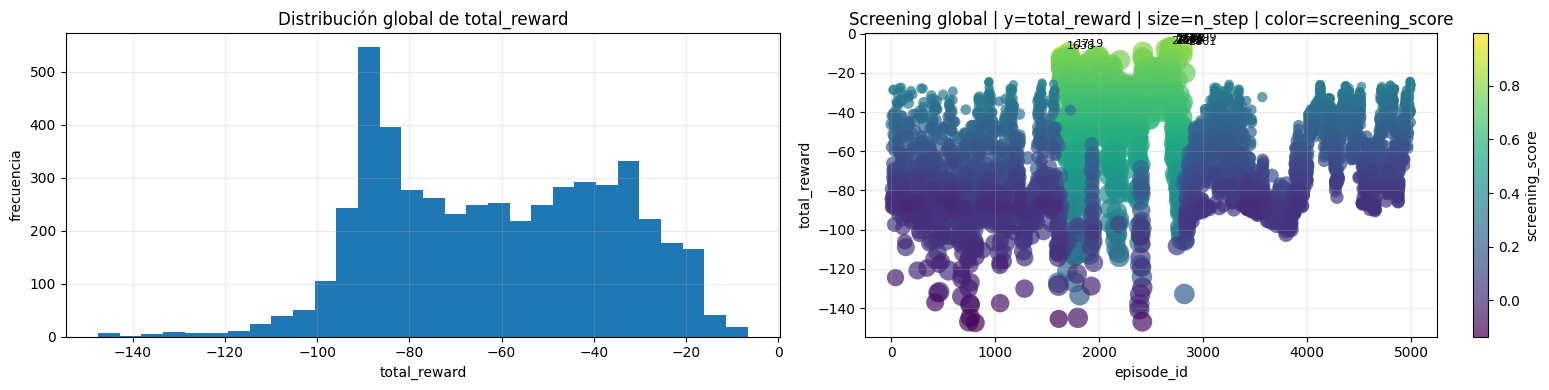

In [12]:
# --- CONFIGURACIÓN CELDA ---
PLOT_X = 'episode_id'
PLOT_Y = 'total_reward'
PLOT_SIZE = 'n_step'
PLOT_COLOR = 'screening_score'
ANNOTATE_TOP_N = 10
ALPHA = 0.70

plot_df = screening_view.copy()

x = pd.to_numeric(plot_df[PLOT_X], errors='coerce').to_numpy()
y = pd.to_numeric(plot_df[PLOT_Y], errors='coerce').to_numpy()

size_01 = minmax_01(plot_df[PLOT_SIZE])
sizes = 40 + 180 * size_01.to_numpy()

color_values = pd.to_numeric(plot_df[PLOT_COLOR], errors='coerce').fillna(0.0).to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(pd.to_numeric(plot_df['total_reward'], errors='coerce').dropna(), bins=30)
axes[0].set_title('Distribución global de total_reward')
axes[0].set_xlabel('total_reward')
axes[0].set_ylabel('frecuencia')

sc = axes[1].scatter(
    x,
    y,
    s=sizes,
    c=color_values,
    cmap='viridis',
    alpha=ALPHA,
    edgecolor='none'
)

axes[1].set_xlabel(PLOT_X)
axes[1].set_ylabel(PLOT_Y)
axes[1].set_title(f'Screening global | y={PLOT_Y} | size={PLOT_SIZE} | color={PLOT_COLOR}')

annot_df = screening_view.head(ANNOTATE_TOP_N)

for _, row in annot_df.iterrows():
    axes[1].annotate(
        str(int(row['episode_id'])),
        (row[PLOT_X], row[PLOT_Y]),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

cb = plt.colorbar(sc, ax=axes[1])
cb.set_label(PLOT_COLOR)

plt.tight_layout()
plt.show()

- Esta salida deja construido el **índice global de episodios**.
- Su función no es explicar todavía el reward, sino **screenear casos candidatos** para auditoría.
- La salida útil que se hereda es: `global_df`, `screening_view`, `screening_top_df` y `episode_lookup`.

## Caja 3 - Selección y carga de episodio

In [13]:
selection_universe_df = screening_view.loc[:, [
    'episode_id',
    'total_reward',
    'reward_per_interval',
    'episode_duration_sec',
    'n_step',
    'n_interval',
    'end_termination_reason',
    'screening_score',
]].copy()

display(selection_universe_df.head(TOP_N))

,episode_id,total_reward,reward_per_interval,episode_duration_sec,n_step,n_interval,end_termination_reason,screening_score
0,2799,-6.628004,-0.032812,4.034,4035,202,stabilization_success,0.997555
1,2672,-7.960759,-0.032100,4.956,4957,248,stabilization_success,0.993587
2,1719,-9.697548,-0.053283,3.635,3636,182,stabilization_success,0.979417
3,1638,-10.701774,-0.049545,4.320,4321,216,stabilization_success,0.977730
4,2692,-6.727666,-0.026803,5.020,5021,251,time_limit,0.799682
5,2688,-7.096501,-0.028273,5.020,5021,251,time_limit,0.797905
6,2671,-7.171103,-0.028570,5.020,5021,251,time_limit,0.797546
7,2680,-7.542399,-0.030049,5.020,5021,251,time_limit,0.795758
8,2638,-7.922201,-0.031563,5.020,5021,251,time_limit,0.793928
9,2801,-8.411367,-0.033511,5.020,5021,251,time_limit,0.791573


In [14]:
# --- CONFIGURACIÓN CELDA ---
EPISODE_SOURCE = 'ranking'   # 'ranking' | 'manual'
RANK_ROW = 0
EPISODE_ID_MANUAL = 4500

In [15]:
if EPISODE_SOURCE == 'ranking':
    EPISODE_ID = int(screening_top_df.iloc[RANK_ROW]['episode_id'])
else:
    EPISODE_ID = int(EPISODE_ID_MANUAL)

selected_episode_row_df = global_df.loc[global_df['episode_id'] == EPISODE_ID].copy()
display(selected_episode_row_df)

,episode_id,source_chunk,n_step,n_interval,episode_duration_sec,total_reward,end_termination_reason,end_terminated,total_agent_decisions,goal_bonus,accumulated_band_bonus,epsilon,learning_rate,reward_per_step,reward_per_interval,is_success,is_limit_exceeded,is_time_limit,screening_score
2799,2799,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...,4035,202,4.034,-6.628004,stabilization_success,True,202,0.0,0.0,0.039815,0.02449,-0.001643,-0.032812,1,0,0,0.997555


In [16]:
episode, source_chunk = load_episode_from_lookup(episode_lookup, EPISODE_ID)

step_data = episode['step_data']
interval_data = episode['interval_data']
end_data = episode['end_episode_data']

episode_load_resume_df = pd.DataFrame([
    {'field': 'EPISODE_ID', 'value': EPISODE_ID},
    {'field': 'source_chunk', 'value': str(source_chunk)},
    {'field': 'n_step', 'value': step_data['n_step']},
    {'field': 'n_interval', 'value': interval_data['n_interval']},
    {'field': 'n_step_keys', 'value': len(step_data.keys())},
    {'field': 'n_interval_keys', 'value': len(interval_data.keys())},
    {'field': 'n_end_episode_keys', 'value': len(end_data.keys())},
])

display(episode_load_resume_df)

,field,value
0,EPISODE_ID,2799
1,source_chunk,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
2,n_step,4035
3,n_interval,202
4,n_step_keys,37
5,n_interval_keys,73
6,n_end_episode_keys,8


In [17]:
episode_section_inventory_df = pd.DataFrame([
    {'section': 'step_data', 'keys': list(step_data.keys())},
    {'section': 'interval_data', 'keys': list(interval_data.keys())},
    {'section': 'end_episode_data', 'keys': list(end_data.keys())},
])

display(episode_section_inventory_df)

,section,keys
0,step_data,"[n_step, t_sec, cart_position_raw, cart_veloci..."
1,interval_data,"[n_interval, interval_id, interval_start_step_..."
2,end_episode_data,"[end_terminated, end_termination_reason, total..."


- Esta caja deja fijado el **episodio objetivo**.
- La salida útil que se hereda es: `episode`, `step_data`, `interval_data`, `end_data`, `EPISODE_ID` y `source_chunk`.
- La siguiente caja ya puede construir `step_df` e `interval_df` y recién ahí mostrar familias disponibles para el análisis posterior.

## Caja 4 - DataFrames + inventario de familias
- Se construyen `step_df` e `interval_df` desde el episodio ya seleccionado.
- Esta caja no decide el análisis, solo deja explícito **qué material real existe** para las siguientes secciones.
- El objetivo es separar con claridad:
  - base step-level;
  - base interval-level;
  - familias funcionales disponibles;
  - insumos que alimentarán las siguientes cajas.

In [23]:
step_df, skipped_step_keys = build_section_df(step_data, 'n_step')
interval_df, skipped_interval_keys = build_section_df(interval_data, 'n_interval')

step_df = step_df.reset_index(drop=True)
interval_df = interval_df.reset_index(drop=True)

step_col_map = build_step_column_map(step_df)
interval_col_map = build_interval_column_map(interval_df)

step_shape_df = pd.DataFrame([
    {'artifact': 'step_df', 'n_rows': step_df.shape[0], 'n_cols': step_df.shape[1]},
    {'artifact': 'interval_df', 'n_rows': interval_df.shape[0], 'n_cols': interval_df.shape[1]},
])

display(step_shape_df)

,artifact,n_rows,n_cols
0,step_df,4035,36
1,interval_df,202,62


In [27]:
step_inventory_df = build_col_inventory_df(step_col_map)
interval_inventory_df = build_col_inventory_df(interval_col_map)

display(step_inventory_df)
display(interval_inventory_df)

,family,n_cols,cols
0,dynamic_raw,5,"[cart_position_raw, cart_velocity_raw, pendulu..."
1,dynamic_norm,4,"[cart_position_norm, cart_velocity_norm, pendu..."
2,controller_global,6,"[t_sec, cart_force, u_total, u_total_raw, is_s..."
3,controller_error,8,"[error_pendulum_angle, error_cart_position, de..."
4,controller_action,4,"[control_action_pendulum_angle, control_action..."
5,controller_effective_action,4,"[u_eff_pendulum_angle, u_eff_cart_position, de..."
6,controller_gains,6,"[kp_pendulum_angle, kp_cart_position, ki_pendu..."
7,other,0,[]


,family,n_cols,cols
0,interval_meta,5,"[interval_id, interval_start_step_idx, interva..."
1,termination_meta,0,[]
2,principal_terms,6,"[L_e_pendulum_angle, L_e_cart_position, L_edot..."
3,principal_feature_values,0,[]
4,principal_feature_rewards,0,[]
5,principal_gates,2,"[principal_gate_L_edot_pendulum_angle, princip..."
6,principal_contributions,2,"[principal_contribution_L_edot_pendulum_angle,..."
7,processed_metric_aggregates,2,"[delta_u_eff_pendulum_angle_mean_squared, delt..."
8,global_reward,1,[global_interval_reward]
9,assigned_agent_rewards,6,"[reward_kp_pendulum_angle, reward_ki_pendulum_..."


In [30]:
raw_episode_sections_df = pd.DataFrame([
    {'section': 'step_data', 'n_keys': len(step_data.keys()), 'keys': list(step_data.keys())},
    {'section': 'interval_data', 'n_keys': len(interval_data.keys()), 'keys': list(interval_data.keys())},
    {'section': 'end_episode_data', 'n_keys': len(end_data.keys()), 'keys': list(end_data.keys())},
])

display(raw_episode_sections_df)

,section,n_keys,keys
0,step_data,37,"[n_step, t_sec, cart_position_raw, cart_veloci..."
1,interval_data,73,"[n_interval, interval_id, interval_start_step_..."
2,end_episode_data,8,"[end_terminated, end_termination_reason, total..."


In [31]:
skipped_section_keys_df = pd.DataFrame([
    {'section': 'step_data', 'skipped_keys': skipped_step_keys},
    {'section': 'interval_data', 'skipped_keys': skipped_interval_keys},
])

display(skipped_section_keys_df)

,section,skipped_keys
0,step_data,[]
1,interval_data,"[principal_gate_L_delta_u_pendulum_angle, prin..."


In [32]:
# --- CONFIGURACIÓN CELDA ---
STEP_HEAD_N = 5
INTERVAL_HEAD_N = 8

STEP_FAMILIES_TO_PREVIEW = [
    'dynamic_raw',
    'dynamic_norm',
    'controller_global',
    'controller_error',
    'controller_action',
    'controller_effective_action',
    'controller_gains',
]

INTERVAL_FAMILIES_TO_PREVIEW = [
    'interval_meta',
    'termination_meta',
    'principal_terms',
    'global_reward',
    'assigned_agent_rewards',
    'extra_rewards',
    'coordination_rewards',
    'agent_actions',
    'learning_update',
    'learning_stats',
    'learning_params',
]

In [33]:
step_preview_cols = []
for family in STEP_FAMILIES_TO_PREVIEW:
    step_preview_cols.extend(step_col_map[family])

interval_preview_cols = []
for family in INTERVAL_FAMILIES_TO_PREVIEW:
    interval_preview_cols.extend(interval_col_map[family])

step_preview_cols = list(dict.fromkeys(step_preview_cols))
interval_preview_cols = list(dict.fromkeys(interval_preview_cols))

In [34]:
print('step_df preview')
display(step_df[step_preview_cols].head(STEP_HEAD_N))

print('interval_df preview')
display(interval_df[interval_preview_cols].head(INTERVAL_HEAD_N))

step_df preview


,cart_position_raw,cart_velocity_raw,pendulum_angle_raw,pendulum_velocity_raw,u_total_raw,cart_position_norm,cart_velocity_norm,pendulum_angle_norm,pendulum_velocity_norm,t_sec,cart_force,u_total,is_saturated_global,delta_u_total,error_pendulum_angle,error_cart_position,delta_error_pendulum_angle,delta_error_cart_position,derivative_error_pendulum_angle,derivative_error_cart_position,integral_error_pendulum_angle,integral_error_cart_position,control_action_pendulum_angle,control_action_cart_position,delta_control_action_pendulum_angle,delta_control_action_cart_position,u_eff_pendulum_angle,u_eff_cart_position,delta_u_eff_pendulum_angle,delta_u_eff_cart_position,kp_pendulum_angle,kp_cart_position,ki_pendulum_angle,ki_cart_position,kd_pendulum_angle,kd_cart_position
0,0.000000e+00,0.000000,0.157,0.000000,0.000000,0.000000e+00,0.000000,0.149924,0.000000,0.000,0.000000,0.000000,False,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0
1,7.452986e-07,0.001491,0.157,0.000062,0.225110,1.490597e-07,0.000186,0.149924,0.000015,0.001,9.004412,0.225110,False,0.225110,0.149924,0.000000e+00,1.499236e-01,0.000000e+00,0.000000,0.000000,0.00015,0.000000e+00,0.225110,0.000000,0.225110,0.000000,0.225110,0.000000,0.225110,0.000000,1.5,0.5,1.5,1.0,1.0,0.5
2,2.981910e-06,0.002983,0.157,0.000122,0.225290,5.963819e-07,0.000373,0.149924,0.000030,0.002,9.011601,0.225290,False,0.000180,0.149924,-1.490597e-07,2.940548e-08,-1.490597e-07,0.000029,-0.000149,0.00030,-1.490597e-10,0.225365,-0.000075,0.000254,-0.000075,0.225365,-0.000075,0.000254,-0.000075,1.5,0.5,1.5,1.0,1.0,0.5
3,6.711081e-06,0.004476,0.157,0.000181,0.225424,1.342216e-06,0.000559,0.149924,0.000045,0.003,9.016953,0.225424,False,0.000134,0.149924,-5.963819e-07,8.754260e-08,-4.473222e-07,0.000088,-0.000447,0.00045,-7.454416e-10,0.225648,-0.000224,0.000283,-0.000149,0.225648,-0.000224,0.000283,-0.000149,1.5,0.5,1.5,1.0,1.0,0.5
4,1.193387e-05,0.005970,0.157,0.000239,0.225556,2.386774e-06,0.000746,0.149924,0.000060,0.004,9.022250,0.225556,False,0.000132,0.149924,-1.342216e-06,1.445045e-07,-7.458342e-07,0.000145,-0.000746,0.00060,-2.087658e-09,0.225930,-0.000374,0.000282,-0.000150,0.225930,-0.000374,0.000282,-0.000150,1.5,0.5,1.5,1.0,1.0,0.5


interval_df preview


,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_n_steps,L_e_pendulum_angle,L_e_cart_position,L_edot_pendulum_angle,L_edot_cart_position,L_delta_u_pendulum_angle,L_delta_u_cart_position,global_interval_reward,reward_kp_pendulum_angle,reward_ki_pendulum_angle,reward_kd_pendulum_angle,reward_kp_cart_position,reward_ki_cart_position,reward_kd_cart_position,extra_penalty_instantaneous_pendulum_angle,extra_penalty_instantaneous_cart_position,extra_penalty_pendulum_angle,extra_penalty_cart_position,extra_bonus_goal_pendulum_angle,extra_bonus_goal_cart_position,extra_bonus_band_pendulum_angle,extra_bonus_band_cart_position,extra_conditional_dynamic_penalty_pendulum_angle,extra_conditional_dynamic_penalty_cart_position,extra_conditional_dynamic_incentive_pendulum_angle,extra_conditional_dynamic_incentive_cart_position,extra_conditional_dynamic_incentive_tracking_pendulum_angle,extra_conditional_dynamic_incentive_tracking_cart_position,extra_conditional_dynamic_incentive_capture_pendulum_angle,extra_conditional_dynamic_incentive_capture_cart_position,extra_conditional_dynamic_incentive_direction_pendulum_angle,extra_conditional_dynamic_incentive_direction_cart_position,extra_conditional_dynamic_incentive_effort_pendulum_angle,extra_conditional_dynamic_incentive_effort_cart_position,extra_total_pendulum_angle,extra_total_cart_position,extra_conditional_coordination_bonus_pendulum_angle,extra_conditional_coordination_bonus_cart_position,coordination_task_potential,coordination_task_progress_delta,coordination_task_progress_positive,coordination_reward_total,coordination_credit_raw_pendulum_angle,coordination_credit_raw_cart_position,coordination_credit_share_pendulum_angle,coordination_credit_share_cart_position,action_kp_pendulum_angle,action_ki_pendulum_angle,action_kd_pendulum_angle,action_kp_cart_position,action_ki_cart_position,action_kd_cart_position
0,0,0,19,0.00,20,0.149927,0.000025,0.000371,0.004002,0.002534,2.094554e-08,-0.123355,-0.123353,-0.123353,-0.123353,-0.000002,-0.000002,-0.000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.082938,0.000000,0.0,0.0,0.034143,3.938574e-08,0.999970,0.000001,2,2,1,0,1,0
1,1,20,39,0.02,20,0.149911,0.000154,0.003131,0.012601,0.000295,4.424565e-08,-0.124123,-0.124099,-0.124099,-0.124099,-0.000024,-0.000024,-0.000024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.084361,-0.001423,0.0,0.0,0.045765,7.811348e-07,0.999961,0.000017,2,2,1,1,1,1
2,2,40,59,0.04,20,0.149700,0.000447,0.012805,0.024171,0.000303,7.144016e-08,-0.124731,-0.124644,-0.124644,-0.124644,-0.000087,-0.000087,-0.000087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.087380,-0.003020,0.0,0.0,0.056115,4.407068e-06,0.999904,0.000079,2,2,1,1,1,1
3,3,60,79,0.06,20,0.149098,0.000947,0.028660,0.038198,0.000311,1.014971e-07,-0.124900,-0.124680,-0.124680,-0.124680,-0.000220,-0.000220,-0.000220,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.091697,-0.004317,0.0,0.0,0.065123,1.489798e-05,0.999756,0.000229,2,2,1,1,1,1
4,4,80,99,0.08,20,0.147920,0.001692,0.051192,0.054826,0.000517,1.487805e-07,-0.124894,-0.124435,-0.124435,-0.124435,-0.000459,-0.000459,-0.000459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.097331,-0.005633,0.0,0.0,0.076972,3.856547e-05,0.999486,0.000501,2,1,0,1,1,1
5,5,100,119,0.10,20,0.145929,0.002733,0.083262,0.075158,0.000827,2.328594e-07,-0.124949,-0.124076,-0.124076,-0.124076,-0.000873,-0.000873,-0.000873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.104839,-0.007508,0.0,0.0,0.093589,8.607694e-05,0.999070,0.000919,2,2,0,1,1,1
6,6,120,139,0.12,20,0.142816,0.004133,0.125006,0.099224,0.000329,3.094945e-07,-0.123599,-0.122058,-0.122058,-0.122058,-0.001540,-0.001540,-0.001540,0.0,0.0,

In [35]:
analysis_input_df = pd.DataFrame([
    {
        'next_box': 'Caja 5 - Ficha técnica del episodio',
        'source_df': 'step_df + interval_df + end_data',
        'families': ['dynamic_raw', 'controller_global', 'principal_terms', 'global_reward', 'extra_rewards', 'coordination_rewards'],
    },
    {
        'next_box': 'Caja 6 - Timeline maestro interval-level',
        'source_df': 'interval_df + agregados desde step_df',
        'families': ['interval_meta', 'principal_terms', 'global_reward', 'assigned_agent_rewards', 'agent_actions', 'learning_update'],
    },
    {
        'next_box': 'Caja 7 - Timeline step-level',
        'source_df': 'step_df',
        'families': ['dynamic_raw', 'dynamic_norm', 'controller_global', 'controller_error', 'controller_action', 'controller_effective_action'],
    },
    {
        'next_box': 'Caja 8 - Sanity check físico',
        'source_df': 'step_df + interval_df',
        'families': ['dynamic_raw', 'dynamic_norm', 'principal_terms', 'global_reward'],
    },
    {
        'next_box': 'Caja 9 - Auditoría del controlador',
        'source_df': 'step_df + interval_df',
        'families': ['controller_global', 'controller_error', 'controller_action', 'controller_effective_action', 'controller_gains'],
    },
    {
        'next_box': 'Caja 10 - Puente step -> interval',
        'source_df': 'step_df + interval_df',
        'families': ['controller_error', 'controller_action', 'controller_effective_action', 'processed_metric_aggregates', 'principal_terms'],
    },
])

display(analysis_input_df)

,next_box,source_df,families
0,Caja 5 - Ficha técnica del episodio,step_df + interval_df + end_data,"[dynamic_raw, controller_global, principal_ter..."
1,Caja 6 - Timeline maestro interval-level,interval_df + agregados desde step_df,"[interval_meta, principal_terms, global_reward..."
2,Caja 7 - Timeline step-level,step_df,"[dynamic_raw, dynamic_norm, controller_global,..."
3,Caja 8 - Sanity check físico,step_df + interval_df,"[dynamic_raw, dynamic_norm, principal_terms, g..."
4,Caja 9 - Auditoría del controlador,step_df + interval_df,"[controller_global, controller_error, controll..."
5,Caja 10 - Puente step -> interval,step_df + interval_df,"[controller_error, controller_action, controll..."


- Esta caja deja construidas las dos bases reales del episodio: `step_df` e `interval_df`.
- También deja explícitas las familias disponibles sin automatizar decisiones.
- La salida útil para las siguientes cajas es:
  - `step_df`
  - `interval_df`
  - `step_col_map`
  - `interval_col_map`
  - `step_inventory_df`
  - `interval_inventory_df`

## Caja 5 - Ficha técnica del episodio orientada a reward
- Se construye una ficha compacta para contextualizar el episodio antes del análisis causal fino.
- La ficha debe permitir ver rápidamente:
  - consistencia entre `total_reward` y suma interval-level;
  - duración real;
  - tipo de término;
  - magnitud y dispersión del reward por intervalo;
  - presencia estructural de extras y coordinación;
  - uso de saturación;
  - error medio por lazo.

In [36]:
reward_presence_df = pd.DataFrame([
    {'family': 'global_reward', 'n_cols': len(interval_col_map['global_reward']), 'cols': interval_col_map['global_reward']},
    {'family': 'assigned_agent_rewards', 'n_cols': len(interval_col_map['assigned_agent_rewards']), 'cols': interval_col_map['assigned_agent_rewards']},
    {'family': 'extra_rewards', 'n_cols': len(interval_col_map['extra_rewards']), 'cols': interval_col_map['extra_rewards']},
    {'family': 'coordination_rewards', 'n_cols': len(interval_col_map['coordination_rewards']), 'cols': interval_col_map['coordination_rewards']},
    {'family': 'principal_terms', 'n_cols': len(interval_col_map['principal_terms']), 'cols': interval_col_map['principal_terms']},
])

display(reward_presence_df)

,family,n_cols,cols
0,global_reward,1,[global_interval_reward]
1,assigned_agent_rewards,6,"[reward_kp_pendulum_angle, reward_ki_pendulum_..."
2,extra_rewards,24,"[extra_penalty_instantaneous_pendulum_angle, e..."
3,coordination_rewards,8,"[coordination_task_potential, coordination_tas..."
4,principal_terms,6,"[L_e_pendulum_angle, L_e_cart_position, L_edot..."


In [43]:
available_dynamic_vars = sorted([
    c.replace('_raw', '')
    for c in step_col_map['dynamic_raw']
])

available_control_loop_var_objs = extract_control_loop_var_objs(step_df)

available_loop_signals_df = pd.DataFrame([
    {
        'group': 'available_dynamic_vars',
        'values': available_dynamic_vars,
    },
    {
        'group': 'available_control_loop_var_objs',
        'values': available_control_loop_var_objs,
    },
])

display(available_loop_signals_df)

,group,values
0,available_dynamic_vars,"[cart_position, cart_velocity, pendulum_angle,..."
1,available_control_loop_var_objs,"[cart_position, pendulum_angle]"


In [44]:
# --- CONFIGURACIÓN CELDA ---
VAR_OBJS_TO_SUMMARIZE = available_control_loop_var_objs

EPISODE_CARD_FIELDS = [
    'episode_id',
    'end_termination_reason',
    'end_terminated',
    'n_steps',
    'n_intervals',
    't_end_sec',
    'total_reward_end_data',
    'total_reward_sum_intervals',
    'reward_gap_end_vs_interval_sum',
    'reward_mean_interval',
    'reward_std_interval',
    'reward_min_interval',
    'reward_max_interval',
    'total_agent_decisions',
    'epsilon',
    'learning_rate',
    'has_extra_rewards',
    'has_coordination_rewards',
    'sat_ratio_global_steps',
]

LOOP_SUMMARY_FIELDS = [
    'var_obj',
    'mean_abs_raw_state',
    'max_abs_raw_state',
    'mean_abs_error',
    'max_abs_error',
    'mean_abs_control_action',
    'mean_abs_u_eff',
]

SHOW_INTERVAL_REWARD_PLOT = True

In [45]:
n_steps = int(step_df.shape[0])
n_intervals = int(interval_df.shape[0])

t_end_sec = float(pd.to_numeric(step_df['t_sec'], errors='coerce').max())

reward_interval_series = pd.to_numeric(interval_df['global_interval_reward'], errors='coerce')
reward_sum_intervals = float(reward_interval_series.fillna(0.0).sum())
reward_gap_end_vs_intervals = float(end_data['total_reward']) - reward_sum_intervals

extra_total_cols = [c for c in interval_df.columns if c.startswith('extra_total_')]
coordination_cols = [c for c in interval_df.columns if c.startswith('coordination_')]

episode_core_card = {
    'episode_id': int(EPISODE_ID),
    'source_chunk': str(source_chunk),
    'end_terminated': bool(end_data['end_terminated']),
    'end_termination_reason': end_data['end_termination_reason'],
    'n_steps': n_steps,
    'n_intervals': n_intervals,
    't_end_sec': t_end_sec,
    'total_reward_end_data': float(end_data['total_reward']),
    'total_reward_sum_intervals': reward_sum_intervals,
    'reward_gap_end_vs_interval_sum': reward_gap_end_vs_intervals,
    'reward_mean_interval': float(reward_interval_series.mean()),
    'reward_std_interval': float(reward_interval_series.std()),
    'reward_min_interval': float(reward_interval_series.min()),
    'reward_max_interval': float(reward_interval_series.max()),
    'total_agent_decisions': int(end_data['total_agent_decisions']),
    'epsilon': float(end_data['epsilon']),
    'learning_rate': float(end_data['learning_rate']),
    'has_extra_rewards': len(extra_total_cols) > 0,
    'has_coordination_rewards': len(coordination_cols) > 0,
    'sat_ratio_global_steps': bool_mean_col(step_df, 'is_saturated_global'),
}

episode_core_card_df = pd.DataFrame([
    {'field': key, 'value': value}
    for key, value in episode_core_card.items()
])

episode_core_card_df = episode_core_card_df[
    episode_core_card_df['field'].isin(EPISODE_CARD_FIELDS)
].reset_index(drop=True)

display(episode_core_card_df)

,field,value
0,episode_id,2799
1,end_terminated,True
2,end_termination_reason,stabilization_success
3,n_steps,4035
4,n_intervals,202
5,t_end_sec,4.034
6,total_reward_end_data,-6.628004
7,total_reward_sum_intervals,-6.628004
8,reward_gap_end_vs_interval_sum,0.0
9,reward_mean_interval,-0.032812


In [46]:
loop_summary_rows = []

for var_obj in VAR_OBJS_TO_SUMMARIZE:
    raw_col = f'{var_obj}_raw'
    err_col = f'error_{var_obj}'
    u_col = f'control_action_{var_obj}'
    ueff_col = f'u_eff_{var_obj}'

    row = {
        'var_obj': var_obj,
        'mean_abs_raw_state': mean_abs_col(step_df, raw_col),
        'max_abs_raw_state': max_abs_col(step_df, raw_col),
        'mean_abs_error': mean_abs_col(step_df, err_col),
        'max_abs_error': max_abs_col(step_df, err_col),
        'mean_abs_control_action': mean_abs_col(step_df, u_col),
        'mean_abs_u_eff': mean_abs_col(step_df, ueff_col),
    }

    loop_summary_rows.append(row)

loop_summary_df = pd.DataFrame(loop_summary_rows)
loop_summary_df = loop_summary_df[LOOP_SUMMARY_FIELDS]

display(loop_summary_df)

,var_obj,mean_abs_raw_state,max_abs_raw_state,mean_abs_error,max_abs_error,mean_abs_control_action,mean_abs_u_eff
0,cart_position,0.236929,0.442574,0.047381,0.088515,0.052087,0.051216
1,pendulum_angle,0.025523,0.157012,0.024369,0.149935,0.157291,0.148793


In [41]:
assigned_reward_cols = interval_col_map['assigned_agent_rewards']
principal_term_cols = interval_col_map['principal_terms']

reward_structure_card = {
    'principal_reward_sum': sum_existing_frame_cols(interval_df, ['principal_reward']),
    'global_interval_reward_sum': sum_existing_frame_cols(interval_df, ['global_interval_reward']),
    'assigned_reward_sum_all_agents_all_intervals': sum_existing_frame_cols(interval_df, assigned_reward_cols),
    'extra_reward_sum_all_columns': sum_existing_frame_cols(interval_df, extra_total_cols),
    'coordination_reward_sum_all_columns': sum_existing_frame_cols(interval_df, coordination_cols),
    'principal_terms_sum_all_columns': sum_existing_frame_cols(interval_df, principal_term_cols),
    'n_assigned_reward_cols': len(assigned_reward_cols),
    'n_extra_reward_cols': len(extra_total_cols),
    'n_coordination_reward_cols': len(coordination_cols),
    'n_principal_term_cols': len(principal_term_cols),
}

reward_structure_df = pd.DataFrame([
    {'field': key, 'value': value}
    for key, value in reward_structure_card.items()
])

display(reward_structure_df)

,field,value
0,principal_reward_sum,NaN
1,global_interval_reward_sum,-6.628004
2,assigned_reward_sum_all_agents_all_intervals,-19.884011
3,extra_reward_sum_all_columns,0.000000
4,coordination_reward_sum_all_columns,204.305398
5,principal_terms_sum_all_columns,37.479052
6,n_assigned_reward_cols,6.000000
7,n_extra_reward_cols,2.000000
8,n_coordination_reward_cols,8.000000
9,n_principal_term_cols,6.000000


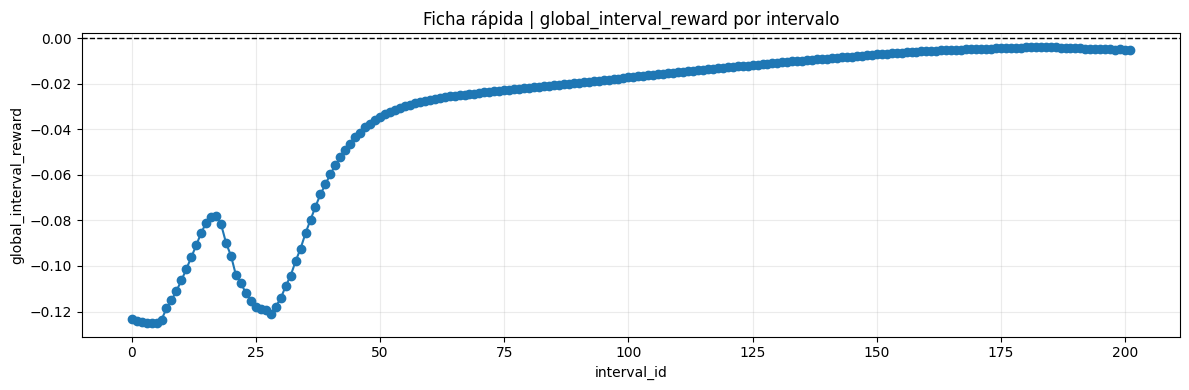

In [42]:
if SHOW_INTERVAL_REWARD_PLOT:
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        interval_df['interval_id'],
        pd.to_numeric(interval_df['global_interval_reward'], errors='coerce'),
        marker='o',
        linewidth=1.5
    )

    ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--')
    ax.set_title('Ficha rápida | global_interval_reward por intervalo')
    ax.set_xlabel('interval_id')
    ax.set_ylabel('global_interval_reward')

    plt.tight_layout()
    plt.show()

- Esta ficha no reemplaza el análisis causal.
- Su función es dejar contextualizado el episodio antes del timeline y de la auditoría del reward.
- La salida útil que hereda el notebook es:
  - `episode_core_card_df`
  - `loop_summary_df`
  - `reward_structure_df`

## Caja 6 - Timeline maestro interval-level
- Se construye la tabla madre del análisis.
- La lógica de esta caja es integrar en una sola base:
  - metadata temporal del intervalo;
  - agregados físicos y de control construidos desde `step_df`;
  - métricas interval-level ya persistidas en `interval_df`;
  - reward global, rewards por agente, extras, coordinación y acciones.
- Esta caja no resuelve todavía los problemas del reward, pero sí deja la base causal desde donde se podrán leer.

In [49]:
interval_family_resume_df = pd.DataFrame([
    {'family': family, 'n_cols': len(cols), 'cols': cols}
    for family, cols in interval_col_map.items()
])

display(interval_family_resume_df)

,family,n_cols,cols
0,interval_meta,5,"[interval_id, interval_start_step_idx, interva..."
1,termination_meta,0,[]
2,principal_terms,6,"[L_e_pendulum_angle, L_e_cart_position, L_edot..."
3,principal_feature_values,0,[]
4,principal_feature_rewards,0,[]
5,principal_gates,2,"[principal_gate_L_edot_pendulum_angle, princip..."
6,principal_contributions,2,"[principal_contribution_L_edot_pendulum_angle,..."
7,processed_metric_aggregates,2,"[delta_u_eff_pendulum_angle_mean_squared, delt..."
8,global_reward,1,[global_interval_reward]
9,assigned_agent_rewards,6,"[reward_kp_pendulum_angle, reward_ki_pendulum_..."


In [50]:
step_agg_candidates_df = pd.DataFrame([
    {'group': 'dynamic_raw', 'cols': step_col_map['dynamic_raw']},
    {'group': 'controller_global', 'cols': step_col_map['controller_global']},
    {'group': 'controller_error', 'cols': step_col_map['controller_error']},
    {'group': 'controller_action', 'cols': step_col_map['controller_action']},
    {'group': 'controller_effective_action', 'cols': step_col_map['controller_effective_action']},
    {'group': 'controller_gains', 'cols': step_col_map['controller_gains']},
])

display(step_agg_candidates_df)

,group,cols
0,dynamic_raw,"[cart_position_raw, cart_velocity_raw, pendulu..."
1,controller_global,"[t_sec, cart_force, u_total, u_total_raw, is_s..."
2,controller_error,"[error_pendulum_angle, error_cart_position, de..."
3,controller_action,"[control_action_pendulum_angle, control_action..."
4,controller_effective_action,"[u_eff_pendulum_angle, u_eff_cart_position, de..."
5,controller_gains,"[kp_pendulum_angle, kp_cart_position, ki_pendu..."


In [51]:
# --- CONFIGURACIÓN CELDA ---
INTERVAL_BASE_FAMILIES = [
    'interval_meta',
    'termination_meta',
    'principal_terms',
    'principal_gates',
    'principal_contributions',
    'processed_metric_aggregates',
    'global_reward',
    'assigned_agent_rewards',
    'extra_rewards',
    'coordination_rewards',
    'agent_actions',
    'learning_update',
    'learning_stats',
    'learning_params',
]

STEP_TO_INTERVAL_AGG_JOBS = [
    ('pendulum_angle_raw', 'mean_abs', 'pendulum_angle_mean_abs'),
    ('pendulum_velocity_raw', 'mean_abs', 'pendulum_velocity_mean_abs'),
    ('cart_position_raw', 'mean_abs', 'cart_position_mean_abs'),
    ('cart_velocity_raw', 'mean_abs', 'cart_velocity_mean_abs'),
    ('cart_force', 'mean_abs', 'cart_force_mean_abs'),

    ('u_total', 'mean_abs', 'u_total_mean_abs'),
    ('u_total_raw', 'mean_abs', 'u_total_raw_mean_abs'),
    ('u_total_saturated', 'mean_abs', 'u_total_saturated_mean_abs'),
    ('delta_u_total', 'mean_abs', 'delta_u_total_mean_abs'),
    ('is_saturated_global', 'proportion_true', 'sat_prp_interval'),
]

for var_obj in available_control_loop_var_objs:
    STEP_TO_INTERVAL_AGG_JOBS.extend([
        (f'error_{var_obj}', 'mean_abs', f'error_{var_obj}_mean_abs'),
        (f'derivative_error_{var_obj}', 'mean_abs', f'derivative_error_{var_obj}_mean_abs'),
        (f'integral_error_{var_obj}', 'mean_abs', f'integral_error_{var_obj}_mean_abs'),
        (f'control_action_{var_obj}', 'mean_abs', f'control_action_{var_obj}_mean_abs'),
        (f'u_eff_{var_obj}', 'mean_abs', f'u_eff_{var_obj}_mean_abs'),
        (f'delta_u_eff_{var_obj}', 'mean_abs', f'delta_u_eff_{var_obj}_mean_abs'),
        (f'kp_{var_obj}', 'mean', f'kp_{var_obj}_mean'),
        (f'ki_{var_obj}', 'mean', f'ki_{var_obj}_mean'),
        (f'kd_{var_obj}', 'mean', f'kd_{var_obj}_mean'),
    ])

In [52]:
interval_base_cols = []

for family in INTERVAL_BASE_FAMILIES:
    interval_base_cols.extend(interval_col_map[family])

interval_base_cols = list(dict.fromkeys([c for c in interval_base_cols if c in interval_df.columns]))

In [53]:
interval_step_agg_df = build_interval_step_agg_df(interval_df, step_df, STEP_TO_INTERVAL_AGG_JOBS)

interval_timeline_df = interval_df[interval_base_cols].copy()
interval_timeline_df = interval_timeline_df.merge(interval_step_agg_df, on='interval_id', how='left')

interval_timeline_df['interval_t_end_sec'] = [
    float(step_df.iloc[int(end_idx)]['t_sec'])
    for end_idx in interval_timeline_df['interval_end_step_idx']
]

interval_timeline_df['interval_t_mid_sec'] = 0.5 * (
    interval_timeline_df['interval_t_start_sec'] +
    interval_timeline_df['interval_t_end_sec']
)

interval_timeline_df['interval_duration_sec'] = (
    interval_timeline_df['interval_t_end_sec'] -
    interval_timeline_df['interval_t_start_sec']
)

for var_obj in available_control_loop_var_objs:
    interval_timeline_df[f'principal_terms_total_{var_obj}'] = sum_existing_cols_rowwise(
        interval_timeline_df,
        [
            f'L_e_{var_obj}',
            f'L_edot_{var_obj}',
            f'L_I_{var_obj}',
            f'L_u_{var_obj}',
            f'L_delta_u_{var_obj}',
        ]
    )

interval_timeline_df['principal_terms_total_all'] = sum_existing_cols_rowwise(
    interval_timeline_df,
    [f'principal_terms_total_{var_obj}' for var_obj in available_control_loop_var_objs]
)

interval_timeline_df['assigned_rewards_total'] = sum_existing_cols_rowwise(
    interval_timeline_df,
    interval_col_map['assigned_agent_rewards']
)

extra_total_cols = [c for c in interval_timeline_df.columns if c.startswith('extra_total_')]
interval_timeline_df['extra_total_all'] = sum_existing_cols_rowwise(
    interval_timeline_df,
    extra_total_cols
)

if 'coordination_reward_total' not in interval_timeline_df.columns:
    coordination_bonus_cols = [
        c for c in interval_timeline_df.columns
        if c.startswith('extra_conditional_coordination_bonus_')
    ]
    interval_timeline_df['coordination_reward_total'] = sum_existing_cols_rowwise(
        interval_timeline_df,
        coordination_bonus_cols
    )

In [54]:
interval_timeline_requested_cols = [
    'interval_id',
    'interval_start_step_idx',
    'interval_end_step_idx',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'interval_t_mid_sec',
    'interval_duration_sec',
    'interval_n_steps',

    'pendulum_angle_mean_abs',
    'cart_position_mean_abs',
    'pendulum_velocity_mean_abs',
    'cart_velocity_mean_abs',

    'u_total_mean_abs',
    'delta_u_total_mean_abs',
    'sat_prp_interval',

    'principal_terms_total_all',
    'global_interval_reward',
    'assigned_rewards_total',
    'extra_total_all',
    'coordination_reward_total',

    'termination_reason',
]

for var_obj in available_control_loop_var_objs:
    interval_timeline_requested_cols.extend([
        f'principal_terms_total_{var_obj}',
        f'error_{var_obj}_mean_abs',
        f'control_action_{var_obj}_mean_abs',
        f'u_eff_{var_obj}_mean_abs',
    ])

interval_timeline_view_cols = [
    c for c in interval_timeline_requested_cols
    if c in interval_timeline_df.columns
]

interval_timeline_view_df = interval_timeline_df[interval_timeline_view_cols].copy()
display(interval_timeline_view_df)

,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_t_end_sec,interval_t_mid_sec,interval_duration_sec,interval_n_steps,pendulum_angle_mean_abs,cart_position_mean_abs,pendulum_velocity_mean_abs,cart_velocity_mean_abs,u_total_mean_abs,delta_u_total_mean_abs,sat_prp_interval,principal_terms_total_all,global_interval_reward,assigned_rewards_total,extra_total_all,coordination_reward_total,principal_terms_total_cart_position,error_cart_position_mean_abs,control_action_cart_position_mean_abs,u_eff_cart_position_mean_abs,principal_terms_total_pendulum_angle,error_pendulum_angle_mean_abs,control_action_pendulum_angle_mean_abs,u_eff_pendulum_angle_mean_abs
0,0,0,19,0.00,0.019,0.0095,0.019,20,0.157004,0.000092,0.000524,0.014223,0.214992,0.011370,0.0,0.156859,-0.123355,-0.370065,0.0,0.000000,0.004027,0.000016,0.001220,0.001220,0.152832,0.142430,0.216212,0.216212
1,1,20,39,0.02,0.039,0.0295,0.019,20,0.156987,0.000715,0.004261,0.049974,0.296878,0.004212,0.0,0.166092,-0.124123,-0.372368,0.0,0.000000,0.012755,0.000133,0.004757,0.004757,0.153337,0.149915,0.301635,0.301635
2,2,40,59,0.04,0.059,0.0495,0.019,20,0.156766,0.002165,0.019700,0.096798,0.362076,0.004737,0.0,0.187427,-0.124731,-0.374193,0.0,0.000000,0.024618,0.000414,0.009507,0.009507,0.162809,0.149719,0.371583,0.371583
3,3,60,79,0.06,0.079,0.0695,0.019,20,0.156135,0.004651,0.044918,0.153284,0.418540,0.005246,0.0,0.217212,-0.124900,-0.374699,0.0,0.000000,0.039145,0.000900,0.015344,0.015344,0.178068,0.149140,0.433884,0.433884
4,4,80,99,0.08,0.099,0.0895,0.019,20,0.154901,0.008365,0.080524,0.220098,0.493726,0.006228,0.0,0.256148,-0.124894,-0.374681,0.0,0.000000,0.056518,0.001629,0.022326,0.022326,0.199629,0.147995,0.516052,0.516052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,197,3940,3959,3.94,3.959,3.9495,0.019,20,0.012482,0.103246,0.028430,0.049083,0.026482,0.000733,0.0,0.062988,-0.004862,-0.014587,0.0,0.000023,0.032943,0.020659,0.181589,0.181589,0.030044,0.011892,0.208071,0.208071
198,198,3960,3979,3.96,3.979,3.9695,0.019,20,0.013032,0.102308,0.026254,0.044403,0.037933,0.000518,0.0,0.060814,-0.004973,-0.014918,0.0,0.000038,0.031600,0.020471,0.182000,0.182000,0.029214,0.012419,0.219933,0.219933
199,199,3980,3999,3.98,3.999,3.9895,0.019,20,0.013530,0.101473,0.023765,0.039306,0.032202,0.000545,0.0,0.058235,-0.004919,-0.014756,0.0,0.000064,0.030151,0.020303,0.182408,0.182408,0.028083,0.012897,0.214609,0.214609
200,200,4000,4019,4.00,4.019,4.0095,0.019,20,0.013981,0.100738,0.021210,0.034051,0.039957,0.000394,0.0,0.055608,-0.005009,-0.015026,0.0,0.000071,0.028700,0.020154,0.182812,0.182812,0.026908,0.013331,0.222769,0.222769


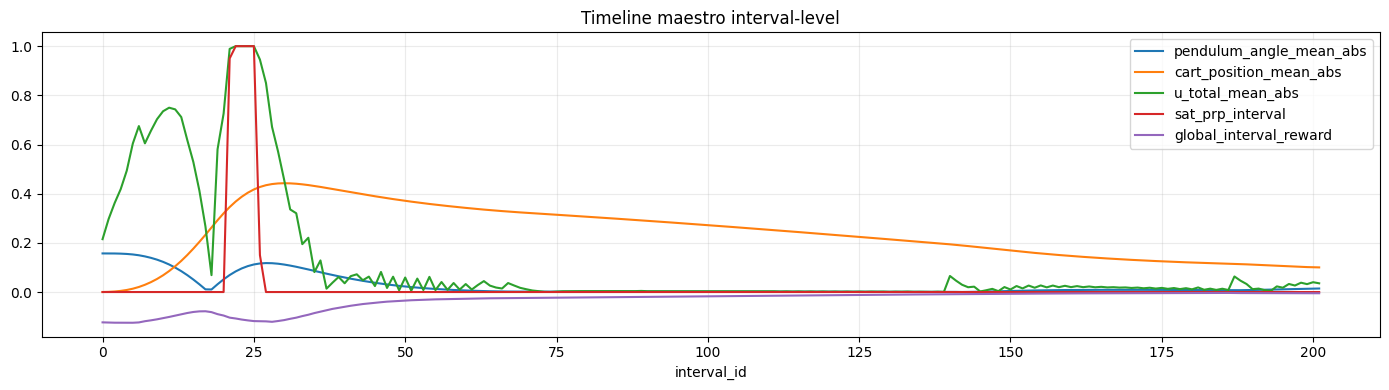

In [56]:
# --- CONFIGURACIÓN CELDA ---
INTERVAL_PLOT_COLS = [
    'pendulum_angle_mean_abs',
    'cart_position_mean_abs',
    'u_total_mean_abs',
    'sat_prp_interval',
    'global_interval_reward',
]

interval_plot_cols_existing = [c for c in INTERVAL_PLOT_COLS if c in interval_timeline_df.columns]

ax = interval_timeline_df.plot(
    x='interval_id',
    y=interval_plot_cols_existing,
    figsize=(14, 4),
    grid=True
)

ax.set_title('Timeline maestro interval-level')
ax.set_xlabel('interval_id')
plt.tight_layout()
plt.show()

- Esta caja deja construida la tabla madre del episodio a nivel interval-level.
- La salida útil que heredan las siguientes cajas es:
  - `interval_timeline_df`
  - `interval_timeline_view_df`
  - `interval_step_agg_df`
- Desde aquí ya se puede:
  - seguir la evolución temporal del episodio;
  - ubicar zonas problemáticas;
  - contrastar física agregada, control agregado y reward.

## Caja 7 - Timeline step-level
- Se construye la base fina para reconstrucción local.
- Esta caja baja desde el intervalo al step y deja explícito:
  - a qué intervalo pertenece cada step;
  - posición del step dentro del intervalo;
  - fronteras de inicio y cierre de intervalo;
  - ventana local sobre la que luego se hará análisis forense.
- Aquí todavía no se audita un bloque específico del reward; se prepara la base para hacerlo bien.

In [59]:
step_timeline_df = build_step_timeline_df(step_df, interval_timeline_df)

step_timeline_shape_df = pd.DataFrame([
    {'artifact': 'step_timeline_df', 'n_rows': step_timeline_df.shape[0], 'n_cols': step_timeline_df.shape[1]},
])

display(step_timeline_shape_df)

,artifact,n_rows,n_cols
0,step_timeline_df,4035,44


In [60]:
interval_boundary_cols = [
    'interval_id',
    'interval_start_step_idx',
    'interval_end_step_idx',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'interval_n_steps',
    'global_interval_reward',
    'termination_reason',
]

interval_boundary_view_cols = [c for c in interval_boundary_cols if c in interval_timeline_df.columns]
display(interval_timeline_df[interval_boundary_view_cols])

,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_t_end_sec,interval_n_steps,global_interval_reward
0,0,0,19,0.00,0.019,20,-0.123355
1,1,20,39,0.02,0.039,20,-0.124123
2,2,40,59,0.04,0.059,20,-0.124731
3,3,60,79,0.06,0.079,20,-0.124900
4,4,80,99,0.08,0.099,20,-0.124894
...,...,...,...,...,...,...,...
197,197,3940,3959,3.94,3.959,20,-0.004862
198,198,3960,3979,3.96,3.979,20,-0.004973
199,199,3980,3999,3.98,3.999,20,-0.004919
200,200,4000,4019,4.00,4.019,20,-0.005009


In [179]:
# --- CONFIGURACIÓN CELDA ---
STEP_WINDOW_MODE = 'interval_ids'   # 'interval_ids' | 'step_range' | 'time_range'

INTERVAL_IDS_TO_USE = range(0, 30, 1)
STEP_RANGE = (0, 250)
TIME_RANGE_SEC = (0.0, 1.5)

STEP_VIEW_COLS = [
    'step_idx',
    't_sec',
    'interval_id',
    'interval_step_idx',
    'is_interval_start_step',
    'is_interval_end_step',

    'pendulum_angle_raw',
    'pendulum_velocity_raw',
    'cart_position_raw',
    'cart_velocity_raw',

    'u_total',
    'u_total_raw',
    'u_total_saturated',
    'delta_u_total',
    'is_saturated_global',
]

for var_obj in available_control_loop_var_objs:
    STEP_VIEW_COLS.extend([
        f'error_{var_obj}',
        f'derivative_error_{var_obj}',
        f'integral_error_{var_obj}',
        f'control_action_{var_obj}',
        f'u_eff_{var_obj}',
        f'delta_u_eff_{var_obj}',
        f'kp_{var_obj}',
        f'ki_{var_obj}',
        f'kd_{var_obj}',
    ])

STEP_PLOT_COLS = [
    'pendulum_angle_raw',
    'cart_position_raw',
    'u_total',
    'global_interval_reward',   # no existe step-level; quedará fuera automáticamente
]

STEP_X_COL = 'step_idx'   # 'step_idx' | 't_sec'

In [180]:
step_window_df = select_step_window(
    step_timeline_df=step_timeline_df,
    window_mode=STEP_WINDOW_MODE,
    interval_ids=INTERVAL_IDS_TO_USE,
    step_range=STEP_RANGE,
    time_range=TIME_RANGE_SEC,
)

step_window_summary_df = pd.DataFrame([
    {'field': 'window_mode', 'value': STEP_WINDOW_MODE},
    {'field': 'n_steps_window', 'value': int(step_window_df.shape[0])},
    {'field': 'step_idx_min', 'value': int(step_window_df['step_idx'].min())},
    {'field': 'step_idx_max', 'value': int(step_window_df['step_idx'].max())},
    {'field': 't_sec_min', 'value': float(step_window_df['t_sec'].min())},
    {'field': 't_sec_max', 'value': float(step_window_df['t_sec'].max())},
    {'field': 'n_intervals_in_window', 'value': int(step_window_df['interval_id'].nunique())},
    {'field': 'interval_ids_in_window', 'value': sorted(step_window_df['interval_id'].dropna().astype(int).unique().tolist())},
])

display(step_window_summary_df)

,field,value
0,window_mode,interval_ids
1,n_steps_window,600
2,step_idx_min,0
3,step_idx_max,599
4,t_sec_min,0.0
5,t_sec_max,0.599
6,n_intervals_in_window,30
7,interval_ids_in_window,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


In [181]:
step_view_cols_existing = [c for c in STEP_VIEW_COLS if c in step_window_df.columns]
display(step_window_df[step_view_cols_existing].head())

,step_idx,t_sec,interval_id,interval_step_idx,is_interval_start_step,is_interval_end_step,pendulum_angle_raw,pendulum_velocity_raw,cart_position_raw,cart_velocity_raw,u_total,u_total_raw,delta_u_total,is_saturated_global,error_cart_position,derivative_error_cart_position,integral_error_cart_position,control_action_cart_position,u_eff_cart_position,delta_u_eff_cart_position,kp_cart_position,ki_cart_position,kd_cart_position,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,control_action_pendulum_angle,u_eff_pendulum_angle,delta_u_eff_pendulum_angle,kp_pendulum_angle,ki_pendulum_angle,kd_pendulum_angle
0,0,0.000,0.0,0.0,True,False,0.157,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,False,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.0,1.0,1.0
1,1,0.001,0.0,1.0,False,False,0.157,0.000062,7.452986e-07,0.001491,0.225110,0.225110,0.225110,False,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.5,1.0,0.5,0.149924,0.000000,0.00015,0.225110,0.225110,0.225110,1.5,1.5,1.0
2,2,0.002,0.0,2.0,False,False,0.157,0.000122,2.981910e-06,0.002983,0.225290,0.225290,0.000180,False,-1.490597e-07,-0.000149,-1.490597e-10,-0.000075,-0.000075,-0.000075,0.5,1.0,0.5,0.149924,0.000029,0.00030,0.225365,0.225365,0.000254,1.5,1.5,1.0
3,3,0.003,0.0,3.0,False,False,0.157,0.000181,6.711081e-06,0.004476,0.225424,0.225424,0.000134,False,-5.963819e-07,-0.000447,-7.454416e-10,-0.000224,-0.000224,-0.000149,0.5,1.0,0.5,0.149924,0.000088,0.00045,0.225648,0.225648,0.000283,1.5,1.5,1.0
4,4,0.004,0.0,4.0,False,False,0.157,0.000239,1.193387e-05,0.005970,0.225556,0.225556,0.000132,False,-1.342216e-06,-0.000746,-2.087658e-09,-0.000374,-0.000374,-0.000150,0.5,1.0,0.5,0.149924,0.000145,0.00060,0.225930,0.225930,0.000282,1.5,1.5,1.0


In [182]:
window_interval_resume_df = (
    step_window_df.groupby('interval_id')
    .agg(
        n_steps=('step_idx', 'count'),
        step_idx_start=('step_idx', 'min'),
        step_idx_end=('step_idx', 'max'),
        t_sec_start=('t_sec', 'min'),
        t_sec_end=('t_sec', 'max'),
    )
    .reset_index()
)

display(window_interval_resume_df.head())

,interval_id,n_steps,step_idx_start,step_idx_end,t_sec_start,t_sec_end
0,0.0,20,0,19,0.00,0.019
1,1.0,20,20,39,0.02,0.039
2,2.0,20,40,59,0.04,0.059
3,3.0,20,60,79,0.06,0.079
4,4.0,20,80,99,0.08,0.099


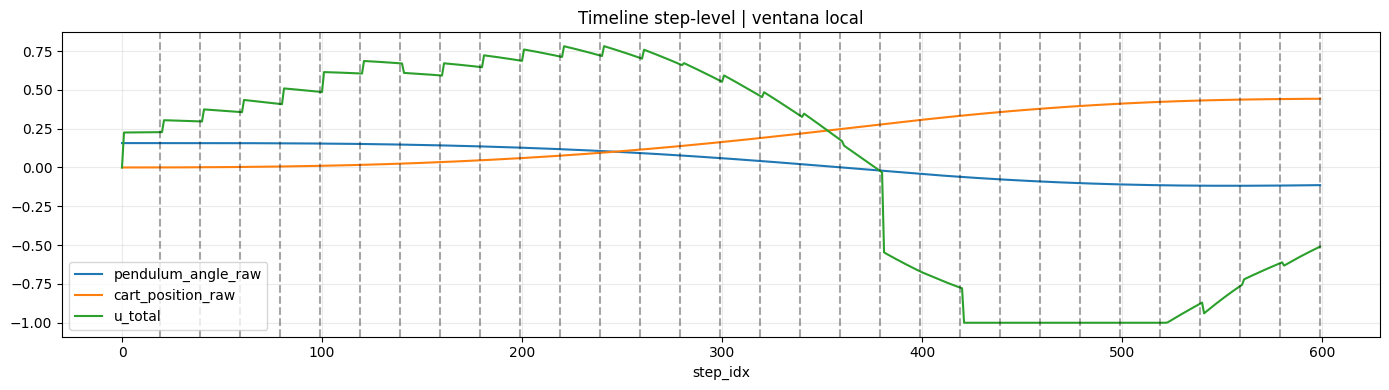

In [183]:
step_plot_cols_existing = [c for c in STEP_PLOT_COLS if c in step_window_df.columns]

fig, ax = plt.subplots(figsize=(14, 4))

for col in step_plot_cols_existing:
    ax.plot(
        step_window_df[STEP_X_COL],
        pd.to_numeric(step_window_df[col], errors='coerce'),
        label=col
    )

boundary_x = step_window_df.loc[step_window_df['is_interval_end_step'], STEP_X_COL].tolist()

for x in boundary_x:
    ax.axvline(x=x, linestyle='--', alpha=0.35, color='black')

ax.set_title('Timeline step-level | ventana local')
ax.set_xlabel(STEP_X_COL)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

- Esta caja deja preparada la base fina para reconstrucción local.
- La salida útil que heredan las siguientes cajas es:
  - `step_timeline_df`
  - `step_window_df`
  - `window_interval_resume_df`
- Desde aquí ya se puede:
  - reconstruir microdinámica dentro de intervalos;
  - observar oscilación local;
  - contrastar acción calculada vs efectiva;
  - bajar a una ventana forense sin perder la referencia interval-level.

## Caja 8 - Sanity check físico: el reward versus el estado real
- Esta caja evalúa si el reward sigue o no el fenómeno físico real del sistema.
- La lectura principal aquí es interval-level.
- La pregunta no es solo cuánto reward hubo, sino si su signo, magnitud y variación son coherentes con el deterioro o mejora física del episodio.

### Subcaja A.1 — Universo físico y universo de reward disponibles

Este bloque muestra qué variables físicas agregadas por intervalo y qué variables de reward están disponibles para esta auditoría.

Su función es dejar explícito el material real con el que se trabajará en esta caja, evitando asumir columnas que no existen en el episodio cargado.

#### Qué representa cada grupo
- **physical_candidates**: variables que resumen el estado físico del sistema por intervalo. En esta caja se usan como aproximación del nivel de deterioro o mejora física.
- **reward_candidates**: variables de reward disponibles a nivel interval-level. Dependiendo de la estructura del episodio, puede haber reward global, principal, extras, coordinación o suma de rewards asignados.

#### Qué se debería observar
- Que existan variables físicas suficientes para representar razonablemente el comportamiento del sistema.
- Que exista al menos `global_interval_reward`, ya que será la referencia principal de esta caja.
- Si faltan variables físicas importantes, la interpretación posterior será más parcial.

In [94]:
physical_candidates = [
    'pendulum_angle_mean_abs',
    'cart_position_mean_abs',
    'pendulum_velocity_mean_abs',
    'cart_velocity_mean_abs',
]

physical_candidates = [c for c in physical_candidates if c in interval_timeline_df.columns]

reward_candidates = [
    'global_interval_reward',
    'principal_reward',
    'extra_total_all',
    'coordination_reward_total',
    'assigned_rewards_total',
]

reward_candidates = [c for c in reward_candidates if c in interval_timeline_df.columns]

physical_reward_universe_df = pd.DataFrame([
    {'group': 'physical_candidates', 'cols': physical_candidates},
    {'group': 'reward_candidates', 'cols': reward_candidates},
])

display(physical_reward_universe_df)

,group,cols
0,physical_candidates,"[pendulum_angle_mean_abs, cart_position_mean_a..."
1,reward_candidates,"[global_interval_reward, extra_total_all, coor..."


### Subcaja A.2 — Correlación inicial entre física agregada y reward global

Este bloque calcula una correlación simple entre cada métrica física agregada y el `global_interval_reward`.

Su propósito no es demostrar causalidad, sino entregar una primera lectura sobre si el reward parece moverse en una dirección coherente con el estado físico del sistema.

#### Qué significa la correlación aquí
- Una correlación **negativa** entre una métrica de error físico y el reward sugiere que, cuando la física empeora, el reward tiende a bajar. Eso es, en principio, coherente.
- Una correlación **positiva** entre una métrica de error físico y el reward sugiere que, cuando la física empeora, el reward también sube. Eso es una señal de alerta.
- Una correlación cercana a **cero** sugiere que el reward no está capturando de forma clara esa dimensión física.

#### Qué se debería buscar
- Si las variables físicas principales muestran el signo esperado frente al reward.
- Si alguna variable física relevante tiene una relación muy débil o contradictoria con el reward.
- Esta tabla no cierra el análisis, pero sí ayuda a identificar qué dimensiones físicas parecen mejor o peor reflejadas por la recompensa.

In [128]:
physical_reward_corr_inventory_df = build_correlation_table(
    interval_timeline_df,
    target_col='global_interval_reward',
    candidate_cols=physical_candidates
)

display(physical_reward_corr_inventory_df)

,target_col,feature_col,corr,abs_corr
0,global_interval_reward,pendulum_angle_mean_abs,-0.936323,0.936323
1,global_interval_reward,pendulum_velocity_mean_abs,-0.624050,0.624050
2,global_interval_reward,cart_velocity_mean_abs,-0.581564,0.581564
3,global_interval_reward,cart_position_mean_abs,-0.204170,0.204170


### Subcaja B — Configuración analítica del sanity check físico

Este bloque define qué variables físicas se usarán para construir el indicador agregado de deterioro físico, cuál reward será auditado y qué criterios se usarán para clasificar los intervalos como coherentes o sospechosos.

#### Significado de los parámetros
- **PHYSICAL_COLS**: columnas físicas que se integrarán en el score de deterioro físico del intervalo. Deben representar variables que, cuando aumentan en magnitud, indiquen peor estado físico.
- **REWARD_COL**: reward que se quiere auditar. Normalmente será `global_interval_reward`.
- **BAD_PHYSICS_THRESHOLD**: umbral a partir del cual la física se considerará suficientemente mala dentro de la escala normalizada.
- **GOOD_REWARD_THRESHOLD**: umbral a partir del cual el reward se considerará suficientemente bueno dentro de la escala normalizada.
- **TOP_N_PHYSICAL_ANOMALIES**: cantidad máxima de intervalos anómalos que se mostrarán como candidatos prioritarios.
- **PHYSICAL_TIMELINE_COLS**: columnas que se usarán en la vista tabular final de esta caja.

#### Qué criterio hay detrás
La idea no es trabajar con escalas crudas, porque las variables físicas y el reward viven en magnitudes diferentes. Por eso aquí se prepara una comparación en escala normalizada, donde luego se podrá observar si el reward parece demasiado bueno o demasiado malo para la física realmente observada.

#### Qué se debería definir correctamente
- Deben incluirse variables físicas que realmente representen deterioro o estabilidad.
- No conviene mezclar aquí variables que no tengan lectura física directa.
- Los umbrales no son leyes universales; son criterios prácticos para separar zonas coherentes y zonas sospechosas.

In [139]:
# --- CONFIGURACIÓN CELDA ---
PHYSICAL_COLS = [
    'pendulum_angle_mean_abs',
    'cart_position_mean_abs',
    'pendulum_velocity_mean_abs',
    'cart_velocity_mean_abs',
]

PHYSICAL_COLS = [c for c in PHYSICAL_COLS if c in interval_timeline_df.columns]

REWARD_COL = 'global_interval_reward'

BAD_PHYSICS_THRESHOLD = 0.55
GOOD_REWARD_THRESHOLD = 0.55

TOP_N_PHYSICAL_ANOMALIES = 12

PHYSICAL_TIMELINE_COLS = PHYSICAL_COLS + [REWARD_COL]
PHYSICAL_TIMELINE_COLS = [c for c in PHYSICAL_TIMELINE_COLS if c in interval_timeline_df.columns]

### Subcaja C.1 — Construcción del score físico, score de reward y zonas de coherencia

Este bloque construye la base analítica principal de la caja.

Aquí se generan tres elementos centrales:

1. **physics_badness_score**  
   Resume, en una sola escala, qué tan mala fue la física del intervalo según las variables seleccionadas.

2. **reward_goodness_score**  
   Lleva el reward a una escala comparable para observar si luce bueno o malo respecto al resto del episodio.

3. **reward_alignment_gap**  
   Mide la diferencia entre el reward observado y el reward que sería razonable esperar dado el nivel de deterioro físico.

#### Qué significa cada variable nueva
- **physics_badness_score**: valor normalizado entre peor y mejor física relativa dentro del episodio.
- **reward_goodness_score**: valor normalizado del reward, donde un valor mayor representa un reward relativamente mejor.
- **expected_reward_goodness_from_physics**: reward esperado bajo una lógica mínima de coherencia física.
- **reward_alignment_gap**: diferencia firmada entre reward observado y reward esperable.
- **reward_alignment_abs_gap**: magnitud de la desalineación, sin importar el signo.
- **physical_reward_zone**: clasificación lógica del intervalo según combinación de física y reward.

#### Significado de las zonas
- **reward_too_good_for_physics**: la física se ve mala, pero el reward luce bueno.
- **reward_too_bad_for_physics**: la física se ve razonablemente buena, pero el reward luce malo.
- **coherent_bad**: física mala y reward malo, lo que al menos es consistente.
- **coherent_good**: física buena y reward bueno, lo que también es consistente.

#### Qué se debería buscar
- Si aparecen muchos intervalos en zonas desalineadas, el reward podría no estar representando bien el estado físico.
- Si predominan zonas coherentes, hay una señal inicial de alineación razonable.
- Esta clasificación no explica todavía la causa de la desalineación, pero sí identifica dónde vale la pena profundizar.

In [144]:
physical_reward_audit_df = interval_timeline_df.copy()

physical_reward_audit_df['physics_badness_score'] = build_rowwise_minmax_mean(
    physical_reward_audit_df,
    PHYSICAL_COLS
)

physical_reward_audit_df['reward_goodness_score'] = minmax_01(
    pd.to_numeric(physical_reward_audit_df[REWARD_COL], errors='coerce')
)

physical_reward_audit_df['expected_reward_goodness_from_physics'] = (
    1.0 - physical_reward_audit_df['physics_badness_score']
)

physical_reward_audit_df['reward_alignment_gap'] = (
    physical_reward_audit_df['reward_goodness_score'] -
    physical_reward_audit_df['expected_reward_goodness_from_physics']
)

physical_reward_audit_df['reward_alignment_abs_gap'] = (
    physical_reward_audit_df['reward_alignment_gap'].abs()
)

def classify_physical_reward_zone(row):
    physics_bad = row['physics_badness_score'] >= BAD_PHYSICS_THRESHOLD
    reward_good = row['reward_goodness_score'] >= GOOD_REWARD_THRESHOLD

    if physics_bad and reward_good:
        return 'reward_too_good_for_physics'

    if (not physics_bad) and (not reward_good):
        return 'reward_too_bad_for_physics'

    if physics_bad and (not reward_good):
        return 'coherent_bad'

    return 'coherent_good'


physical_reward_audit_df['physical_reward_zone'] = physical_reward_audit_df.apply(
    classify_physical_reward_zone,
    axis=1
)

### Subcaja C.2 — Resumen global por tipo de zona física-reward

Este bloque resume cuántos intervalos caen en cada tipo de zona y cómo se comportan, en promedio, sus scores de física, reward y desalineación.

#### Qué representa
- **n_intervals**: cantidad de intervalos clasificados en cada zona.
- **physics_badness_score_mean**: severidad física promedio dentro de la zona.
- **reward_goodness_score_mean**: calidad promedio del reward dentro de la zona.
- **reward_alignment_abs_gap_mean**: magnitud promedio de desalineación.

#### Qué se debería buscar
- Si predominan las zonas coherentes o las zonas problemáticas.
- Si la desalineación media es alta en las zonas sospechosas.
- Si hay muy pocos casos anómalos, el problema podría estar concentrado.
- Si hay muchos casos anómalos, la desalineación podría ser estructural y no anecdótica.

In [141]:
physical_reward_summary_df = (
    physical_reward_audit_df
    .groupby('physical_reward_zone')
    .agg(
        n_intervals=('interval_id', 'count'),
        physics_badness_score_mean=('physics_badness_score', 'mean'),
        reward_goodness_score_mean=('reward_goodness_score', 'mean'),
        reward_alignment_abs_gap_mean=('reward_alignment_abs_gap', 'mean'),
    )
    .reset_index()
    .sort_values('n_intervals', ascending=False)
)

display(physical_reward_summary_df)

,physical_reward_zone,n_intervals,physics_badness_score_mean,reward_goodness_score_mean,reward_alignment_abs_gap_mean
1,coherent_good,161,0.160510,0.905261,0.066207
2,reward_too_bad_for_physics,28,0.425932,0.162911,0.411156
0,coherent_bad,13,0.641863,0.244559,0.122868


### Subcaja C.3 — Selección de intervalos candidatos para análisis fino

Este bloque extrae los intervalos más problemáticos de la caja, priorizando aquellos donde la diferencia entre física observada y reward asignado es más grande.

#### Qué representa
- Se filtran solamente los intervalos en zonas anómalas.
- Luego se ordenan por la magnitud absoluta de la desalineación.
- El resultado es una lista corta de intervalos candidatos para estudiar más adelante en detalle.

#### Qué se debería buscar
- Qué intervalos muestran las contradicciones más fuertes.
- Si los casos anómalos se concentran en una parte del episodio o aparecen dispersos.
- Esta salida es especialmente importante porque deja una lista concreta de intervalos para usar en cajas posteriores, como la reconstrucción local o la auditoría del reward.

In [145]:
physical_reward_candidate_intervals_df = (
    physical_reward_audit_df.loc[
        physical_reward_audit_df['physical_reward_zone'].isin([
            'reward_too_good_for_physics',
            'reward_too_bad_for_physics',
        ]),
        [
            'interval_id',
            'interval_t_start_sec',
            'interval_t_end_sec',
            'physics_badness_score',
            'reward_goodness_score',
            'reward_alignment_gap',
            'reward_alignment_abs_gap',
            'physical_reward_zone',
            REWARD_COL,
        ] + PHYSICAL_COLS
    ]
    .sort_values('reward_alignment_abs_gap', ascending=False)
    .head(TOP_N_PHYSICAL_ANOMALIES)
    .reset_index(drop=True)
)

display(physical_reward_candidate_intervals_df)

interval_ids_physical_anomaly_candidates = physical_reward_candidate_intervals_df['interval_id'].tolist()

,interval_id,interval_t_start_sec,interval_t_end_sec,physics_badness_score,reward_goodness_score,reward_alignment_gap,reward_alignment_abs_gap,physical_reward_zone,global_interval_reward,pendulum_angle_mean_abs,cart_position_mean_abs,pendulum_velocity_mean_abs,cart_velocity_mean_abs
0,0,0.00,0.019,0.250104,0.013145,-0.736751,0.736751,reward_too_bad_for_physics,-0.123355,0.157004,0.000092,0.000524,0.014223
1,1,0.02,0.039,0.257348,0.006814,-0.735838,0.735838,reward_too_bad_for_physics,-0.124123,0.156987,0.000715,0.004261,0.049974
2,2,0.04,0.059,0.269330,0.001796,-0.728874,0.728874,reward_too_bad_for_physics,-0.124731,0.156766,0.002165,0.019700,0.096798
3,3,0.06,0.079,0.285151,0.000406,-0.714443,0.714443,reward_too_bad_for_physics,-0.124900,0.156135,0.004651,0.044918,0.153284
4,4,0.08,0.099,0.304869,0.000455,-0.694676,0.694676,reward_too_bad_for_physics,-0.124894,0.154901,0.008365,0.080524,0.220098
5,5,0.10,0.119,0.330054,0.000000,-0.669946,0.669946,reward_too_bad_for_physics,-0.124949,0.152815,0.013553,0.131113,0.301735
6,6,0.12,0.139,0.360480,0.011135,-0.628385,0.628385,reward_too_bad_for_physics,-0.123599,0.149552,0.020535,0.197044,0.398340
7,7,0.14,0.159,0.390019,0.051844,-0.558137,0.558137,reward_too_bad_for_physics,-0.118662,0.144926,0.029488,0.263757,0.494906
8,8,0.16,0.179,0.418119,0.081127,-0.500754,0.500754,reward_too_bad_for_physics,-0.115112,0.139008,0.040319,0.329843,0.589728
9,28,0.56,0.579,0.477943,0.031685,-0.490372,0.490372,reward_too_bad_for_physics,-0.121107,0.117249,0.439124,0.068214,0.176057


### Subcaja C.4 — Visualización de la relación física-reward

Este bloque muestra dos vistas complementarias:

1. **Scatter física vs reward**  
   Permite ver si el reward crece o cae de forma coherente respecto al deterioro físico.

2. **Evolución temporal normalizada por intervalo**  
   Permite observar si la trayectoria del score físico y del score de reward se acompañan o se separan a lo largo del episodio.

#### Cómo interpretar el scatter
- Intervalos hacia la derecha indican física relativamente peor.
- Intervalos hacia arriba indican reward relativamente mejor.
- Un punto en la zona de física mala y reward alto es una señal de alerta.
- Un punto en la zona de física buena y reward bajo también es una señal de alerta.

#### Cómo interpretar la serie temporal
- Si ambos perfiles se comportan en sentido opuesto de forma estable, hay coherencia.
- Si se separan bruscamente en algunos tramos, esos intervalos merecen revisión.
- Las anotaciones sobre algunos puntos ayudan a localizar intervalos concretos para la siguiente fase del análisis.

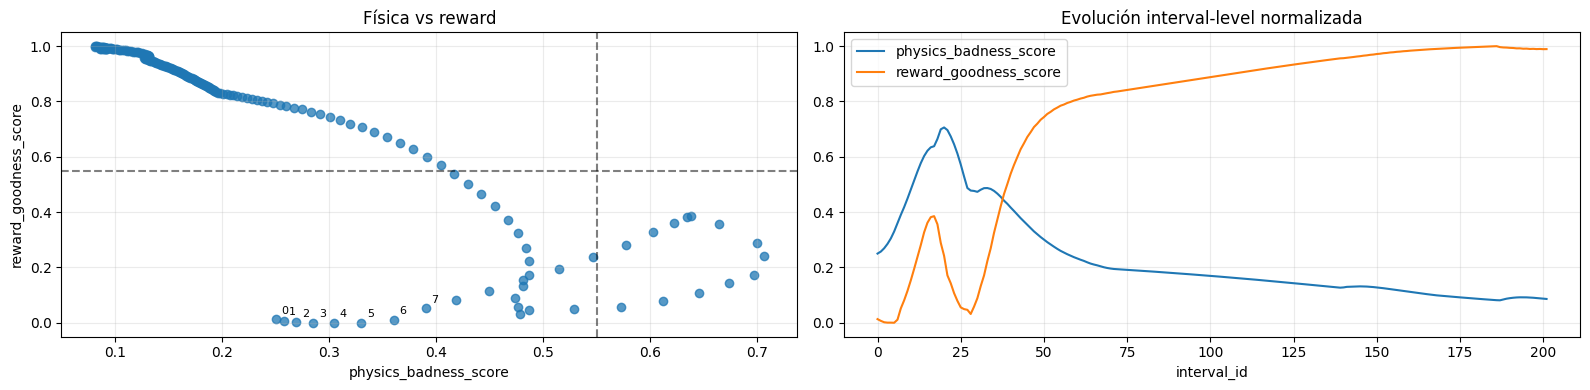

In [143]:
physical_reward_plot_df = physical_reward_audit_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].scatter(
    physical_reward_plot_df['physics_badness_score'],
    physical_reward_plot_df['reward_goodness_score'],
    alpha=0.75
)

axes[0].axvline(BAD_PHYSICS_THRESHOLD, linestyle='--', color='black', alpha=0.5)
axes[0].axhline(GOOD_REWARD_THRESHOLD, linestyle='--', color='black', alpha=0.5)
axes[0].set_title('Física vs reward')
axes[0].set_xlabel('physics_badness_score')
axes[0].set_ylabel('reward_goodness_score')

for _, row in physical_reward_candidate_intervals_df.head(8).iterrows():
    axes[0].annotate(
        str(int(row['interval_id'])),
        (row['physics_badness_score'], row['reward_goodness_score']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

axes[1].plot(
    physical_reward_plot_df['interval_id'],
    physical_reward_plot_df['physics_badness_score'],
    label='physics_badness_score'
)
axes[1].plot(
    physical_reward_plot_df['interval_id'],
    physical_reward_plot_df['reward_goodness_score'],
    label='reward_goodness_score'
)
axes[1].set_title('Evolución interval-level normalizada')
axes[1].set_xlabel('interval_id')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

La lectura es:

- arriba izquierda: el reward luce alto cuando la física está mal;
- abajo derecha: el reward luce bajo cuando la física está relativamente bien;
- abajo izquierda: al menos hay coherencia en el castigo;
- arriba derecha no debiera existir si el score está bien planteado; en la práctica, cuando aparece, suele indicar una compensación extraña del reward global.

```
reward_goodness ↑
1 |  reward demasiado bueno   |  coherente bueno
  |  para física mala         |
--+---------------------------+-----------------------------> physics_badness
0 |  coherente malo           |  reward demasiado malo
  |                           |  para física buena

```

### Subcaja C.5 — Tabla final de auditoría física por intervalo

Este bloque deja visible la tabla final con los principales resultados de la caja para cada intervalo.

#### Qué contiene
- Identidad temporal del intervalo.
- Score físico.
- Score de reward.
- Gap de alineación.
- Zona lógica asignada.
- Variables físicas usadas en la evaluación.

#### Qué se debería buscar
- Intervalos con gap alto.
- Intervalos que caen en zonas anómalas.
- Diferencias claras entre intervalos coherentes e incoherentes.
- Esta tabla deja lista la información para enlazar la lectura física con la auditoría del controlador y con la selección de ventanas forenses posteriores.

In [107]:
physical_reward_timeline_view_cols = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'physics_badness_score',
    'reward_goodness_score',
    'reward_alignment_gap',
    'reward_alignment_abs_gap',
    'physical_reward_zone',
    REWARD_COL,
] + PHYSICAL_COLS

physical_reward_timeline_view_cols = [
    c for c in physical_reward_timeline_view_cols
    if c in physical_reward_audit_df.columns
]

display(physical_reward_audit_df[physical_reward_timeline_view_cols])

,interval_id,interval_t_start_sec,interval_t_end_sec,physics_badness_score,reward_goodness_score,reward_alignment_gap,reward_alignment_abs_gap,physical_reward_zone,global_interval_reward,pendulum_angle_mean_abs,cart_position_mean_abs,pendulum_velocity_mean_abs,cart_velocity_mean_abs
0,0,0.00,0.019,0.250104,0.013145,-0.736751,0.736751,coherent_bad,-0.123355,0.157004,0.000092,0.000524,0.014223
1,1,0.02,0.039,0.257348,0.006814,-0.735838,0.735838,coherent_bad,-0.124123,0.156987,0.000715,0.004261,0.049974
2,2,0.04,0.059,0.269330,0.001796,-0.728874,0.728874,coherent_bad,-0.124731,0.156766,0.002165,0.019700,0.096798
3,3,0.06,0.079,0.285151,0.000406,-0.714443,0.714443,coherent_bad,-0.124900,0.156135,0.004651,0.044918,0.153284
4,4,0.08,0.099,0.304869,0.000455,-0.694676,0.694676,coherent_bad,-0.124894,0.154901,0.008365,0.080524,0.220098
...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,197,3.94,3.959,0.090402,0.990337,0.080740,0.080740,coherent_good,-0.004862,0.012482,0.103246,0.028430,0.049083
198,198,3.96,3.979,0.089451,0.989427,0.078877,0.078877,coherent_good,-0.004973,0.013032,0.102308,0.026254,0.044403
199,199,3.98,3.999,0.088331,0.989873,0.078204,0.078204,coherent_good,-0.004919,0.013530,0.101473,0.023765,0.039306
200,200,4.00,4.019,0.087152,0.989130,0.076283,0.076283,coherent_good,-0.005009,0.013981,0.100738,0.021210,0.034051


## Caja 9 - Sanity Check del controlador
- Esta caja evalúa si el reward interpreta correctamente el trabajo del control.
- El foco no es solo la magnitud de la acción, sino también:
  - acción calculada vs acción efectiva;
  - saturación global;
  - variabilidad del control;
  - relación entre esfuerzo y corrección.
- La lectura principal sigue siendo interval-level, dejando candidatos para bajar luego a step-level.

### Subcaja A.1 — Universo de variables del controlador disponibles

Este bloque muestra qué variables del control están disponibles a nivel interval-level para auditar cómo el reward interpreta el trabajo del controlador.

#### Qué representa cada grupo
- **controller_global_candidates**: variables globales del control, como magnitud total, variación total o proporción de saturación.
- **controller_loop_candidates**: variables por lazo, como error medio, acción media, acción efectiva y ganancias promedio.

#### Qué se debería observar
- Si están disponibles las variables necesarias para representar esfuerzo, acción efectiva y saturación.
- Si existen columnas por lazo que permitan distinguir entre comportamiento del controlador y comportamiento físico.
- Esta caja no busca todavía concluir nada, sino dejar claro con qué señales del control se podrá trabajar.

In [146]:
controller_global_candidates = [
    c for c in [
        'u_total_mean_abs',
        'u_total_raw_mean_abs',
        'u_total_saturated_mean_abs',
        #'delta_u_total_mean_abs',
        'sat_prp_interval',
    ]
    if c in interval_timeline_df.columns
]

controller_loop_candidates = []
for var_obj in available_control_loop_var_objs:
    controller_loop_candidates.extend([
        f'error_{var_obj}_mean_abs',
        f'control_action_{var_obj}_mean_abs',
        f'u_eff_{var_obj}_mean_abs',
        #f'delta_u_eff_{var_obj}_mean_abs',
        f'kp_{var_obj}_mean',
        f'ki_{var_obj}_mean',
        f'kd_{var_obj}_mean',
    ])

controller_loop_candidates = [c for c in controller_loop_candidates if c in interval_timeline_df.columns]

controller_universe_df = pd.DataFrame([
    {'group': 'controller_global_candidates', 'cols': controller_global_candidates},
    {'group': 'controller_loop_candidates', 'cols': controller_loop_candidates},
])

display(controller_universe_df)

,group,cols
0,controller_global_candidates,"[u_total_mean_abs, u_total_raw_mean_abs, u_tot..."
1,controller_loop_candidates,"[error_cart_position_mean_abs, control_action_..."


### Subcaja A.2 — Correlación inicial entre variables del control y reward global

Este bloque calcula una correlación simple entre variables del controlador y el `global_interval_reward`.

#### Qué busca responder
- Si el reward parece sensible a la magnitud del control.
- Si el reward parece reaccionar a la saturación.
- Si el reward parece distinguir entre error, esfuerzo y acción efectiva.

#### Cómo interpretar la tabla
- Una correlación **negativa** entre una variable de estrés del control y el reward sugiere que, cuando el control se vuelve más agresivo o más problemático, el reward baja. Eso es razonable.
- Una correlación **positiva** entre saturación o esfuerzo excesivo y reward puede ser una señal de lectura deficiente del control.
- Una correlación muy baja puede indicar que el reward apenas está viendo esa dimensión del comportamiento del controlador.

#### Qué se debería buscar
- Qué variables del control parecen más relacionadas con el reward.
- Si la saturación, el esfuerzo o la acción efectiva tienen el signo esperado.
- Esta tabla sirve como lectura inicial, pero todavía no resuelve si el reward está siendo justo o injusto con el controlador.

In [147]:
controller_reward_corr_inventory_df = build_correlation_table(
    interval_timeline_df,
    target_col='global_interval_reward',
    candidate_cols=controller_global_candidates + controller_loop_candidates
)

display(controller_reward_corr_inventory_df.head(20))

,target_col,feature_col,corr,abs_corr
0,global_interval_reward,error_pendulum_angle_mean_abs,-0.936476,0.936476
1,global_interval_reward,u_total_mean_abs,-0.847908,0.847908
2,global_interval_reward,kp_cart_position_mean,-0.806841,0.806841
3,global_interval_reward,u_total_raw_mean_abs,-0.800084,0.800084
4,global_interval_reward,u_eff_pendulum_angle_mean_abs,-0.786061,0.786061
5,global_interval_reward,control_action_pendulum_angle_mean_abs,-0.757190,0.757190
6,global_interval_reward,kp_pendulum_angle_mean,0.647390,0.647390
7,global_interval_reward,ki_pendulum_angle_mean,0.553518,0.553518
8,global_interval_reward,kd_pendulum_angle_mean,0.549501,0.549501
9,global_interval_reward,sat_prp_interval,-0.347218,0.347218


### Subcaja B — Configuración analítica de la auditoría del controlador

Este bloque define qué lazos se auditarán, qué variables se usarán para construir el score de estrés del control y qué criterios se usarán para clasificar los intervalos.

#### Significado de los parámetros
- **CONTROLLER_VAR_OBJS**: lazos de control disponibles que participarán en el análisis.
- **CONTROLLER_STRESS_COLS**: columnas que se integrarán en el score de estrés del controlador.
- **REWARD_COL**: reward que será contrastado contra el comportamiento del control.
- **HIGH_CONTROLLER_STRESS_THRESHOLD**: umbral a partir del cual el intervalo se considerará exigente o estresante para el control.
- **GOOD_REWARD_THRESHOLD**: umbral a partir del cual el reward se considerará relativamente bueno.
- **TOP_N_CONTROLLER_ANOMALIES**: cantidad máxima de intervalos sospechosos que se priorizarán.

#### Qué significa “estrés del control”
En esta caja, el estrés del control no representa una variable física, sino una medida compuesta del costo o exigencia del trabajo de control. Puede incluir:
- mucha magnitud de acción;
- mucha variabilidad;
- mucha saturación;
- diferencias entre la acción calculada y la acción efectiva.

#### Qué se debería definir correctamente
- El stress score debe construirse con variables que realmente representen esfuerzo, limitación o agresividad del control.
- No conviene meter aquí variables puramente físicas, porque esta caja quiere auditar la lectura del controlador y no del sistema físico en sí.

In [156]:
# --- CONFIGURACIÓN CELDA ---
CONTROLLER_VAR_OBJS = available_control_loop_var_objs

CONTROLLER_STRESS_COLS = [
    'u_total_mean_abs',
    #'delta_u_total_mean_abs',
    'sat_prp_interval',
]

for var_obj in CONTROLLER_VAR_OBJS:
    CONTROLLER_STRESS_COLS.extend([
        f'control_action_{var_obj}_mean_abs',
        #f'delta_u_eff_{var_obj}_mean_abs',
    ])

CONTROLLER_STRESS_COLS = [c for c in CONTROLLER_STRESS_COLS if c in interval_timeline_df.columns]

REWARD_COL = 'global_interval_reward'

HIGH_CONTROLLER_STRESS_THRESHOLD = 0.55
GOOD_REWARD_THRESHOLD = 0.55

TOP_N_CONTROLLER_ANOMALIES = 12

### Subcaja C.1 — Construcción de indicadores del controlador y zonas de coherencia reward-control

Este bloque construye la base analítica principal de la caja.

Aquí se generan indicadores que permiten comparar lo que el controlador intentó hacer, lo que realmente logró aplicar y cómo fue premiado o castigado por el reward.

#### Qué significa cada indicador nuevo
- **effective_action_ratio_<var_obj>**: relación entre acción efectiva y acción calculada.  
  Un valor bajo puede indicar pérdida de efectividad por saturación o por mezcla con otros lazos.
  
- **effort_per_error_<var_obj>**: esfuerzo medio por unidad de error.  
  Permite observar cuánto control se está usando para corregir una cierta magnitud de error.

- **effective_action_retention_mean**: promedio de retención de acción efectiva entre los lazos disponibles.  
  Resume cuánto de la acción calculada logra mantenerse realmente aplicada.

- **controller_stress_score**: score agregado del nivel de exigencia o agresividad del control en el intervalo.  
  Su objetivo es resumir esfuerzo, variación y saturación en una sola escala comparable.

- **reward_goodness_score**: reward global llevado a escala normalizada.

- **expected_reward_goodness_from_controller_stress**: reward esperable bajo una lógica mínima donde intervalos con mayor estrés del control deberían tender a recibir peor reward.

- **controller_reward_gap**: diferencia firmada entre reward observado y reward esperable dado el estrés del control.

- **controller_reward_abs_gap**: magnitud de la desalineación reward-control.

#### Significado de las zonas
- **reward_too_lenient_to_control_stress**: el control se ve exigido o problemático, pero el reward sigue siendo relativamente bueno.
- **reward_too_harsh_to_controller**: el control no se ve tan exigido, pero el reward sigue siendo relativamente malo.
- **coherent_penalty**: alto estrés del control con reward bajo, lo que al menos es consistente.
- **coherent_favorable**: bajo estrés del control con reward relativamente favorable.

#### Qué se debería buscar
- Si el reward parece castigar o no castigar suficientemente la saturación, la variabilidad o el esfuerzo.
- Si la acción efectiva se separa mucho de la acción calculada.
- Si existen intervalos donde el control se comporta de manera exigente, pero el reward igual luce demasiado bueno.

In [157]:
controller_audit_df = interval_timeline_df.copy()

for var_obj in CONTROLLER_VAR_OBJS:
    control_col = f'control_action_{var_obj}_mean_abs'
    eff_col = f'u_eff_{var_obj}_mean_abs'
    err_col = f'error_{var_obj}_mean_abs'

    if control_col in controller_audit_df.columns and eff_col in controller_audit_df.columns:
        controller_audit_df[f'effective_action_ratio_{var_obj}'] = safe_ratio_series(
            controller_audit_df[eff_col],
            controller_audit_df[control_col]
        )

    if control_col in controller_audit_df.columns and err_col in controller_audit_df.columns:
        controller_audit_df[f'effort_per_error_{var_obj}'] = safe_ratio_series(
            controller_audit_df[control_col],
            controller_audit_df[err_col]
        )

effective_ratio_cols = [
    c for c in controller_audit_df.columns
    if c.startswith('effective_action_ratio_')
]

controller_audit_df['effective_action_retention_mean'] = controller_audit_df[
    effective_ratio_cols
].apply(pd.to_numeric, errors='coerce').mean(axis=1)

controller_audit_df['controller_stress_score'] = build_rowwise_minmax_mean(
    controller_audit_df,
    CONTROLLER_STRESS_COLS
)

controller_audit_df['reward_goodness_score'] = minmax_01(
    pd.to_numeric(controller_audit_df[REWARD_COL], errors='coerce')
)

controller_audit_df['expected_reward_goodness_from_controller_stress'] = (
    1.0 - controller_audit_df['controller_stress_score']
)

controller_audit_df['controller_reward_gap'] = (
    controller_audit_df['reward_goodness_score'] -
    controller_audit_df['expected_reward_goodness_from_controller_stress']
)

controller_audit_df['controller_reward_abs_gap'] = (
    controller_audit_df['controller_reward_gap'].abs()
)

def classify_controller_reward_zone(row):
    high_stress = row['controller_stress_score'] >= HIGH_CONTROLLER_STRESS_THRESHOLD
    good_reward = row['reward_goodness_score'] >= GOOD_REWARD_THRESHOLD

    if high_stress and good_reward:
        return 'reward_too_lenient_to_control_stress'

    if (not high_stress) and (not good_reward):
        return 'reward_too_harsh_to_controller'

    if high_stress and (not good_reward):
        return 'coherent_penalty'

    return 'coherent_favorable'


controller_audit_df['controller_reward_zone'] = controller_audit_df.apply(
    classify_controller_reward_zone,
    axis=1
)

### Subcaja C.2 — Resumen por lazo de control

Este bloque resume el comportamiento medio de cada lazo respecto a error, acción, acción efectiva y relación con el reward.

#### Qué representa cada fila
Cada fila corresponde a un lazo de control y resume cómo se comportó a lo largo del episodio.

#### Qué significan algunos campos importantes
- **error_mean_abs_mean**: magnitud media del error del lazo.
- **control_action_mean_abs_mean**: magnitud media de la acción calculada.
- **u_eff_mean_abs_mean**: magnitud media de la acción efectivamente aplicada.
- **delta_u_eff_mean_abs_mean**: variabilidad media de la acción efectiva.
- **effective_action_ratio_mean**: proporción media entre acción aplicada y acción calculada.
- **effort_per_error_mean**: esfuerzo medio requerido para corregir error.
- **corr_reward_vs_error**: relación lineal entre error del lazo y reward.
- **corr_reward_vs_control_action**: relación lineal entre esfuerzo del lazo y reward.
- **corr_reward_vs_u_eff**: relación lineal entre acción efectiva y reward.

#### Qué se debería buscar
- Si hay lazos con mucha pérdida entre acción calculada y acción efectiva.
- Si un lazo requiere mucho esfuerzo por unidad de error.
- Si el reward parece más sensible a un lazo que a otro.
- Esta tabla ayuda a identificar si la lectura del reward está balanceada entre lazos o si parece sesgada.

In [158]:
controller_loop_summary_rows = []

for var_obj in CONTROLLER_VAR_OBJS:
    row = {
        'var_obj': var_obj,
        'error_mean_abs_mean': controller_audit_df[f'error_{var_obj}_mean_abs'].mean() if f'error_{var_obj}_mean_abs' in controller_audit_df.columns else np.nan,
        'control_action_mean_abs_mean': controller_audit_df[f'control_action_{var_obj}_mean_abs'].mean() if f'control_action_{var_obj}_mean_abs' in controller_audit_df.columns else np.nan,
        'u_eff_mean_abs_mean': controller_audit_df[f'u_eff_{var_obj}_mean_abs'].mean() if f'u_eff_{var_obj}_mean_abs' in controller_audit_df.columns else np.nan,
        'delta_u_eff_mean_abs_mean': controller_audit_df[f'delta_u_eff_{var_obj}_mean_abs'].mean() if f'delta_u_eff_{var_obj}_mean_abs' in controller_audit_df.columns else np.nan,
        'effective_action_ratio_mean': controller_audit_df[f'effective_action_ratio_{var_obj}'].mean() if f'effective_action_ratio_{var_obj}' in controller_audit_df.columns else np.nan,
        'effort_per_error_mean': controller_audit_df[f'effort_per_error_{var_obj}'].mean() if f'effort_per_error_{var_obj}' in controller_audit_df.columns else np.nan,
        'corr_reward_vs_error': pd.to_numeric(controller_audit_df[REWARD_COL], errors='coerce').corr(pd.to_numeric(controller_audit_df[f'error_{var_obj}_mean_abs'], errors='coerce')) if f'error_{var_obj}_mean_abs' in controller_audit_df.columns else np.nan,
        'corr_reward_vs_control_action': pd.to_numeric(controller_audit_df[REWARD_COL], errors='coerce').corr(pd.to_numeric(controller_audit_df[f'control_action_{var_obj}_mean_abs'], errors='coerce')) if f'control_action_{var_obj}_mean_abs' in controller_audit_df.columns else np.nan,
        'corr_reward_vs_u_eff': pd.to_numeric(controller_audit_df[REWARD_COL], errors='coerce').corr(pd.to_numeric(controller_audit_df[f'u_eff_{var_obj}_mean_abs'], errors='coerce')) if f'u_eff_{var_obj}_mean_abs' in controller_audit_df.columns else np.nan,
    }

    controller_loop_summary_rows.append(row)

controller_loop_summary_df = pd.DataFrame(controller_loop_summary_rows)
display(controller_loop_summary_df)

,var_obj,error_mean_abs_mean,control_action_mean_abs_mean,u_eff_mean_abs_mean,delta_u_eff_mean_abs_mean,effective_action_ratio_mean,effort_per_error_mean,corr_reward_vs_error,corr_reward_vs_control_action,corr_reward_vs_u_eff
0,cart_position,0.047347,0.052249,0.051379,0.000221,0.993486,2.705674,-0.202203,-0.086392,-0.053571
1,pendulum_angle,0.024356,0.157366,0.148879,0.001941,0.993435,11.531300,-0.936476,-0.757190,-0.786061


### Subcaja C.3 — Resumen global por tipo de zona reward-control

Este bloque resume cuántos intervalos caen en cada tipo de zona y cómo se comportan, en promedio, sus scores de estrés, reward y retención de acción efectiva.

#### Qué representa
- **n_intervals**: cantidad de intervalos por tipo de zona.
- **controller_stress_score_mean**: nivel medio de estrés del control en esa zona.
- **reward_goodness_score_mean**: reward medio normalizado en esa zona.
- **effective_action_retention_mean**: retención media de acción efectiva.
- **controller_reward_abs_gap_mean**: magnitud media de desalineación entre control y reward.

#### Qué se debería buscar
- Si predominan zonas coherentes o anómalas.
- Si las zonas anómalas muestran baja retención de acción efectiva o estrés elevado.
- Si el reward parece indulgente o excesivamente severo frente al controlador.

In [159]:
controller_reward_summary_df = (
    controller_audit_df
    .groupby('controller_reward_zone')
    .agg(
        n_intervals=('interval_id', 'count'),
        controller_stress_score_mean=('controller_stress_score', 'mean'),
        reward_goodness_score_mean=('reward_goodness_score', 'mean'),
        effective_action_retention_mean=('effective_action_retention_mean', 'mean'),
        controller_reward_abs_gap_mean=('controller_reward_abs_gap', 'mean'),
    )
    .reset_index()
    .sort_values('n_intervals', ascending=False)
)

display(controller_reward_summary_df)

,controller_reward_zone,n_intervals,controller_stress_score_mean,reward_goodness_score_mean,effective_action_retention_mean,controller_reward_abs_gap_mean
0,coherent_favorable,161,0.073188,0.905261,1.000000,0.130948
2,reward_too_harsh_to_controller,36,0.285535,0.199578,0.999758,0.514886
1,coherent_penalty,5,0.881779,0.111191,0.737540,0.065309


### Subcaja C.4 — Selección de intervalos candidatos desde la perspectiva del control

Este bloque extrae los intervalos donde la relación entre comportamiento del controlador y reward parece más problemática.

#### Qué representa
- Se filtran solamente las zonas anómalas de la auditoría del controlador.
- Luego se ordenan por magnitud absoluta de desalineación.
- El resultado es una lista corta de intervalos candidatos para inspección posterior.

#### Qué se debería buscar
- Qué intervalos presentan mayor contradicción entre esfuerzo del control y reward recibido.
- Si esos intervalos coinciden o no con los candidatos detectados en la Caja 8.
- Esta salida es muy útil para cruzar la lectura física con la lectura del controlador antes de seguir hacia el puente step → interval.

In [160]:
controller_candidate_intervals_df = (
    controller_audit_df.loc[
        controller_audit_df['controller_reward_zone'].isin([
            'reward_too_lenient_to_control_stress',
            'reward_too_harsh_to_controller',
        ]),
        [
            'interval_id',
            'interval_t_start_sec',
            'interval_t_end_sec',
            'controller_stress_score',
            'reward_goodness_score',
            'controller_reward_gap',
            'controller_reward_abs_gap',
            'effective_action_retention_mean',
            'controller_reward_zone',
            REWARD_COL,
            'sat_prp_interval',
        ] + CONTROLLER_STRESS_COLS
    ]
    .sort_values('controller_reward_abs_gap', ascending=False)
    .head(TOP_N_CONTROLLER_ANOMALIES)
    .reset_index(drop=True)
)

display(controller_candidate_intervals_df)

interval_ids_controller_anomaly_candidates = controller_candidate_intervals_df['interval_id'].tolist()

,interval_id,interval_t_start_sec,interval_t_end_sec,controller_stress_score,reward_goodness_score,controller_reward_gap,controller_reward_abs_gap,effective_action_retention_mean,controller_reward_zone,global_interval_reward,sat_prp_interval,u_total_mean_abs,sat_prp_interval,control_action_cart_position_mean_abs,control_action_pendulum_angle_mean_abs
0,0,0.00,0.019,0.088853,0.013145,-0.898002,0.898002,1.0,reward_too_harsh_to_controller,-0.123355,0.0,0.214992,0.0,0.001220,0.216212
1,1,0.02,0.039,0.128202,0.006814,-0.864984,0.864984,1.0,reward_too_harsh_to_controller,-0.124123,0.0,0.296878,0.0,0.004757,0.301635
2,2,0.04,0.059,0.162506,0.001796,-0.835698,0.835698,1.0,reward_too_harsh_to_controller,-0.124731,0.0,0.362076,0.0,0.009507,0.371583
3,3,0.06,0.079,0.194865,0.000406,-0.804729,0.804729,1.0,reward_too_harsh_to_controller,-0.124900,0.0,0.418540,0.0,0.015344,0.433884
4,4,0.08,0.099,0.236738,0.000455,-0.762807,0.762807,1.0,reward_too_harsh_to_controller,-0.124894,0.0,0.493726,0.0,0.022326,0.516052
5,5,0.10,0.119,0.295605,0.000000,-0.704395,0.704395,1.0,reward_too_harsh_to_controller,-0.124949,0.0,0.603994,0.0,0.030912,0.634906
6,31,0.62,0.639,0.184547,0.132280,-0.683173,0.683173,1.0,reward_too_harsh_to_controller,-0.108909,0.0,0.335972,0.0,0.039231,0.296741
7,30,0.60,0.619,0.244521,0.088750,-0.666729,0.666729,1.0,reward_too_harsh_to_controller,-0.114187,0.0,0.456666,0.0,0.047490,0.409175
8,33,0.66,0.679,0.115141,0.223051,-0.661808,0.661808,1.0,reward_too_harsh_to_controller,-0.097902,0.0,0.194751,0.0,0.030201,0.164551
9,32,0.64,0.659,0.172114,0.170867,-0.657020,0.657020,1.0,reward_too_harsh_to_controller,-0.104230,0.0,0.320388,0.0,0.034289,0.286100


### Subcaja C.5 — Visualización de la relación controlador-reward

Este bloque muestra dos vistas complementarias:

1. **Scatter estrés del control vs reward**  
   Permite ver si el reward cae cuando el control se vuelve más exigente, más variable o más saturado.

2. **Evolución temporal del control**  
   Permite seguir el estrés del controlador, el reward y, si está disponible, la proporción de saturación por intervalo.

#### Cómo interpretar el scatter
- Intervalos a la derecha representan mayor estrés del control.
- Intervalos hacia arriba representan reward relativamente bueno.
- Si aparecen muchos puntos con alto estrés y reward alto, el reward podría estar siendo demasiado indulgente.
- Si aparecen muchos puntos con bajo estrés y reward muy bajo, el reward podría estar castigando de más al controlador.

#### Cómo interpretar la serie temporal
- Si estrés y reward se mueven en sentido opuesto de forma consistente, hay una lectura razonable.
- Si la saturación sube y el reward no cambia, puede haber una falta de sensibilidad a la limitación del actuador.
- Las anotaciones permiten ubicar intervalos candidatos para análisis fino posterior.

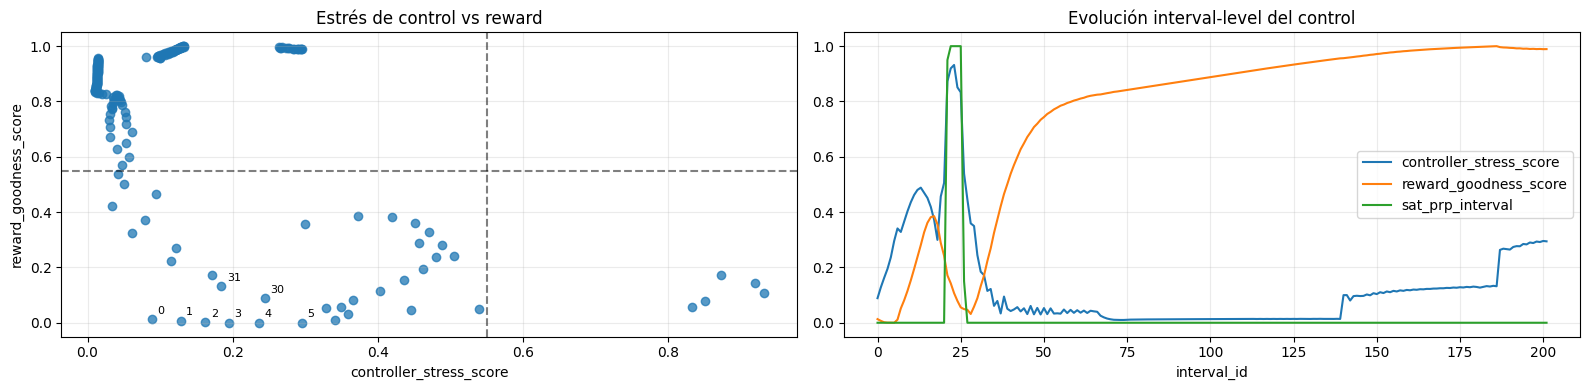

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].scatter(
    controller_audit_df['controller_stress_score'],
    controller_audit_df['reward_goodness_score'],
    alpha=0.75
)

axes[0].axvline(HIGH_CONTROLLER_STRESS_THRESHOLD, linestyle='--', color='black', alpha=0.5)
axes[0].axhline(GOOD_REWARD_THRESHOLD, linestyle='--', color='black', alpha=0.5)
axes[0].set_title('Estrés de control vs reward')
axes[0].set_xlabel('controller_stress_score')
axes[0].set_ylabel('reward_goodness_score')

for _, row in controller_candidate_intervals_df.head(8).iterrows():
    axes[0].annotate(
        str(int(row['interval_id'])),
        (row['controller_stress_score'], row['reward_goodness_score']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

axes[1].plot(
    controller_audit_df['interval_id'],
    controller_audit_df['controller_stress_score'],
    label='controller_stress_score'
)
axes[1].plot(
    controller_audit_df['interval_id'],
    controller_audit_df['reward_goodness_score'],
    label='reward_goodness_score'
)

if 'sat_prp_interval' in controller_audit_df.columns:
    axes[1].plot(
        controller_audit_df['interval_id'],
        pd.to_numeric(controller_audit_df['sat_prp_interval'], errors='coerce'),
        label='sat_prp_interval'
    )

axes[1].set_title('Evolución interval-level del control')
axes[1].set_xlabel('interval_id')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

- Esta caja deja una lectura interval-level del comportamiento del controlador frente al reward.
- La salida útil que heredan las siguientes cajas es:
  - `controller_audit_df`
  - `controller_loop_summary_df`
  - `controller_reward_summary_df`
  - `controller_candidate_intervals_df`
  - `interval_ids_controller_anomaly_candidates`
- Lo importante aquí es distinguir si el reward:
  - premia control realmente correctivo;
  - castiga en exceso el esfuerzo útil;
  - no castiga suficientemente la saturación o la variabilidad.

## Caja 10 - Puente step -> métricas procesadas
- Esta caja reconstruye el paso crítico donde una serie step-level se resume en un único valor interval-level.
- Su foco no está todavía en la fórmula final del reward, sino en el paso anterior:
  - qué serie se toma;
  - con qué método se agrega;
  - qué valor agregado se obtiene;
  - cómo se normaliza a `L_*`.
- Esta es una caja clave, porque una desalineación entre física y reward puede nacer aquí, antes incluso de la composición del reward principal.

### Subcaja A.1 — Configuración real de `MetricProcessing` disponible en la corrida

Este bloque carga la metadata de la corrida y reconstruye los trabajos de procesamiento declarados para cada lazo y cada feature principal.

#### Qué representa cada fila
Cada fila corresponde a una combinación:
- lazo (`var_obj`);
- feature del reward principal (`e`, `edot`, `I`, `u`, `delta_u`);
- señal step-level de origen;
- método de agregación;
- nombre de la columna agregada persistida;
- nombre de la columna normalizada `L_*`.

#### Por qué es importante
La Caja 10 debe auditar el proceso real de agregación, no una versión inventada. Por eso aquí se leen los métodos reales configurados en la corrida.

#### Qué se debería buscar
- Qué señal step-level alimenta a cada feature.
- Qué método se está usando en cada caso.
- Si la elección del método parece razonable para el tipo de señal analizada.

In [165]:
run_metadata = load_run_metadata(RUN_DIR)
metric_jobs_df = build_metric_processing_jobs_df(run_metadata)

display(metric_jobs_df)

,var_obj,feature_key,source_step_col,method,stored_agg_col,stored_L_col,range_min,range_max,output_min,output_max,normalization_enabled
0,pendulum_angle,e,error_pendulum_angle,rms,error_pendulum_angle_rms,L_e_pendulum_angle,-1.0,1.0,0.0,1.0,True
1,pendulum_angle,edot,derivative_error_pendulum_angle,rms,derivative_error_pendulum_angle_rms,L_edot_pendulum_angle,-1.5,1.5,0.0,1.0,True
2,pendulum_angle,I,integral_error_pendulum_angle,rms,integral_error_pendulum_angle_rms,L_I_pendulum_angle,-2.0,2.0,0.0,1.0,True
3,pendulum_angle,u,u_eff_pendulum_angle,rms,u_eff_pendulum_angle_rms,L_u_pendulum_angle,-1.0,1.0,0.0,1.0,True
4,cart_position,e,error_cart_position,rms,error_cart_position_rms,L_e_cart_position,-1.0,1.0,0.0,1.0,True
5,cart_position,edot,derivative_error_cart_position,rms,derivative_error_cart_position_rms,L_edot_cart_position,-0.8,0.8,0.0,1.0,True
6,cart_position,I,integral_error_cart_position,rms,integral_error_cart_position_rms,L_I_cart_position,-2.0,2.0,0.0,1.0,True
7,cart_position,u,u_eff_cart_position,rms,u_eff_cart_position_rms,L_u_cart_position,-1.0,1.0,0.0,1.0,True


### Subcaja A.2 — Resumen estructural por feature y método

Este bloque resume cómo queda distribuido el procesamiento por feature y por método.

#### Qué representa
- Cuántos jobs hay por feature.
- Qué métodos aparecen efectivamente en la corrida.
- Qué lazos participan en la construcción de las métricas procesadas.

#### Qué se debería buscar
- Si una misma familia de señal está siendo agregada siempre del mismo modo.
- Si hay métodos distintos entre lazos o features.
- Si alguna decisión metodológica podría ser especialmente sensible, por ejemplo `keep_last`, `mean_squared` o `abs`.

In [166]:
metric_jobs_summary_df = (
    metric_jobs_df
    .groupby(['feature_key', 'method'])
    .agg(
        n_jobs=('var_obj', 'count'),
        var_objs=('var_obj', lambda s: sorted(s.tolist()))
    )
    .reset_index()
    .sort_values(['feature_key', 'method'])
)

display(metric_jobs_summary_df)

,feature_key,method,n_jobs,var_objs
0,I,rms,2,"[cart_position, pendulum_angle]"
1,e,rms,2,"[cart_position, pendulum_angle]"
2,edot,rms,2,"[cart_position, pendulum_angle]"
3,u,rms,2,"[cart_position, pendulum_angle]"


### Subcaja B — Configuración analítica del puente step → interval

Este bloque define qué intervalos, qué lazos y qué features se reconstruirán de forma explícita.

#### Significado de los parámetros
- **BRIDGE_INTERVAL_IDS**: intervalos que se van a auditar. Conviene priorizar intervalos sospechosos detectados en las cajas anteriores.
- **BRIDGE_VAR_OBJS**: lazos que se incluirán en la reconstrucción.
- **BRIDGE_FEATURE_KEYS**: features del reward principal que se analizarán.
- **BRIDGE_TOP_N_GAPS**: cantidad de filas más problemáticas que se mostrarán en la tabla de gaps.
- **PLOT_INTERVAL_ID**: intervalo puntual que se graficará a nivel step-level.
- **PLOT_VAR_OBJ**: lazo puntual que se visualizará.
- **PLOT_FEATURE_KEY**: feature puntual que se visualizará.
- **PLOT_X_COL**: eje horizontal del gráfico local.

#### Qué criterio seguir para configurar
- Si el objetivo es screening, conviene usar varios intervalos sospechosos.
- Si el objetivo es reconstrucción fina, conviene usar un intervalo puntual y un feature puntual.
- La caja funciona mejor cuando se cruza con candidatos detectados en la Caja 8 y 9.

In [170]:
# --- CONFIGURACIÓN CELDA ---
BRIDGE_INTERVAL_IDS = sorted(set(
    interval_ids_physical_anomaly_candidates[:6] +
    interval_ids_controller_anomaly_candidates[:6]
))

BRIDGE_VAR_OBJS = available_control_loop_var_objs
BRIDGE_FEATURE_KEYS = [
    'e', 
    'edot', 
    #'I', 
    'u', 
    #'delta_u'
    ]

BRIDGE_TOP_N_GAPS = 20

PLOT_INTERVAL_ID = BRIDGE_INTERVAL_IDS[0]
PLOT_VAR_OBJ = BRIDGE_VAR_OBJS[0]
PLOT_FEATURE_KEY = 'e'
PLOT_X_COL = 'step_idx'

### Subcaja C.1 — Reconstrucción numérica del puente step → interval

Este bloque reconstruye, para cada combinación seleccionada de intervalo, lazo y feature, los siguientes elementos:

1. valor agregado reconstruido desde la serie step-level;
2. valor agregado persistido en `interval_df`;
3. diferencia entre ambos;
4. valor `L_*` reconstruido;
5. valor `L_*` persistido;
6. diferencia entre ambos.

#### Qué significa cada columna principal
- **reconstructed_agg**: valor agregado reconstruido desde la serie step-level del intervalo.
- **stored_agg**: valor agregado persistido en el episodio.
- **agg_gap**: diferencia entre reconstrucción y persistencia del agregado.
- **reconstructed_L**: valor normalizado reconstruido.
- **stored_L**: valor `L_*` persistido.
- **L_gap**: diferencia entre la reconstrucción y el valor persistido.

#### Qué se debería buscar
- Si las diferencias son cercanas a cero, la reconstrucción está siendo coherente con lo persistido.
- Si aparecen gaps relevantes, puede haber:
  - una diferencia en la serie usada;
  - una diferencia en el método de agregación;
  - una diferencia en la normalización;
  - o un problema de interpretación del pipeline.
- Esta tabla es el núcleo técnico de la Caja 10.

In [171]:
metric_bridge_df = build_metric_processing_bridge_df(
    step_df=step_df,
    interval_df=interval_df,
    metric_jobs_df=metric_jobs_df,
    interval_ids=BRIDGE_INTERVAL_IDS,
    var_objs=BRIDGE_VAR_OBJS,
    feature_keys=BRIDGE_FEATURE_KEYS
)

display(metric_bridge_df)

,interval_id,interval_start_step_idx,interval_end_step_idx,var_obj,feature_key,source_step_col,method,stored_agg_col,stored_L_col,reconstructed_agg,stored_agg,agg_gap,reconstructed_L,stored_L,L_gap,range_min,range_max,output_min,output_max
0,0,0,19,pendulum_angle,e,error_pendulum_angle,rms,error_pendulum_angle_rms,L_e_pendulum_angle,0.146130,NaN,NaN,0.146130,0.149927,-0.003797,-1.0,1.0,0.0,1.0
1,0,0,19,pendulum_angle,edot,derivative_error_pendulum_angle,rms,derivative_error_pendulum_angle_rms,L_edot_pendulum_angle,0.000517,NaN,NaN,0.000345,0.000371,-0.000027,-1.5,1.5,0.0,1.0
2,0,0,19,pendulum_angle,u,u_eff_pendulum_angle,rms,u_eff_pendulum_angle_rms,L_u_pendulum_angle,0.221834,NaN,NaN,0.221834,NaN,NaN,-1.0,1.0,0.0,1.0
3,0,0,19,cart_position,e,error_cart_position,rms,error_cart_position_rms,L_e_cart_position,0.000022,NaN,NaN,0.000022,0.000025,-0.000003,-1.0,1.0,0.0,1.0
4,0,0,19,cart_position,edot,derivative_error_cart_position,rms,derivative_error_cart_position_rms,L_edot_cart_position,0.002951,NaN,NaN,0.003689,0.004002,-0.000313,-0.8,0.8,0.0,1.0
5,0,0,19,cart_position,u,u_eff_cart_position,rms,u_eff_cart_position_rms,L_u_cart_position,0.001487,NaN,NaN,0.001487,NaN,NaN,-1.0,1.0,0.0,1.0
6,1,20,39,pendulum_angle,e,error_pendulum_angle,rms,error_pendulum_angle_rms,L_e_pendulum_angle,0.149915,NaN,NaN,0.149915,0.149911,0.000004,-1.0,1.0,0.0,1.0
7,1,20,39,pendulum_angle,edot,derivative_error_pendulum_angle,rms,derivative_error_pendulum_angle_rms,L_edot_pendulum_angle,0.004308,NaN,NaN,0.002872,0.003131,-0.000259,-1.5,1.5,0.0,1.0
8,1,20,39,pendulum_angle,u,u_eff_pendulum_angle,rms,u_eff_pendulum_angle_rms,L_u_pendulum_angle,0.302081,NaN,NaN,0.302081,NaN,NaN,-1.0,1.0,0.0,1.0
9,1,20,39,cart_position,e,error_cart_position,rms,error_cart_position_rms,L_e_cart_position,0.000144,NaN,NaN,0.000144,0.000154,-0.000010,-1.0,1.0,0.0,1.0


### Subcaja C.2 — Resumen de gaps por feature y por lazo

Este bloque resume la magnitud media y máxima de las diferencias entre lo reconstruido y lo persistido.

#### Qué representa
- **agg_gap_mean_abs**: diferencia media absoluta del valor agregado.
- **agg_gap_max_abs**: diferencia máxima absoluta del valor agregado.
- **L_gap_mean_abs**: diferencia media absoluta del valor normalizado.
- **L_gap_max_abs**: diferencia máxima absoluta del valor normalizado.

#### Qué se debería buscar
- Si ciertos features muestran gaps sistemáticamente mayores que otros.
- Si algún lazo presenta una reconstrucción más inestable.
- Si el problema parece concentrarse en el agregado o recién en la normalización.

In [172]:
metric_bridge_summary_df = (
    metric_bridge_df
    .assign(
        agg_gap_abs=lambda df: pd.to_numeric(df['agg_gap'], errors='coerce').abs(),
        L_gap_abs=lambda df: pd.to_numeric(df['L_gap'], errors='coerce').abs(),
    )
    .groupby(['var_obj', 'feature_key', 'method'])
    .agg(
        n_rows=('interval_id', 'count'),
        agg_gap_mean_abs=('agg_gap_abs', 'mean'),
        agg_gap_max_abs=('agg_gap_abs', 'max'),
        L_gap_mean_abs=('L_gap_abs', 'mean'),
        L_gap_max_abs=('L_gap_abs', 'max'),
    )
    .reset_index()
    .sort_values(['L_gap_mean_abs', 'agg_gap_mean_abs'], ascending=False)
)

display(metric_bridge_summary_df)

,var_obj,feature_key,method,n_rows,agg_gap_mean_abs,agg_gap_max_abs,L_gap_mean_abs,L_gap_max_abs
4,pendulum_angle,edot,rms,6,NaN,NaN,0.000830,0.001867
1,cart_position,edot,rms,6,NaN,NaN,0.000704,0.001121
3,pendulum_angle,e,rms,6,NaN,NaN,0.000677,0.003797
0,cart_position,e,rms,6,NaN,NaN,0.000028,0.000060
2,cart_position,u,rms,6,NaN,NaN,NaN,NaN
5,pendulum_angle,u,rms,6,NaN,NaN,NaN,NaN


### Subcaja C.3 — Priorización de combinaciones intervalo-lazo-feature con mayor gap

Este bloque selecciona los casos más problemáticos según la magnitud de la diferencia observada.

#### Qué representa
Se ordenan las combinaciones reconstruidas por la magnitud del gap, priorizando aquellas donde la serie step-level parece estar dando lugar a un resultado persistido que no coincide bien con la reconstrucción.

#### Qué se debería buscar
- Qué intervalos aparecen repetidamente entre los más problemáticos.
- Si el problema se concentra en una sola feature o se reparte en varias.
- Si el gap aparece en el valor agregado, en el valor `L_*`, o en ambos.
- Esta salida deja identificados los mejores candidatos para reconstrucción local y discusión técnica.

In [173]:
metric_bridge_top_gaps_df = (
    metric_bridge_df
    .assign(
        agg_gap_abs=lambda df: pd.to_numeric(df['agg_gap'], errors='coerce').abs(),
        L_gap_abs=lambda df: pd.to_numeric(df['L_gap'], errors='coerce').abs(),
        total_gap_abs=lambda df: (
            pd.to_numeric(df['agg_gap'], errors='coerce').abs().fillna(0.0) +
            pd.to_numeric(df['L_gap'], errors='coerce').abs().fillna(0.0)
        )
    )
    .sort_values('total_gap_abs', ascending=False)
    .head(BRIDGE_TOP_N_GAPS)
    .reset_index(drop=True)
)

display(metric_bridge_top_gaps_df)

,interval_id,interval_start_step_idx,interval_end_step_idx,var_obj,feature_key,source_step_col,method,stored_agg_col,stored_L_col,reconstructed_agg,stored_agg,agg_gap,reconstructed_L,stored_L,L_gap,range_min,range_max,output_min,output_max,agg_gap_abs,L_gap_abs,total_gap_abs
0,0,0,19,pendulum_angle,e,error_pendulum_angle,rms,error_pendulum_angle_rms,L_e_pendulum_angle,0.146130,NaN,NaN,0.146130,0.149927,-0.003797,-1.0,1.0,0.0,1.0,NaN,0.003797,0.003797
1,5,100,119,pendulum_angle,edot,derivative_error_pendulum_angle,rms,derivative_error_pendulum_angle_rms,L_edot_pendulum_angle,0.122092,NaN,NaN,0.081395,0.083262,-0.001867,-1.5,1.5,0.0,1.0,NaN,0.001867,0.001867
2,4,80,99,pendulum_angle,edot,derivative_error_pendulum_angle,rms,derivative_error_pendulum_angle_rms,L_edot_pendulum_angle,0.074837,NaN,NaN,0.049892,0.051192,-0.001301,-1.5,1.5,0.0,1.0,NaN,0.001301,0.001301
3,5,100,119,cart_position,edot,derivative_error_cart_position,rms,derivative_error_cart_position_rms,L_edot_cart_position,0.059229,NaN,NaN,0.074037,0.075158,-0.001121,-0.8,0.8,0.0,1.0,NaN,0.001121,0.001121
4,3,60,79,pendulum_angle,edot,derivative_error_pendulum_angle,rms,derivative_error_pendulum_angle_rms,L_edot_pendulum_angle,0.041620,NaN,NaN,0.027747,0.028660,-0.000913,-1.5,1.5,0.0,1.0,NaN,0.000913,0.000913
5,4,80,99,cart_position,edot,derivative_error_cart_position,rms,derivative_error_cart_position_rms,L_edot_cart_position,0.043140,NaN,NaN,0.053925,0.054826,-0.000901,-0.8,0.8,0.0,1.0,NaN,0.000901,0.000901
6,3,60,79,cart_position,edot,derivative_error_cart_position,rms,derivative_error_cart_position_rms,L_edot_cart_position,0.029958,NaN,NaN,0.037447,0.038198,-0.000751,-0.8,0.8,0.0,1.0,NaN,0.000751,0.000751
7,2,40,59,cart_position,edot,derivative_error_cart_position,rms,derivative_error_cart_position_rms,L_edot_cart_position,0.018828,NaN,NaN,0.023535,0.024171,-0.000636,-0.8,0.8,0.0,1.0,NaN,0.000636,0.000636
8,2,40,59,pendulum_angle,edot,derivative_error_pendulum_angle,rms,derivative_error_pendulum_angle_rms,L_edot_pendulum_angle,0.018284,NaN,NaN,0.012189,0.012805,-0.000616,-1.5,1.5,0.0,1.0,NaN,0.000616,0.000616
9,1,20,39,cart_position,edot,derivative_error_cart_position,rms,derivative_error_cart_position_rms,L_edot_cart_position,0.009681,NaN,NaN,0.012101,0.012601,-0.000500,-0.8,0.8,0.0,1.0,NaN,0.000500,0.000500


### Subcaja C.4 — Reconstrucción visual local de una serie step-level y su agregado

Este bloque toma una combinación puntual de intervalo, lazo y feature, y grafica la serie step-level original junto con las referencias del valor agregado reconstruido y del valor agregado persistido.

#### Qué muestra el gráfico
- La serie step-level real dentro del intervalo.
- Una línea horizontal con el valor agregado reconstruido desde esa serie.
- Una línea horizontal con el valor agregado persistido en `interval_df`.

#### Qué se debería buscar
- Si la línea agregada representa bien el comportamiento dominante de la serie.
- Si una serie con picos aislados queda sobredimensionada o subdimensionada por el método de agregación.
- Si una mejora tardía se pierde al usar un método que promedia o eleva al cuadrado.
- Esta es la visualización más directa para discutir si el método de agregación elegido es o no apropiado para esa señal.

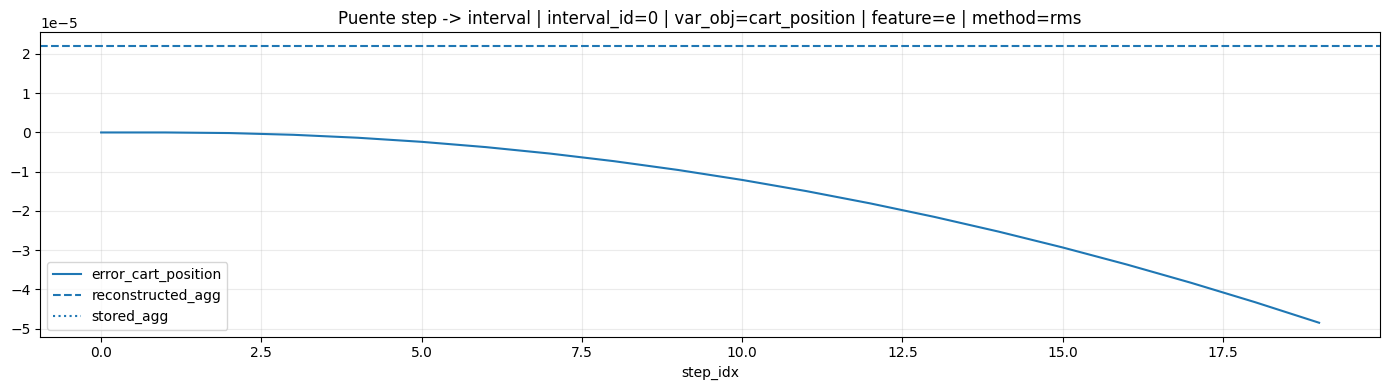

In [177]:
plot_job_row = metric_jobs_df.loc[
    (metric_jobs_df['var_obj'] == PLOT_VAR_OBJ) &
    (metric_jobs_df['feature_key'] == PLOT_FEATURE_KEY)
].iloc[0]

plot_interval_row = interval_df.loc[interval_df['interval_id'] == PLOT_INTERVAL_ID].iloc[0]

plot_start_idx = int(plot_interval_row['interval_start_step_idx'])
plot_end_idx = int(plot_interval_row['interval_end_step_idx'])

plot_step_slice_df = step_timeline_df.iloc[plot_start_idx:plot_end_idx + 1].copy()

plot_source_col = plot_job_row['source_step_col']
plot_method = plot_job_row['method']
plot_stored_agg_col = plot_job_row['stored_agg_col']
plot_stored_L_col = plot_job_row['stored_L_col']

plot_reconstructed_agg = aggregate_metric_processing_series(
    plot_step_slice_df[plot_source_col],
    plot_method
)

plot_stored_agg = plot_interval_row[plot_stored_agg_col] if plot_stored_agg_col in plot_interval_row.index else np.nan

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    plot_step_slice_df[PLOT_X_COL],
    pd.to_numeric(plot_step_slice_df[plot_source_col], errors='coerce'),
    label=plot_source_col
)

ax.axhline(plot_reconstructed_agg, linestyle='--', label='reconstructed_agg')
ax.axhline(plot_stored_agg, linestyle=':', label='stored_agg')

ax.set_title(
    f'Puente step -> interval | interval_id={PLOT_INTERVAL_ID} | var_obj={PLOT_VAR_OBJ} | feature={PLOT_FEATURE_KEY} | method={plot_method}'
)
ax.set_xlabel(PLOT_X_COL)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### Subcaja C.5 — Ficha técnica local de la reconstrucción puntual

Este bloque resume numéricamente la reconstrucción puntual mostrada en el gráfico.

#### Qué contiene
- intervalo elegido;
- lazo y feature auditados;
- método de agregación usado;
- valor agregado reconstruido;
- valor agregado persistido;
- valor `L_*` persistido y reconstruido;
- gaps correspondientes.

#### Qué se debería buscar
- Si el valor reconstruido coincide con el valor persistido.
- Si la normalización parece coherente con el rango configurado.
- Si una discrepancia viene del agregado o aparece recién al pasar a `L_*`.
- Esta ficha deja un caso concreto listo para discusión técnica o para enlazar con la Caja 11.

In [178]:
if plot_job_row['normalization_enabled']:
    plot_reconstructed_L = normalize_metric_processing_value(
        plot_reconstructed_agg,
        [plot_job_row['range_min'], plot_job_row['range_max']],
        [plot_job_row['output_min'], plot_job_row['output_max']],
        plot_method
    )
else:
    plot_reconstructed_L = plot_reconstructed_agg

plot_stored_L = plot_interval_row[plot_stored_L_col] if plot_stored_L_col in plot_interval_row.index else np.nan

plot_bridge_resume_df = pd.DataFrame([
    {'field': 'interval_id', 'value': int(PLOT_INTERVAL_ID)},
    {'field': 'var_obj', 'value': PLOT_VAR_OBJ},
    {'field': 'feature_key', 'value': PLOT_FEATURE_KEY},
    {'field': 'source_step_col', 'value': plot_source_col},
    {'field': 'method', 'value': plot_method},
    {'field': 'reconstructed_agg', 'value': plot_reconstructed_agg},
    {'field': 'stored_agg', 'value': plot_stored_agg},
    {'field': 'agg_gap', 'value': plot_reconstructed_agg - plot_stored_agg if pd.notna(plot_stored_agg) else np.nan},
    {'field': 'reconstructed_L', 'value': plot_reconstructed_L},
    {'field': 'stored_L', 'value': plot_stored_L},
    {'field': 'L_gap', 'value': plot_reconstructed_L - plot_stored_L if pd.notna(plot_stored_L) else np.nan},
    {'field': 'range_min', 'value': plot_job_row['range_min']},
    {'field': 'range_max', 'value': plot_job_row['range_max']},
    {'field': 'output_min', 'value': plot_job_row['output_min']},
    {'field': 'output_max', 'value': plot_job_row['output_max']},
])

display(plot_bridge_resume_df)

,field,value
0,interval_id,0
1,var_obj,cart_position
2,feature_key,e
3,source_step_col,error_cart_position
4,method,rms
5,reconstructed_agg,0.000022
6,stored_agg,NaN
7,agg_gap,NaN
8,reconstructed_L,0.000022
9,stored_L,0.000025


- Esta caja deja reconstruido el paso crítico entre serie step-level y métrica interval-level.
- La salida útil que heredan las siguientes cajas es:
  - `metric_bridge_df`
  - `metric_bridge_summary_df`
  - `metric_bridge_top_gaps_df`
  - `plot_bridge_resume_df`
- Lo importante aquí es distinguir si la desalineación observada en cajas anteriores nace:
  - en la propia serie step-level;
  - en el método de agregación;
  - en la normalización;
  - o recién después, en la matemática del reward.

## Caja 11 - Sanity Check del reward principal
- Esta caja audita cómo se construye el reward principal y qué término lo domina realmente.
- El objetivo no es mirar solo el valor final de `principal_reward`, sino separar:
  - inventario estructural;
  - descomposición por lazo;
  - comparación causal entre familias de términos;
  - reconstrucción desde contribuciones explícitas cuando estén disponibles.
- Esta caja funciona como puente entre la agregación auditada en la Caja 10 y la integración completa del reward que se estudiará después.

### Subcaja A.1 — Inventario de términos principales disponibles

Este bloque identifica qué columnas del reward principal están efectivamente disponibles en el episodio.

#### Qué grupos se están inventariando
- **feature_term_map**: columnas `L_e_*`, `L_edot_*`, `L_I_*`, `L_u_*`, `L_delta_u_*` por lazo.
- **contribution_map**: columnas `principal_contribution_*` por feature y lazo, cuando fueron expuestas por la corrida.
- **gate_map**: columnas `principal_gate_*` por feature y lazo, cuando existen.
- **principal_feature_values**: columnas `principal_feature_value_*`.
- **principal_feature_rewards**: columnas `principal_feature_reward_*`, si el método del principal reward las deja disponibles.
- **principal_loop_rewards**: columnas `L_<var_obj>`, que representan la recompensa principal por lazo persistida por `RewardCalculatorBase`.
- **principal_reward**: reward principal global del intervalo.

#### Por qué es importante
La auditoría del reward principal no puede asumir que todas las familias existen en todas las corridas. Primero debe declarar qué material real está disponible.

#### Qué se debería buscar
- Si están presentes las familias centrales `L_e`, `L_edot`, `L_I`, `L_u`, `L_delta_u`.
- Si la corrida expone contribuciones y gates, lo que permite una reconstrucción más rica.
- Si existen `principal_feature_reward_*`, lo que suele indicar un método exponencial con descomposición explícita.

In [185]:
principal_feature_term_map = build_principal_feature_term_map(interval_df, available_control_loop_var_objs)
principal_contribution_map = build_principal_contribution_map(interval_df, available_control_loop_var_objs)
principal_gate_map = build_principal_gate_map(interval_df, available_control_loop_var_objs)

principal_feature_values_cols = [c for c in interval_df.columns if c.startswith('principal_feature_value_')]
principal_feature_rewards_cols = [c for c in interval_df.columns if c.startswith('principal_feature_reward_')]
principal_loop_reward_cols = [f'L_{var_obj}' for var_obj in available_control_loop_var_objs if f'L_{var_obj}' in interval_df.columns]

principal_inventory_df = pd.DataFrame([
    {'group': 'principal_reward', 'n_cols': 1 if 'principal_reward' in interval_df.columns else 0, 'cols': ['principal_reward'] if 'principal_reward' in interval_df.columns else []},
    {'group': 'principal_feature_values', 'n_cols': len(principal_feature_values_cols), 'cols': principal_feature_values_cols},
    {'group': 'principal_feature_rewards', 'n_cols': len(principal_feature_rewards_cols), 'cols': principal_feature_rewards_cols},
    {'group': 'principal_loop_rewards', 'n_cols': len(principal_loop_reward_cols), 'cols': principal_loop_reward_cols},
    {'group': 'feature_term_map', 'n_cols': int(sum(len(v) for v in principal_feature_term_map.values())), 'cols': principal_feature_term_map},
    {'group': 'contribution_map', 'n_cols': int(sum(len(v) for v in principal_contribution_map.values())), 'cols': principal_contribution_map},
    {'group': 'gate_map', 'n_cols': int(sum(len(v) for v in principal_gate_map.values())), 'cols': principal_gate_map},
])

display(principal_inventory_df)

,group,n_cols,cols
0,principal_reward,0,[]
1,principal_feature_values,0,[]
2,principal_feature_rewards,0,[]
3,principal_loop_rewards,0,[]
4,feature_term_map,6,"{'e': ['L_e_cart_position', 'L_e_pendulum_angl..."
5,contribution_map,2,"{'e': [], 'edot': ['principal_contribution_L_e..."
6,gate_map,2,"{'e': [], 'edot': ['principal_gate_L_edot_cart..."


### Subcaja A.2 — Resumen estructural por familia y por lazo

Este bloque resume cuántos términos principales existen por feature y por lazo.

#### Qué representa
- Cuántas columnas hay para cada familia principal.
- Qué lazos tienen cobertura completa o parcial.
- Si hay asimetrías entre lazos o entre features.

#### Qué se debería buscar
- Si todos los lazos tienen la misma estructura de términos.
- Si alguna feature está ausente o incompleta.
- Si la corrida dejó suficiente granularidad como para hacer una lectura causal robusta.

In [186]:
principal_inventory_resume_rows = []

for feature_key, cols in principal_feature_term_map.items():
    principal_inventory_resume_rows.append({
        'family': f'L_{feature_key}',
        'n_cols': len(cols),
        'cols': cols,
    })

for feature_key, cols in principal_contribution_map.items():
    principal_inventory_resume_rows.append({
        'family': f'principal_contribution_{feature_key}',
        'n_cols': len(cols),
        'cols': cols,
    })

for feature_key, cols in principal_gate_map.items():
    principal_inventory_resume_rows.append({
        'family': f'principal_gate_{feature_key}',
        'n_cols': len(cols),
        'cols': cols,
    })

principal_inventory_resume_df = pd.DataFrame(principal_inventory_resume_rows)
display(principal_inventory_resume_df)

,family,n_cols,cols
0,L_e,2,"[L_e_cart_position, L_e_pendulum_angle]"
1,L_edot,2,"[L_edot_cart_position, L_edot_pendulum_angle]"
2,L_I,0,[]
3,L_u,0,[]
4,L_delta_u,2,"[L_delta_u_cart_position, L_delta_u_pendulum_a..."
5,principal_contribution_e,0,[]
6,principal_contribution_edot,2,"[principal_contribution_L_edot_cart_position, ..."
7,principal_contribution_I,0,[]
8,principal_contribution_u,0,[]
9,principal_contribution_delta_u,0,[]


### Subcaja B — Configuración analítica de la auditoría del reward principal

Este bloque define qué intervalos se priorizarán y qué familias de términos se usarán para construir la lectura causal del reward principal.

#### Significado de los parámetros
- **PRINCIPAL_AUDIT_INTERVAL_IDS**: intervalos a auditar. Conviene usar candidatos provenientes de las cajas anteriores.
- **PRINCIPAL_VAR_OBJS**: lazos incluidos en la auditoría.
- **PRINCIPAL_FEATURE_KEYS**: familias principales que se auditarán.
- **TOP_N_PRINCIPAL_ANOMALIES**: cantidad máxima de intervalos o filas prioritarias a mostrar.
- **SHOW_PRINCIPAL_TIMELINE_COLS**: columnas principales que se incluirán en la vista tabular del timeline principal.

#### Qué criterio seguir
- Si el análisis todavía está en modo screening, conviene usar varios intervalos candidatos.
- Si el objetivo es una auditoría fina, conviene reducir el foco a uno o pocos intervalos.
- Es importante mantener aquí las familias centrales del principal reward para no mezclar todavía extras o coordinación.

In [188]:
# --- CONFIGURACIÓN CELDA ---
PRINCIPAL_AUDIT_INTERVAL_IDS = sorted(set(
    interval_ids_physical_anomaly_candidates[:6] +
    interval_ids_controller_anomaly_candidates[:6]
))

PRINCIPAL_VAR_OBJS = available_control_loop_var_objs
PRINCIPAL_FEATURE_KEYS = [
    'e', 
    'edot', 
    'I', 
    'u', 
    #'delta_u'
    ]

TOP_N_PRINCIPAL_ANOMALIES = 20

SHOW_PRINCIPAL_TIMELINE_COLS = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'principal_reward',
    'global_interval_reward',
]

### Subcaja C.1 — Construcción de scores por familia principal y dominancia de términos

Este bloque construye una base analítica donde el reward principal se descompone por familias de términos y por lazo.

#### Qué se construye aquí
- Suma absoluta por familia `e`, `edot`, `I`, `u`, `delta_u`.
- Suma absoluta total del principal reward por familias.
- Peso relativo de cada familia dentro del total.
- Término dominante por intervalo.
- Suma por lazo de los términos principales disponibles.

#### Qué significa “dominancia”
Un término dominante es aquel cuya magnitud relativa es mayor dentro del conjunto de familias principales del intervalo.

#### Qué se debería buscar
- Si el principal reward está siendo gobernado sistemáticamente por una sola familia.
- Si hay intervalos donde cambia la familia dominante.
- Si la dominancia parece asociada a error, derivada, integral, esfuerzo o variabilidad.
- Esta subcaja es clave para entender qué mueve realmente el reward principal.

In [189]:
principal_audit_df = interval_timeline_df.copy()

principal_feature_score_cols = []

for feature_key in PRINCIPAL_FEATURE_KEYS:
    feature_cols = principal_feature_term_map[feature_key]
    score_col = f'principal_family_abs_{feature_key}'

    principal_audit_df[score_col] = rowwise_abs_sum(principal_audit_df, feature_cols)
    principal_feature_score_cols.append(score_col)

principal_audit_df['principal_family_abs_total'] = rowwise_abs_sum(
    principal_audit_df,
    principal_feature_score_cols
)

for feature_key in PRINCIPAL_FEATURE_KEYS:
    score_col = f'principal_family_abs_{feature_key}'
    weight_col = f'principal_family_weight_{feature_key}'
    principal_audit_df[weight_col] = safe_ratio_series(
        principal_audit_df[score_col],
        principal_audit_df['principal_family_abs_total']
    )

principal_audit_df['principal_dominant_family'] = build_dominant_label(
    principal_audit_df,
    [f'principal_family_abs_{feature_key}' for feature_key in PRINCIPAL_FEATURE_KEYS]
)

for var_obj in PRINCIPAL_VAR_OBJS:
    principal_audit_df[f'principal_loop_abs_{var_obj}'] = rowwise_abs_sum(
        principal_audit_df,
        [f'L_{feature_key}_{var_obj}' for feature_key in PRINCIPAL_FEATURE_KEYS]
    )

### Subcaja C.2 — Resumen de magnitudes y dominancia por familia

Este bloque resume qué tan importante fue cada familia del reward principal a lo largo del episodio.

#### Qué representa
- Magnitud media de cada familia.
- Peso medio relativo dentro del total principal.
- Frecuencia con la que cada familia aparece como dominante.

#### Qué se debería buscar
- Si una familia domina casi siempre, el reward principal podría estar sesgado hacia esa dimensión.
- Si la dominancia cambia mucho entre intervalos, el principal reward podría estar respondiendo a distintos fenómenos en distintos momentos.
- Esta tabla ayuda a distinguir si el reward principal está leyendo sobre todo error, dinámica, esfuerzo o variación de control.

In [190]:
principal_family_summary_rows = []

for feature_key in PRINCIPAL_FEATURE_KEYS:
    principal_family_summary_rows.append({
        'feature_key': feature_key,
        'family_abs_mean': float(pd.to_numeric(principal_audit_df[f'principal_family_abs_{feature_key}'], errors='coerce').mean()),
        'family_abs_max': float(pd.to_numeric(principal_audit_df[f'principal_family_abs_{feature_key}'], errors='coerce').max()),
        'family_weight_mean': float(pd.to_numeric(principal_audit_df[f'principal_family_weight_{feature_key}'], errors='coerce').mean()),
        'dominant_count': int((principal_audit_df['principal_dominant_family'] == f'principal_family_abs_{feature_key}').sum()),
    })

principal_family_summary_df = pd.DataFrame(principal_family_summary_rows).sort_values(
    'family_weight_mean',
    ascending=False
).reset_index(drop=True)

display(principal_family_summary_df)

,feature_key,family_abs_mean,family_abs_max,family_weight_mean,dominant_count
0,e,0.071744,0.199790,0.564657,136
1,edot,0.113622,1.057045,0.435343,66
2,I,NaN,NaN,NaN,0
3,u,NaN,NaN,NaN,0


### Subcaja C.3 — Resumen por lazo del reward principal

Este bloque resume la magnitud del reward principal por lazo y cómo se reparte entre familias.

#### Qué representa
Cada fila corresponde a un lazo y resume qué tan grande fue, en promedio, su participación dentro del principal reward.

#### Qué se debería buscar
- Si un lazo domina estructuralmente el principal reward.
- Si el reparto entre lazos parece equilibrado o muy sesgado.
- Si el reward principal parece estar leyendo más un lazo que otro, aun cuando la física global del episodio no justifique ese sesgo.

In [191]:
principal_loop_summary_rows = []

for var_obj in PRINCIPAL_VAR_OBJS:
    row = {
        'var_obj': var_obj,
        'principal_loop_abs_mean': float(pd.to_numeric(principal_audit_df[f'principal_loop_abs_{var_obj}'], errors='coerce').mean()),
        'principal_loop_abs_max': float(pd.to_numeric(principal_audit_df[f'principal_loop_abs_{var_obj}'], errors='coerce').max()),
    }

    for feature_key in PRINCIPAL_FEATURE_KEYS:
        col = f'L_{feature_key}_{var_obj}'
        if col in principal_audit_df.columns:
            row[f'{feature_key}_mean'] = float(pd.to_numeric(principal_audit_df[col], errors='coerce').mean())
            row[f'{feature_key}_abs_mean'] = float(pd.to_numeric(principal_audit_df[col], errors='coerce').abs().mean())
        else:
            row[f'{feature_key}_mean'] = np.nan
            row[f'{feature_key}_abs_mean'] = np.nan

    principal_loop_summary_rows.append(row)

principal_loop_summary_df = pd.DataFrame(principal_loop_summary_rows)
display(principal_loop_summary_df)

,var_obj,principal_loop_abs_mean,principal_loop_abs_max,e_mean,e_abs_mean,edot_mean,edot_abs_mean,I_mean,I_abs_mean,u_mean,u_abs_mean
0,cart_position,0.096000,0.425375,0.047355,0.047355,0.048645,0.048645,NaN,NaN,NaN,NaN
1,pendulum_angle,0.089367,0.695757,0.024389,0.024389,0.064977,0.064977,NaN,NaN,NaN,NaN


### Subcaja D.1 — Intervalos donde un término domina el reward principal

Este bloque prioriza intervalos donde la magnitud relativa de una familia principal es especialmente alta.

#### Qué representa
Se ordenan los intervalos según el peso relativo del término dominante, identificando casos donde el principal reward parece estar gobernado con fuerza por una sola familia.

#### Qué se debería buscar
- Si el principal reward está dominado por error, derivada, integral, esfuerzo o variación.
- Si intervalos físicamente similares reciben distinto principal reward por cambio de término dominante.
- Esta tabla ayuda a responder qué término cambia primero cuando cambia el principal reward.

In [193]:
principal_audit_df['principal_dominant_weight'] = principal_audit_df[
    [f'principal_family_weight_{feature_key}' for feature_key in PRINCIPAL_FEATURE_KEYS]
].apply(pd.to_numeric, errors='coerce').max(axis=1)

principal_interval_candidates_df = (
    principal_audit_df.loc[
        principal_audit_df['interval_id'].isin(PRINCIPAL_AUDIT_INTERVAL_IDS),
        [
            'interval_id',
            'interval_t_start_sec',
            'interval_t_end_sec',
            #'principal_reward',
            'global_interval_reward',
            'principal_dominant_family',
            'principal_dominant_weight',
        ] + principal_feature_score_cols
    ]
    .sort_values('principal_dominant_weight', ascending=False)
    .head(TOP_N_PRINCIPAL_ANOMALIES)
    .reset_index(drop=True)
)

display(principal_interval_candidates_df)

,interval_id,interval_t_start_sec,interval_t_end_sec,global_interval_reward,principal_dominant_family,principal_dominant_weight,principal_family_abs_e,principal_family_abs_edot,principal_family_abs_I,principal_family_abs_u
0,0,0.00,0.019,-0.123355,principal_family_abs_e,0.971662,0.149952,0.004373,NaN,NaN
1,1,0.02,0.039,-0.124123,principal_family_abs_e,0.905115,0.150065,0.015732,NaN,NaN
2,2,0.04,0.059,-0.124731,principal_family_abs_e,0.802397,0.150147,0.036976,NaN,NaN
3,3,0.06,0.079,-0.124900,principal_family_abs_e,0.691763,0.150045,0.066857,NaN,NaN
4,4,0.08,0.099,-0.124894,principal_family_abs_e,0.585267,0.149612,0.106018,NaN,NaN
5,5,0.10,0.119,-0.124949,principal_family_abs_edot,0.515888,0.148662,0.158420,NaN,NaN


### Subcaja D.2 — Evolución temporal del principal reward y de sus familias

Este bloque muestra la trayectoria temporal del principal reward junto con las principales familias que lo componen.

#### Qué muestra
- El valor del `principal_reward` por intervalo.
- Las magnitudes agregadas de las familias principales.
- Cómo cambia la dominancia de términos a lo largo del episodio.

#### Qué se debería buscar
- Si los cambios en `principal_reward` coinciden con cambios en una familia concreta.
- Si un término domina solo en ciertos tramos del episodio.
- Si el principal reward parece responder más a error, derivada, integral, esfuerzo o variabilidad.

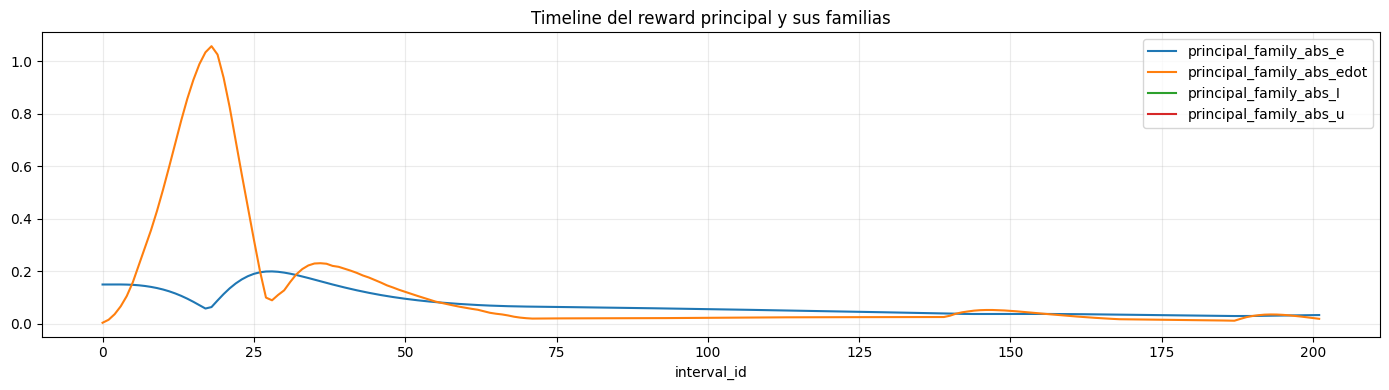

In [194]:
principal_timeline_plot_cols = ['principal_reward'] + principal_feature_score_cols
principal_timeline_plot_cols = [c for c in principal_timeline_plot_cols if c in principal_audit_df.columns]

ax = principal_audit_df.plot(
    x='interval_id',
    y=principal_timeline_plot_cols,
    figsize=(14, 4),
    grid=True
)

ax.set_title('Timeline del reward principal y sus familias')
ax.set_xlabel('interval_id')
plt.tight_layout()
plt.show()

### Subcaja E.1 — Inventario de contribuciones explícitas disponibles

Este bloque revisa si la corrida dejó expuestas contribuciones directas por feature y por lazo.

#### Por qué es importante
Cuando estas columnas existen, permiten pasar desde una lectura indirecta de `L_*` a una reconstrucción más cercana a la matemática interna del reward principal.

#### Qué se debería buscar
- Si hay contribuciones disponibles por lazo y por feature.
- Si la corrida dejó o no evidencia suficiente para una reconstrucción explícita.
- Si no existen estas columnas, la caja igual puede leer dominancia desde `L_*`, pero no desde contribuciones directas.

In [195]:
principal_contribution_inventory_df = pd.DataFrame([
    {'feature_key': feature_key, 'n_cols': len(cols), 'cols': cols}
    for feature_key, cols in principal_contribution_map.items()
])

display(principal_contribution_inventory_df)

,feature_key,n_cols,cols
0,e,0,[]
1,edot,2,"[principal_contribution_L_edot_cart_position, ..."
2,I,0,[]
3,u,0,[]
4,delta_u,0,[]


### Subcaja E.2 — Reconstrucción por contribuciones explícitas

Este bloque construye una auditoría basada en `principal_contribution_*` cuando esas columnas están disponibles.

#### Qué representa
- Magnitud absoluta de las contribuciones por familia.
- Familia dominante según contribuciones explícitas.
- Comparación entre suma de contribuciones y `principal_reward`.

#### Qué se debería buscar
- Si las contribuciones explícitas cuentan la misma historia que las familias `L_*`.
- Si la suma de contribuciones se aproxima razonablemente al `principal_reward`.
- Si hay intervalos donde el principal reward parece cambiar por una contribución concreta.

In [ ]:
principal_contribution_audit_df = principal_audit_df.copy()

principal_contribution_score_cols = []

for feature_key in PRINCIPAL_FEATURE_KEYS:
    contribution_cols = principal_contribution_map[feature_key]
    score_col = f'principal_contribution_abs_{feature_key}'

    principal_contribution_audit_df[score_col] = rowwise_abs_sum(
        principal_contribution_audit_df,
        contribution_cols
    )
    principal_contribution_score_cols.append(score_col)

principal_contribution_audit_df['principal_contribution_abs_total'] = rowwise_abs_sum(
    principal_contribution_audit_df,
    principal_contribution_score_cols
)

if len(principal_contribution_score_cols) > 0:
    principal_contribution_audit_df['principal_contribution_dominant_family'] = build_dominant_label(
        principal_contribution_audit_df,
        principal_contribution_score_cols
    )
else:
    principal_contribution_audit_df['principal_contribution_dominant_family'] = np.nan

principal_contribution_cols_all = []
for cols in principal_contribution_map.values():
    principal_contribution_cols_all.extend(cols)

principal_contribution_audit_df['principal_contribution_signed_sum'] = sum_existing_cols_rowwise(
    principal_contribution_audit_df,
    principal_contribution_cols_all
)

principal_contribution_audit_df['principal_contribution_vs_reward_gap'] = (
    pd.to_numeric(principal_contribution_audit_df['principal_contribution_signed_sum'], errors='coerce') -
    pd.to_numeric(principal_contribution_audit_df['principal_reward'], errors='coerce')
)

SyntaxError: invalid syntax (192946536.py, line 40)

### Subcaja E.3 — Resumen de contribuciones y gap contra `principal_reward`

Este bloque resume qué tan bien la reconstrucción por contribuciones aproxima el reward principal y qué familias dominan cuando se usa esa lectura.

#### Qué se debería buscar
- Si la reconstrucción por contribuciones es coherente con `principal_reward`.
- Si la familia dominante por contribuciones coincide con la dominante por `L_*`.
- Si aparece un gap grande, puede haber términos no considerados o diferencias de interpretación entre columnas disponibles.

In [198]:
principal_contribution_summary_rows = []

for feature_key in PRINCIPAL_FEATURE_KEYS:
    col = f'principal_contribution_abs_{feature_key}'
    if col in principal_contribution_audit_df.columns:
        principal_contribution_summary_rows.append({
            'feature_key': feature_key,
            'contribution_abs_mean': float(pd.to_numeric(principal_contribution_audit_df[col], errors='coerce').mean()),
            'contribution_abs_max': float(pd.to_numeric(principal_contribution_audit_df[col], errors='coerce').max()),
            'dominant_count': int((principal_contribution_audit_df['principal_contribution_dominant_family'] == col).sum()) if 'principal_contribution_dominant_family' in principal_contribution_audit_df.columns else 0,
        })

principal_contribution_summary_df = pd.DataFrame(principal_contribution_summary_rows)
display(principal_contribution_summary_df)

principal_contribution_gap_df = pd.DataFrame([
    {
        'metric': 'principal_contribution_vs_reward_gap_mean_abs',
        'value': float(pd.to_numeric(principal_contribution_audit_df['principal_contribution_vs_reward_gap'], errors='coerce').abs().mean())
    },
    {
        'metric': 'principal_contribution_vs_reward_gap_max_abs',
        'value': float(pd.to_numeric(principal_contribution_audit_df['principal_contribution_vs_reward_gap'], errors='coerce').abs().max())
    },
])

display(principal_contribution_gap_df)

,feature_key,contribution_abs_mean,contribution_abs_max,dominant_count
0,e,NaN,NaN,0
1,edot,0.00372,0.063264,202
2,I,NaN,NaN,0
3,u,NaN,NaN,0


KeyError: 'principal_contribution_vs_reward_gap'

### Subcaja F — Tabla final del timeline del reward principal

Este bloque deja una vista tabular compacta con el reward principal, sus familias y los indicadores de dominancia construidos en esta caja.

#### Qué contiene
- reward principal global;
- reward global del intervalo;
- familias principales agregadas;
- término dominante;
- pesos relativos;
- magnitudes por lazo.

#### Qué se debería buscar
- Qué familia domina cada intervalo.
- Si el principal reward cambia cuando cambia una familia concreta.
- Si existen intervalos donde un solo término parece gobernar toda la lectura del reward principal.
- Esta tabla deja lista la transición hacia la auditoría de extras y coordinación.

In [199]:
principal_timeline_view_cols = SHOW_PRINCIPAL_TIMELINE_COLS.copy()

principal_timeline_view_cols.extend(principal_feature_score_cols)

for feature_key in PRINCIPAL_FEATURE_KEYS:
    principal_timeline_view_cols.append(f'principal_family_weight_{feature_key}')

principal_timeline_view_cols.extend([
    'principal_family_abs_total',
    'principal_dominant_family',
    'principal_dominant_weight',
])

for var_obj in PRINCIPAL_VAR_OBJS:
    principal_timeline_view_cols.append(f'principal_loop_abs_{var_obj}')

principal_timeline_view_cols = [
    c for c in principal_timeline_view_cols
    if c in principal_audit_df.columns
]

principal_timeline_view_df = principal_audit_df[principal_timeline_view_cols].copy()
display(principal_timeline_view_df)

,interval_id,interval_t_start_sec,interval_t_end_sec,global_interval_reward,principal_family_abs_e,principal_family_abs_edot,principal_family_abs_I,principal_family_abs_u,principal_family_weight_e,principal_family_weight_edot,principal_family_weight_I,principal_family_weight_u,principal_family_abs_total,principal_dominant_family,principal_dominant_weight,principal_loop_abs_cart_position,principal_loop_abs_pendulum_angle
0,0,0.00,0.019,-0.123355,0.149952,0.004373,NaN,NaN,0.971662,0.028338,NaN,NaN,0.154325,principal_family_abs_e,0.971662,0.004027,0.150298
1,1,0.02,0.039,-0.124123,0.150065,0.015732,NaN,NaN,0.905115,0.094885,NaN,NaN,0.165797,principal_family_abs_e,0.905115,0.012755,0.153042
2,2,0.04,0.059,-0.124731,0.150147,0.036976,NaN,NaN,0.802397,0.197603,NaN,NaN,0.187124,principal_family_abs_e,0.802397,0.024618,0.162506
3,3,0.06,0.079,-0.124900,0.150045,0.066857,NaN,NaN,0.691763,0.308237,NaN,NaN,0.216902,principal_family_abs_e,0.691763,0.039144,0.177757
4,4,0.08,0.099,-0.124894,0.149612,0.106018,NaN,NaN,0.585267,0.414733,NaN,NaN,0.255630,principal_family_abs_e,0.585267,0.056518,0.199112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,197,3.94,3.959,-0.004862,0.032569,0.030413,NaN,NaN,0.517121,0.482879,NaN,NaN,0.062982,principal_family_abs_e,0.517121,0.032943,0.030039
198,198,3.96,3.979,-0.004973,0.032907,0.027903,NaN,NaN,0.541147,0.458853,NaN,NaN,0.060809,principal_family_abs_e,0.541147,0.031600,0.029210
199,199,3.98,3.999,-0.004919,0.033215,0.025016,NaN,NaN,0.570400,0.429600,NaN,NaN,0.058231,principal_family_abs_e,0.570400,0.030151,0.028080
200,200,4.00,4.019,-0.005009,0.033499,0.022106,NaN,NaN,0.602443,0.397557,NaN,NaN,0.055606,principal_family_abs_e,0.602443,0.028700,0.026906


- Esta caja deja auditado el reward principal desde su estructura interna.
- La salida útil que heredan las siguientes cajas es:
  - `principal_inventory_df`
  - `principal_inventory_resume_df`
  - `principal_audit_df`
  - `principal_family_summary_df`
  - `principal_loop_summary_df`
  - `principal_interval_candidates_df`
  - `principal_contribution_audit_df`
  - `principal_contribution_summary_df`
  - `principal_timeline_view_df`
- Lo importante aquí es responder:
  - qué término mueve realmente el principal reward;
  - si el principal reward está dominado por una sola señal;
  - si intervalos físicamente parecidos reciben principal rewards distintos por diferencias en la estructura interna del reward.

## Caja 12 - Sanity Check de extra rewards
- Esta caja mide cuánto corrigen o cuánto deforman los extra rewards la lectura del reward principal.
- El objetivo no es mirar solo la suma `extra_total_all`, sino separar:
  - penalties;
  - bonuses;
  - penalties dinámicos;
  - incentivos dinámicos;
  - efecto total del bloque extra sobre el principal reward.
- Esta caja busca responder si los extras complementan la lógica física principal o si, por el contrario, la contradicen o la tapan.

### Subcaja A.1 — Configuración activa de extra rewards en la corrida

Este bloque muestra qué familias de extras estaban habilitadas realmente en la corrida y con qué método general estaban operando.

#### Qué representa cada fila
Cada fila corresponde a una familia del bloque extra, indicando:
- si estaba habilitada;
- y, cuando corresponde, qué método declarativo estaba activo.

#### Por qué es importante
La auditoría de extras no puede asumir que todos los bonuses, penalties o incentivos estuvieron activos. Primero debe declarar qué reglas estaban presentes en la corrida.

#### Qué se debería buscar
- Si hay penalties activos.
- Si hay bonuses activos.
- Si existe penalización o incentivo dinámico.
- Si la corrida tiene un bloque extra simple o uno altamente compuesto.

In [201]:
extra_config_resume_df = build_extra_reward_config_resume_df(run_metadata)
display(extra_config_resume_df)

,group,name,enabled,details
0,extra_rewards_enabled,extra_rewards,True,None
1,penalty_approach,penalty_instantaneous_reward,False,lineal
2,penalty_approach,penalty_delta_var,False,quadratic
3,bonus_approach,goal_bonus_reward,False,decay
4,bonus_approach,bandwidth_bonus,False,bandwidth_bonus
5,conditional_approach,dynamic_penalty,False,quadratic
6,conditional_approach,dynamic_incentive,False,adaptative


### Subcaja A.2 — Inventario de columnas de extras disponibles en el episodio

Este bloque identifica qué columnas concretas del bloque extra están efectivamente presentes en `interval_df`.

#### Qué familias se están inventariando
- penalties instantáneos;
- penalties por delta;
- bonus de goal;
- bonus de banda;
- penalty dinámico;
- incentivo dinámico total;
- desglose de incentivo dinámico por tracking, direction y effort;
- total por lazo.

#### Qué se debería buscar
- Si la corrida dejó un bloque extra simple o muy desagregado.
- Si existen columnas suficientes para saber de qué familia viene el efecto extra.
- Si hay familias configuradas pero no expuestas, la interpretación será más parcial.

In [202]:
extra_family_map = build_extra_family_map(interval_df)

extra_inventory_df = pd.DataFrame([
    {'family': family, 'n_cols': len(cols), 'cols': cols}
    for family, cols in extra_family_map.items()
])

display(extra_inventory_df)

,family,n_cols,cols
0,extra_penalty_instantaneous,2,"[extra_penalty_instantaneous_pendulum_angle, e..."
1,extra_penalty_delta_var,2,"[extra_penalty_pendulum_angle, extra_penalty_c..."
2,extra_bonus_goal,2,"[extra_bonus_goal_pendulum_angle, extra_bonus_..."
3,extra_bonus_band,2,"[extra_bonus_band_pendulum_angle, extra_bonus_..."
4,extra_dynamic_penalty,2,[extra_conditional_dynamic_penalty_pendulum_an...
5,extra_dynamic_incentive,4,[extra_conditional_dynamic_incentive_pendulum_...
6,extra_dynamic_incentive_tracking,2,[extra_conditional_dynamic_incentive_tracking_...
7,extra_dynamic_incentive_direction,2,[extra_conditional_dynamic_incentive_direction...
8,extra_dynamic_incentive_effort,2,[extra_conditional_dynamic_incentive_effort_pe...
9,extra_total,2,"[extra_total_pendulum_angle, extra_total_cart_..."


### Subcaja B — Configuración analítica de la auditoría de extras

Este bloque define qué intervalos se priorizarán y qué umbrales se usarán para clasificar si los extras complementan o deforman la lectura del principal reward.

#### Significado de los parámetros
- **EXTRA_AUDIT_INTERVAL_IDS**: intervalos a auditar con prioridad. Conviene usar candidatos provenientes de las cajas anteriores.
- **BAD_CONTEXT_THRESHOLD**: umbral a partir del cual el contexto se considerará problemático. Se alimenta de los scores de física y control ya construidos.
- **GOOD_CONTEXT_THRESHOLD**: umbral a partir del cual el contexto se considerará favorable.
- **TOP_N_EXTRA_ANOMALIES**: cantidad máxima de intervalos sospechosos que se mostrarán.
- **SHOW_EXTRA_TIMELINE_COLS**: columnas que se incluirán en la vista tabular final.

#### Qué criterio se está usando
La caja compara:
- el principal reward;
- el efecto de los extras;
- y el contexto físico/control del intervalo.

La idea es detectar si los extras:
- premian demasiado un intervalo que seguía siendo malo;
- castigan demasiado un intervalo que ya se veía razonablemente bueno;
- o si simplemente refuerzan la lógica del principal reward.

In [204]:
# --- CONFIGURACIÓN CELDA ---
EXTRA_AUDIT_INTERVAL_IDS = sorted(set(
    interval_ids_physical_anomaly_candidates[:6] +
    interval_ids_controller_anomaly_candidates[:6]
))

BAD_CONTEXT_THRESHOLD = 0.55
GOOD_CONTEXT_THRESHOLD = 0.35

TOP_N_EXTRA_ANOMALIES = 20

SHOW_EXTRA_TIMELINE_COLS = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'principal_reward',
    'extra_total_all',
    'global_interval_reward',
]

### Subcaja C.1 — Construcción de la base analítica de extras

Este bloque construye una base donde se resume el efecto de cada familia de extras y su relación con el principal reward.

#### Qué se construye aquí
- total por familia de extras;
- total global de extras;
- reward principal más extras;
- peso relativo de los extras respecto al principal reward;
- familia dominante dentro del bloque extra;
- clasificación lógica del efecto de los extras según el contexto físico y de control.

#### Qué significa cada variable nueva
- **extra_penalty_instantaneous_all**: efecto total de penalties instantáneos.
- **extra_penalty_delta_var_all**: efecto total de penalties por variación.
- **extra_bonus_goal_all**: efecto total de goal bonus.
- **extra_bonus_band_all**: efecto total de bonus de permanencia en banda.
- **extra_dynamic_penalty_all**: efecto total de penalties dinámicos.
- **extra_dynamic_incentive_all**: efecto total agregado de incentivos dinámicos.
- **extra_total_all**: suma de los extras por lazo.
- **principal_plus_extra**: reward principal después del bloque extra, pero antes de coordinación.
- **extra_vs_principal_ratio_abs**: magnitud relativa del bloque extra respecto al principal reward.
- **extra_dominant_family**: familia de extras que más pesa en el intervalo.
- **extra_effect_zone**: clasificación lógica del rol de los extras en ese intervalo.

#### Qué se debería buscar
- Si el bloque extra es pequeño y complementario.
- Si el bloque extra es suficientemente grande como para cambiar de forma importante la lectura del principal reward.
- Si un bonus o penalty domina casi todo el efecto extra.

In [205]:
extra_audit_df = principal_audit_df.copy()

extra_family_score_cols = []

for family, cols in extra_family_map.items():
    if family == 'extra_total':
        continue

    out_col = f'{family}_all'
    extra_audit_df[out_col] = sum_existing_cols_rowwise(extra_audit_df, cols)
    extra_family_score_cols.append(out_col)

if 'extra_total_all' not in extra_audit_df.columns:
    extra_audit_df['extra_total_all'] = sum_existing_cols_rowwise(
        extra_audit_df,
        extra_family_map['extra_total']
    )

extra_audit_df['principal_plus_extra'] = (
    pd.to_numeric(extra_audit_df['principal_reward'], errors='coerce') +
    pd.to_numeric(extra_audit_df['extra_total_all'], errors='coerce')
)

extra_audit_df['extra_vs_principal_ratio_abs'] = safe_ratio_series(
    pd.to_numeric(extra_audit_df['extra_total_all'], errors='coerce').abs(),
    pd.to_numeric(extra_audit_df['principal_reward'], errors='coerce').abs()
)

extra_audit_df['extra_family_abs_total'] = rowwise_abs_sum(
    extra_audit_df,
    extra_family_score_cols
)

for score_col in extra_family_score_cols:
    extra_audit_df[f'{score_col}_weight'] = safe_ratio_series(
        pd.to_numeric(extra_audit_df[score_col], errors='coerce').abs(),
        extra_audit_df['extra_family_abs_total']
    )

if len(extra_family_score_cols) > 0:
    extra_audit_df['extra_dominant_family'] = build_dominant_label(
        extra_audit_df,
        [f'{score_col}_weight' for score_col in extra_family_score_cols]
    )
else:
    extra_audit_df['extra_dominant_family'] = np.nan

extra_audit_df['extra_effect_zone'] = extra_audit_df.apply(
    lambda row: classify_extra_vs_principal(
        principal_reward=row['principal_reward'],
        extra_total=row['extra_total_all'],
        physics_badness=row['physics_badness_score'] if 'physics_badness_score' in row.index else np.nan,
        controller_stress=row['controller_stress_score'] if 'controller_stress_score' in row.index else np.nan,
        bad_context_thr=BAD_CONTEXT_THRESHOLD,
        good_context_thr=GOOD_CONTEXT_THRESHOLD
    ),
    axis=1
)

KeyError: 'principal_reward'

### Subcaja C.2 — Resumen de magnitudes y dominancia por familia de extras

Este bloque resume cuánto pesa cada familia de extras a lo largo del episodio.

#### Qué representa
- Magnitud media de cada familia.
- Magnitud máxima observada.
- Peso relativo medio dentro del bloque extra.
- Frecuencia con la que esa familia aparece como dominante.

#### Qué se debería buscar
- Si el efecto extra está dominado por penalties, bonuses o incentivos dinámicos.
- Si una sola familia explica casi todo el comportamiento del bloque extra.
- Si la estructura de extras parece equilibrada o claramente sesgada hacia un mecanismo específico.

In [206]:
extra_family_summary_rows = []

for score_col in extra_family_score_cols:
    weight_col = f'{score_col}_weight'

    extra_family_summary_rows.append({
        'extra_family': score_col,
        'family_mean': float(pd.to_numeric(extra_audit_df[score_col], errors='coerce').mean()),
        'family_abs_mean': float(pd.to_numeric(extra_audit_df[score_col], errors='coerce').abs().mean()),
        'family_abs_max': float(pd.to_numeric(extra_audit_df[score_col], errors='coerce').abs().max()),
        'family_weight_mean': float(pd.to_numeric(extra_audit_df[weight_col], errors='coerce').mean()),
        'dominant_count': int((extra_audit_df['extra_dominant_family'] == weight_col).sum()),
    })

extra_family_summary_df = pd.DataFrame(extra_family_summary_rows).sort_values(
    'family_weight_mean',
    ascending=False
).reset_index(drop=True)

display(extra_family_summary_df)

KeyError: 'extra_penalty_instantaneous_all_weight'

### Subcaja D.1 — Resumen global de la relación entre principal reward y extras

Este bloque resume cómo se comporta, en promedio, el bloque extra respecto al principal reward y al contexto físico/control.

#### Qué representa
- valor medio del principal reward;
- valor medio del bloque extra;
- ratio medio entre extras y principal;
- cantidad de intervalos por tipo de efecto lógico.

#### Qué se debería buscar
- Si los extras son pequeños complementos o si tienen magnitud suficiente como para reescribir la lectura del principal reward.
- Si predominan casos donde los extras apoyan la lógica del intervalo o donde parecen tapar problemas.
- Si la corrida contiene muchos casos donde un bonus positivo aparece sobre física o control claramente malos.

In [ ]:
extra_relation_summary_df = (
    extra_audit_df
    .groupby('extra_effect_zone')
    .agg(
        n_intervals=('interval_id', 'count'),
        principal_reward_mean=('principal_reward', 'mean'),
        extra_total_all_mean=('extra_total_all', 'mean'),
        extra_vs_principal_ratio_abs_mean=('extra_vs_principal_ratio_abs', 'mean'),
        physics_badness_score_mean=('physics_badness_score', 'mean'),
        controller_stress_score_mean=('controller_stress_score', 'mean'),
    )
    .reset_index()
    .sort_values('n_intervals', ascending=False)
)

display(extra_relation_summary_df)

### Subcaja D.2 — Selección de intervalos donde los extras parecen deformar la lectura

Este bloque prioriza los intervalos donde el efecto extra parece más sospechoso.

#### Qué criterio se usa
Se priorizan intervalos donde:
- los extras tienen magnitud relevante frente al principal reward;
- y además la zona lógica sugiere que podrían estar tapando un problema o castigando de más un intervalo favorable.

#### Qué se debería buscar
- Qué intervalos presentan un efecto extra especialmente grande.
- Qué familia de extras domina en esos casos.
- Si esos intervalos coinciden con anomalías detectadas en la Caja 8 o 9.
- Esta salida es la base para decidir qué casos bajar después a reconstrucción fina.

In [ ]:
extra_candidate_intervals_df = (
    extra_audit_df.loc[
        extra_audit_df['extra_effect_zone'].isin([
            'extra_bonus_masks_problem',
            'extra_bonus_reverses_bad_context',
            'extra_penalty_hurts_good_interval',
            'extra_penalty_reverses_good_context',
        ]),
        [
            'interval_id',
            'interval_t_start_sec',
            'interval_t_end_sec',
            'principal_reward',
            'extra_total_all',
            'principal_plus_extra',
            'global_interval_reward',
            'extra_vs_principal_ratio_abs',
            'physics_badness_score',
            'controller_stress_score',
            'extra_effect_zone',
            'extra_dominant_family',
        ] + extra_family_score_cols
    ]
    .sort_values('extra_vs_principal_ratio_abs', ascending=False)
    .head(TOP_N_EXTRA_ANOMALIES)
    .reset_index(drop=True)
)

display(extra_candidate_intervals_df)

interval_ids_extra_anomaly_candidates = extra_candidate_intervals_df['interval_id'].tolist()

### Subcaja D.3 — Evolución temporal del bloque extra y de sus familias

Este bloque muestra cómo evoluciona el efecto total de extras y cuáles familias lo están explicando a lo largo del episodio.

#### Qué muestra
- `principal_reward`;
- `extra_total_all`;
- `principal_plus_extra`;
- familias principales del bloque extra.

#### Qué se debería buscar
- Si los extras solo corrigen marginalmente al principal reward o si lo desvían con fuerza.
- Si ciertos tramos del episodio están dominados por bonuses o por penalties.
- Si la familia dominante cambia cerca de intervalos físicamente problemáticos.

In [ ]:
extra_plot_cols = [
    'principal_reward',
    'extra_total_all',
    'principal_plus_extra',
] + extra_family_score_cols

extra_plot_cols = [c for c in extra_plot_cols if c in extra_audit_df.columns]

ax = extra_audit_df.plot(
    x='interval_id',
    y=extra_plot_cols,
    figsize=(14, 4),
    grid=True
)

ax.set_title('Timeline del bloque extra y sus familias')
ax.set_xlabel('interval_id')
plt.tight_layout()
plt.show()

### Subcaja E.1 — Tabla contextual para interpretar el efecto de extras

Este bloque deja una tabla donde el bloque extra se observa junto al principal reward y a los scores de física y control ya construidos.

#### Por qué es importante
Los extras no deben interpretarse aislados. Un bonus positivo no significa automáticamente un problema; la lectura depende del contexto físico y del estado del control.

#### Qué se debería buscar
- Si el bonus aparece en intervalos donde la física ya era razonablemente buena.
- Si un penalty aparece cuando la física o el control seguían siendo problemáticos.
- Si el contexto contradice el signo del efecto extra.

In [ ]:
extra_context_view_cols = SHOW_EXTRA_TIMELINE_COLS.copy()

extra_context_view_cols.extend([
    'physics_badness_score',
    'controller_stress_score',
    'extra_vs_principal_ratio_abs',
    'extra_effect_zone',
    'extra_dominant_family',
])

extra_context_view_cols.extend(extra_family_score_cols)

extra_context_view_cols = [c for c in extra_context_view_cols if c in extra_audit_df.columns]

extra_context_view_df = extra_audit_df[extra_context_view_cols].copy()
display(extra_context_view_df)

### Subcaja F.1 — Configuración local para revisar un caso puntual

Este bloque permite fijar un intervalo concreto para mirar el contexto local del caso desde la perspectiva del bloque extra.

#### Significado de los parámetros
- **EXTRA_LOCAL_INTERVAL_ID**: intervalo puntual a revisar.
- **EXTRA_LOCAL_STEP_COLS**: señales step-level que se quieren observar como contexto local.

#### Qué criterio seguir
Conviene elegir un intervalo candidato donde el bloque extra parezca especialmente sospechoso o especialmente dominante.

In [ ]:
# --- CONFIGURACIÓN CELDA ---
EXTRA_LOCAL_INTERVAL_ID = interval_ids_extra_anomaly_candidates[0] if len(interval_ids_extra_anomaly_candidates) > 0 else int(extra_audit_df.iloc[0]['interval_id'])

EXTRA_LOCAL_STEP_COLS = [
    'pendulum_angle_raw',
    'cart_position_raw',
    'u_total',
    'delta_u_total',
    'is_saturated_global',
]

for var_obj in available_control_loop_var_objs:
    EXTRA_LOCAL_STEP_COLS.extend([
        f'error_{var_obj}',
        f'u_eff_{var_obj}',
        f'delta_u_eff_{var_obj}',
    ])

### Subcaja F.2 — Vista local del intervalo candidato

Este bloque reconstruye una ventana step-level del intervalo elegido y la acompaña con una ficha técnica del bloque extra para ese caso.

#### Qué se debería buscar
- Cómo era el contexto físico y de control cuando apareció el efecto extra.
- Si el intervalo parecía realmente merecer el bonus o penalty observado.
- Si las señales locales sugieren que el bloque extra refuerza la lógica del intervalo o la contradice.

In [ ]:
extra_local_interval_row = interval_timeline_df.loc[
    interval_timeline_df['interval_id'] == EXTRA_LOCAL_INTERVAL_ID
].iloc[0]

extra_local_start_idx = int(extra_local_interval_row['interval_start_step_idx'])
extra_local_end_idx = int(extra_local_interval_row['interval_end_step_idx'])

extra_local_step_df = step_timeline_df.iloc[extra_local_start_idx:extra_local_end_idx + 1].copy()

extra_local_resume_df = extra_audit_df.loc[
    extra_audit_df['interval_id'] == EXTRA_LOCAL_INTERVAL_ID,
    [
        'interval_id',
        'principal_reward',
        'extra_total_all',
        'principal_plus_extra',
        'global_interval_reward',
        'physics_badness_score',
        'controller_stress_score',
        'extra_effect_zone',
        'extra_dominant_family',
    ] + extra_family_score_cols
].copy()

display(extra_local_resume_df)

### Subcaja F.3 — Visualización local del contexto step-level del intervalo elegido

Este bloque muestra las señales step-level seleccionadas para contextualizar localmente el caso.

#### Qué muestra
- evolución física local;
- evolución del control local;
- saturación o variabilidad, si están disponibles.

#### Qué se debería buscar
- Si el intervalo estaba realmente en una condición que justificara el bonus o penalty.
- Si el patrón local parece coherente con la familia extra dominante.
- Esta visualización no reconstruye la matemática interna del extra, pero sí ayuda a juzgar si su efecto parece razonable en contexto.

In [ ]:
extra_local_plot_cols = [c for c in EXTRA_LOCAL_STEP_COLS if c in extra_local_step_df.columns]

fig, ax = plt.subplots(figsize=(14, 4))

for col in extra_local_plot_cols:
    ax.plot(
        extra_local_step_df['step_idx'],
        pd.to_numeric(extra_local_step_df[col], errors='coerce'),
        label=col
    )

ax.set_title(f'Contexto local step-level | interval_id={EXTRA_LOCAL_INTERVAL_ID}')
ax.set_xlabel('step_idx')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

- Esta caja deja auditado el bloque de extra rewards desde su estructura interna y su relación con el principal reward.
- La salida útil que heredan las siguientes cajas es:
  - `extra_config_resume_df`
  - `extra_inventory_df`
  - `extra_audit_df`
  - `extra_family_summary_df`
  - `extra_relation_summary_df`
  - `extra_candidate_intervals_df`
  - `interval_ids_extra_anomaly_candidates`
  - `extra_context_view_df`
  - `extra_local_resume_df`
- Lo importante aquí es responder:
  - si los extras son complemento o distorsión;
  - qué familia extra domina realmente;
  - si un intervalo termina pareciendo bueno por un bonus aunque la dinámica siga siendo mala;
  - o si un penalty está castigando un intervalo que ya se veía razonablemente bueno.

## Caja 13 - Sanity Check del reward coordinativo
- Esta caja valida si el progreso global y el reparto de crédito del bloque coordinativo están bien representados.
- El objetivo no es mirar solo el `coordination_reward_total`, sino separar:
  - potencial de tarea;
  - progreso entre intervalos;
  - progreso premiable;
  - crédito raw por lazo;
  - share de crédito por lazo;
  - bonus coordinativo final por lazo.
- Esta caja busca responder si el bloque coordinativo está premiando mejora real del sistema y si el crédito se está llevando el lazo que realmente ayudó.

### Subcaja A.1 — Configuración activa del reward coordinativo en la corrida

Este bloque muestra qué configuración real tuvo el bloque coordinativo en la corrida.

#### Qué representa cada campo
- **reward_mode**: forma general del reward coordinativo.
- **assign_mode**: forma general del reparto.
- **global_weight**: peso global del bloque coordinativo.
- **progress_positive_only**: indica si solo se premia progreso positivo.
- **progress_clip_max**: límite superior del progreso premiable.
- **potential_features**: familias del reward principal que alimentan el potencial de tarea.
- **contribution_error_signal**: señal de error usada para medir contribución por lazo.
- **contribution_effort_signal**: señal de esfuerzo usada para medir contribución por lazo.
- **credit_reduction_mode**: forma de reducir la contribución a una métrica por intervalo.
- **epsilon_credit**: término de estabilización para el cálculo del share de crédito.
- **correction_signs**: signo correctivo esperado por lazo.

#### Por qué es importante
La lectura del bloque coordinativo depende directamente de estas reglas. No basta observar sus columnas de salida; primero hay que declarar qué estaba intentando medir el bloque.

#### Qué se debería buscar
- Qué señales usa el bloque para medir progreso y crédito.
- Si la corrida está premiando solo progreso positivo o no.
- Si el bloque está configurado de forma potencialmente muy sensible o muy laxa.

In [208]:
coordination_config_resume_df = build_coordination_config_resume_df(run_metadata)
display(coordination_config_resume_df)

,field,value
0,enabled,True
1,reward_mode,task_progress_credit_assignment
2,assign_mode,per_var
3,global_weight,0.3
4,progress_positive_only,True
5,progress_clip_max,0.25
6,potential_features,"[L_e, L_edot]"
7,contribution_error_signal,error_{var_obj}
8,contribution_effort_signal,u_eff_{var_obj}
9,credit_reduction_mode,average


### Subcaja A.2 — Inventario de columnas coordinativas disponibles en el episodio

Este bloque identifica qué columnas concretas del bloque coordinativo están efectivamente presentes en `interval_df`.

#### Qué familias se están inventariando
- métricas globales de coordinación;
- crédito raw por lazo;
- share de crédito por lazo;
- bonus coordinativo final por lazo.

#### Qué se debería buscar
- Si están presentes las variables necesarias para auditar progreso y reparto de crédito.
- Si el episodio dejó expuesto el bonus coordinativo por lazo.
- Si hay suficiente desagregación para contrastar la lógica del bloque coordinativo con la mejora física real.

In [209]:
coordination_family_map = build_coordination_family_map(interval_df, available_control_loop_var_objs)

coordination_inventory_df = pd.DataFrame([
    {'family': family, 'n_cols': len(cols), 'cols': cols}
    for family, cols in coordination_family_map.items()
])

display(coordination_inventory_df)

,family,n_cols,cols
0,coordination_global,4,"[coordination_task_potential, coordination_tas..."
1,coordination_credit_raw,2,"[coordination_credit_raw_cart_position, coordi..."
2,coordination_credit_share,2,"[coordination_credit_share_cart_position, coor..."
3,coordination_bonus_per_var,2,[extra_conditional_coordination_bonus_cart_pos...


### Subcaja B — Configuración analítica de la auditoría coordinativa

Este bloque define qué intervalos se priorizarán y qué columnas se usarán para la lectura del progreso y del reparto de crédito.

#### Significado de los parámetros
- **COORD_AUDIT_INTERVAL_IDS**: intervalos a auditar con prioridad.
- **TOP_N_COORD_ANOMALIES**: cantidad máxima de intervalos sospechosos que se mostrarán.
- **SHOW_COORD_TIMELINE_COLS**: columnas base que se incluirán en la vista tabular final.

#### Qué criterio se está usando
La caja contrasta:
- progreso coordinativo;
- mejora física aproximada;
- crédito por lazo;
- mejora física aproximada por lazo.

La idea es distinguir si el bloque coordinativo premia progreso real o solo progreso aparente.

In [212]:
# --- CONFIGURACIÓN CELDA ---
COORD_AUDIT_INTERVAL_IDS = sorted(set(
    interval_ids_physical_anomaly_candidates[:6] +
    interval_ids_controller_anomaly_candidates[:6]) #+
    #interval_ids_extra_anomaly_candidates[:6])
)

TOP_N_COORD_ANOMALIES = 20

SHOW_COORD_TIMELINE_COLS = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'coordination_task_potential',
    'coordination_task_progress_delta',
    'coordination_task_progress_positive',
    'coordination_reward_total',
]

### Subcaja C.1 — Señales de contexto y señales fuente del crédito coordinativo

Este bloque deja explícitas las señales step-level que el bloque coordinativo usa para calcular crédito por lazo.

#### Qué representa
- señales de error por lazo;
- señales de esfuerzo por lazo.

#### Por qué es importante
El reparto de crédito coordinativo no nace desde `interval_df` en bruto. Nace desde series step-level que el handler combina para estimar contribución correctiva.

#### Qué se debería buscar
- Qué señales concretas usa el bloque.
- Si esas señales efectivamente existen en `step_df`.
- Si la elección de señales parece coherente con el fenómeno que se quiere premiar.

In [213]:
coordination_context_signals = extract_coordination_signal_cols(
    run_metadata,
    available_control_loop_var_objs
)

coordination_context_signals_df = pd.DataFrame([
    {'group': 'error_cols', 'cols': coordination_context_signals['error_cols']},
    {'group': 'effort_cols', 'cols': coordination_context_signals['effort_cols']},
])

display(coordination_context_signals_df)

,group,cols
0,error_cols,"[error_cart_position, error_pendulum_angle]"
1,effort_cols,"[u_eff_cart_position, u_eff_pendulum_angle]"


### Subcaja C.2 — Construcción de la base analítica coordinativa

Este bloque construye la base principal de la caja, integrando:

- columnas coordinativas del episodio;
- contexto físico y de control ya construido en cajas anteriores;
- mejora física aproximada entre intervalos;
- mejora física aproximada por lazo;
- lazo dominante por crédito coordinativo;
- lazo dominante por mejora física.

#### Qué significa cada variable nueva
- **physics_progress_delta**: aproximación del progreso físico global entre intervalos.  
  Se calcula como reducción del score de deterioro físico.
- **dominant_credit_var / dominant_credit_share**: lazo que recibe mayor share de crédito coordinativo y magnitud de ese share.
- **error_improvement_<var_obj>**: mejora aproximada por lazo entre intervalos, medida como reducción del error agregado de ese lazo.
- **dominant_improvement_var / dominant_improvement_value**: lazo que parece haber mejorado más físicamente en el paso entre intervalos.
- **coordination_progress_zone**: relación lógica entre progreso coordinativo y mejora física global.
- **coordination_credit_zone**: relación lógica entre el lazo premiado y el lazo que parece haber mejorado realmente.

#### Qué se debería buscar
- Si el progreso coordinativo positivo coincide con mejora física real.
- Si el lazo con más crédito coincide con el lazo que parece haber mejorado más.
- Si aparecen casos de crédito sin mejora clara o progreso coordinativo sin mejora física.

In [214]:
coordination_audit_df = interval_timeline_df.copy()

coordination_audit_df = coordination_audit_df.merge(
    physical_reward_audit_df[['interval_id', 'physics_badness_score', 'physical_reward_zone']],
    on='interval_id',
    how='left'
)

coordination_audit_df = coordination_audit_df.merge(
    controller_audit_df[['interval_id', 'controller_stress_score', 'controller_reward_zone']],
    on='interval_id',
    how='left'
)

coordination_audit_df = coordination_audit_df.sort_values('interval_id').reset_index(drop=True)

coordination_audit_df['physics_progress_delta'] = (
    coordination_audit_df['physics_badness_score'].shift(1) -
    coordination_audit_df['physics_badness_score']
)

credit_share_col_map = {
    var_obj: f'coordination_credit_share_{var_obj}'
    for var_obj in available_control_loop_var_objs
    if f'coordination_credit_share_{var_obj}' in coordination_audit_df.columns
}

credit_raw_col_map = {
    var_obj: f'coordination_credit_raw_{var_obj}'
    for var_obj in available_control_loop_var_objs
    if f'coordination_credit_raw_{var_obj}' in coordination_audit_df.columns
}

bonus_col_map = {
    var_obj: f'extra_conditional_coordination_bonus_{var_obj}'
    for var_obj in available_control_loop_var_objs
    if f'extra_conditional_coordination_bonus_{var_obj}' in coordination_audit_df.columns
}

dominant_credit_df = coordination_audit_df.apply(
    lambda row: dominant_var_from_row(row, credit_share_col_map),
    axis=1
)

dominant_credit_df.columns = ['dominant_credit_var', 'dominant_credit_share']
coordination_audit_df = pd.concat([coordination_audit_df, dominant_credit_df], axis=1)

for var_obj in available_control_loop_var_objs:
    error_col = f'error_{var_obj}_mean_abs'
    improvement_col = f'error_improvement_{var_obj}'

    if error_col in coordination_audit_df.columns:
        coordination_audit_df[improvement_col] = (
            coordination_audit_df[error_col].shift(1) -
            coordination_audit_df[error_col]
        )
    else:
        coordination_audit_df[improvement_col] = np.nan

improvement_col_map = {
    var_obj: f'error_improvement_{var_obj}'
    for var_obj in available_control_loop_var_objs
    if f'error_improvement_{var_obj}' in coordination_audit_df.columns
}

dominant_improvement_df = coordination_audit_df.apply(
    lambda row: dominant_positive_var_from_row(row, improvement_col_map),
    axis=1
)

dominant_improvement_df.columns = ['dominant_improvement_var', 'dominant_improvement_value']
coordination_audit_df = pd.concat([coordination_audit_df, dominant_improvement_df], axis=1)

coordination_audit_df['coordination_progress_zone'] = coordination_audit_df.apply(
    lambda row: classify_coordination_progress_zone(
        coord_progress_positive=row['coordination_task_progress_positive'] if 'coordination_task_progress_positive' in row.index else np.nan,
        physics_progress_delta=row['physics_progress_delta']
    ),
    axis=1
)

coordination_audit_df['coordination_credit_zone'] = coordination_audit_df.apply(
    lambda row: classify_coordination_credit_zone(
        dominant_credit_var=row['dominant_credit_var'],
        dominant_improvement_var=row['dominant_improvement_var'],
        dominant_credit_share=row['dominant_credit_share'],
        dominant_improvement_value=row['dominant_improvement_value']
    ),
    axis=1
)

coordination_audit_df['coordination_vs_global_ratio_abs'] = safe_ratio_series(
    pd.to_numeric(coordination_audit_df['coordination_reward_total'], errors='coerce').abs(),
    pd.to_numeric(coordination_audit_df['global_interval_reward'], errors='coerce').abs()
)

### Subcaja D.1 — Resumen global de progreso coordinativo versus mejora física

Este bloque resume cuántos intervalos caen en cada tipo de relación entre progreso coordinativo y progreso físico.

#### Qué representa
- cantidad de intervalos por zona;
- progreso coordinativo medio;
- mejora física media;
- reward coordinativo medio;
- peso relativo medio del bloque coordinativo.

#### Qué se debería buscar
- Si predominan intervalos donde el progreso coordinativo coincide con mejora física.
- Si aparecen muchos casos de progreso coordinativo sin mejora física real.
- Si el bloque coordinativo tiene un peso demasiado pequeño o demasiado grande frente al reward global.

In [215]:
coordination_progress_summary_df = (
    coordination_audit_df
    .groupby('coordination_progress_zone')
    .agg(
        n_intervals=('interval_id', 'count'),
        coordination_task_progress_positive_mean=('coordination_task_progress_positive', 'mean'),
        physics_progress_delta_mean=('physics_progress_delta', 'mean'),
        coordination_reward_total_mean=('coordination_reward_total', 'mean'),
        coordination_vs_global_ratio_abs_mean=('coordination_vs_global_ratio_abs', 'mean'),
    )
    .reset_index()
    .sort_values('n_intervals', ascending=False)
)

display(coordination_progress_summary_df)

,coordination_progress_zone,n_intervals,coordination_task_progress_positive_mean,physics_progress_delta_mean,coordination_reward_total_mean,coordination_vs_global_ratio_abs_mean
0,coord_progress_matches_physics,153,0.001327,0.004117,0.000391,0.008903
2,no_progress_both,34,0.000000,-0.013958,0.000000,0.000000
3,physical_improvement_without_coord_progress,12,0.000000,0.001619,0.000000,0.000000
1,coord_progress_without_physical_improvement,2,0.002813,-0.005351,0.000844,0.009430


### Subcaja D.2 — Resumen global del reparto de crédito coordinativo

Este bloque resume cuántos intervalos caen en cada tipo de relación entre crédito coordinativo y lazo que parece haber mejorado realmente.

#### Qué representa
- cantidad de intervalos por zona de crédito;
- share dominante medio;
- bonus coordinativo medio;
- mejora dominante media.

#### Qué se debería buscar
- Si el crédito suele recaer sobre el lazo que realmente parece estar mejorando.
- Si aparecen muchos casos de mismatch entre lazo premiado y lazo mejorado.
- Si el bloque coordinativo entrega crédito aunque no se vea mejora clara por lazo.

In [216]:
coordination_credit_summary_df = (
    coordination_audit_df
    .groupby('coordination_credit_zone')
    .agg(
        n_intervals=('interval_id', 'count'),
        dominant_credit_share_mean=('dominant_credit_share', 'mean'),
        coordination_reward_total_mean=('coordination_reward_total', 'mean'),
        dominant_improvement_value_mean=('dominant_improvement_value', 'mean'),
    )
    .reset_index()
    .sort_values('n_intervals', ascending=False)
)

display(coordination_credit_summary_df)

,coordination_credit_zone,n_intervals,dominant_credit_share_mean,coordination_reward_total_mean,dominant_improvement_value_mean
1,credit_mismatch_with_loop_improvement,98,0.947070,0.000236,0.001143
0,credit_matches_loop_improvement,89,0.802629,0.000072,0.002062
2,credit_without_clear_loop_improvement,11,0.880951,0.002916,NaN
3,missing_credit_despite_loop_improvement,4,0.000000,0.000000,0.000352


### Subcaja D.3 — Resumen por lazo del crédito coordinativo

Este bloque resume, por lazo, cuánto crédito raw, qué share y qué bonus coordinativo medio recibió a lo largo del episodio.

#### Qué representa cada fila
Cada fila corresponde a un lazo y resume:
- crédito raw medio;
- share medio de crédito;
- bonus coordinativo medio;
- cuántas veces ese lazo fue dominante en el reparto de crédito;
- cuántas veces ese lazo fue dominante en la mejora física aproximada.

#### Qué se debería buscar
- Si un lazo domina estructuralmente el crédito coordinativo.
- Si esa dominancia coincide o no con la mejora física aproximada.
- Si el reward coordinativo parece balanceado o sesgado hacia un lazo concreto.

In [217]:
coordination_loop_summary_rows = []

for var_obj in available_control_loop_var_objs:
    row = {
        'var_obj': var_obj,
        'credit_raw_mean': float(pd.to_numeric(coordination_audit_df[f'coordination_credit_raw_{var_obj}'], errors='coerce').mean()) if f'coordination_credit_raw_{var_obj}' in coordination_audit_df.columns else np.nan,
        'credit_share_mean': float(pd.to_numeric(coordination_audit_df[f'coordination_credit_share_{var_obj}'], errors='coerce').mean()) if f'coordination_credit_share_{var_obj}' in coordination_audit_df.columns else np.nan,
        'coord_bonus_mean': float(pd.to_numeric(coordination_audit_df[f'extra_conditional_coordination_bonus_{var_obj}'], errors='coerce').mean()) if f'extra_conditional_coordination_bonus_{var_obj}' in coordination_audit_df.columns else np.nan,
        'dominant_credit_count': int((coordination_audit_df['dominant_credit_var'] == var_obj).sum()),
        'dominant_improvement_count': int((coordination_audit_df['dominant_improvement_var'] == var_obj).sum()),
    }
    coordination_loop_summary_rows.append(row)

coordination_loop_summary_df = pd.DataFrame(coordination_loop_summary_rows)
display(coordination_loop_summary_df)

,var_obj,credit_raw_mean,credit_share_mean,coord_bonus_mean,dominant_credit_count,dominant_improvement_count
0,cart_position,0.001760,0.397168,0.000133,96,136
1,pendulum_angle,0.010663,0.561763,0.000171,106,55


### Subcaja E.1 — Selección de intervalos coordinativos sospechosos

Este bloque prioriza los intervalos donde el bloque coordinativo parece más problemático.

#### Qué criterio se usa
Se priorizan intervalos donde:
- hay progreso coordinativo sin mejora física;
- hay mejora física sin progreso coordinativo;
- el crédito cae en un lazo distinto al que parece haber mejorado;
- o aparece crédito sin mejora clara.

#### Qué se debería buscar
- Qué intervalos concentran las contradicciones más fuertes del bloque coordinativo.
- Si esos intervalos coinciden con anomalías detectadas en cajas anteriores.
- Esta salida deja una lista concreta de intervalos para bajar después a reconstrucción local o a integración del reward global.

In [218]:
coordination_candidate_intervals_df = (
    coordination_audit_df.loc[
        coordination_audit_df['coordination_progress_zone'].isin([
            'coord_progress_without_physical_improvement',
            'physical_improvement_without_coord_progress',
        ]) |
        coordination_audit_df['coordination_credit_zone'].isin([
            'credit_mismatch_with_loop_improvement',
            'credit_without_clear_loop_improvement',
            'missing_credit_despite_loop_improvement',
        ]),
        [
            'interval_id',
            'interval_t_start_sec',
            'interval_t_end_sec',
            'coordination_task_potential',
            'coordination_task_progress_delta',
            'coordination_task_progress_positive',
            'coordination_reward_total',
            'coordination_vs_global_ratio_abs',
            'physics_progress_delta',
            'dominant_credit_var',
            'dominant_credit_share',
            'dominant_improvement_var',
            'dominant_improvement_value',
            'coordination_progress_zone',
            'coordination_credit_zone',
        ]
    ]
    .sort_values(['coordination_vs_global_ratio_abs', 'dominant_credit_share'], ascending=False)
    .head(TOP_N_COORD_ANOMALIES)
    .reset_index(drop=True)
)

display(coordination_candidate_intervals_df)

interval_ids_coordination_anomaly_candidates = coordination_candidate_intervals_df['interval_id'].tolist()

,interval_id,interval_t_start_sec,interval_t_end_sec,coordination_task_potential,coordination_task_progress_delta,coordination_task_progress_positive,coordination_reward_total,coordination_vs_global_ratio_abs,physics_progress_delta,dominant_credit_var,dominant_credit_share,dominant_improvement_var,dominant_improvement_value,coordination_progress_zone,coordination_credit_zone
0,26,0.52,0.539,0.103283,0.017637,0.017637,0.005291,0.044474,0.043659,pendulum_angle,0.923788,NaN,NaN,coord_progress_matches_physics,credit_without_clear_loop_improvement
1,25,0.50,0.519,0.120920,0.016838,0.016838,0.005051,0.042734,0.039166,pendulum_angle,0.934079,NaN,NaN,coord_progress_matches_physics,credit_without_clear_loop_improvement
2,24,0.48,0.499,0.137759,0.015676,0.015676,0.004703,0.040770,0.033684,pendulum_angle,0.922130,NaN,NaN,coord_progress_matches_physics,credit_without_clear_loop_improvement
3,27,0.54,0.559,0.087470,0.015814,0.015814,0.004744,0.039772,0.041751,pendulum_angle,0.926552,NaN,NaN,coord_progress_matches_physics,credit_without_clear_loop_improvement
4,23,0.46,0.479,0.153434,0.014547,0.014547,0.004364,0.038977,0.028297,pendulum_angle,0.931702,NaN,NaN,coord_progress_matches_physics,credit_without_clear_loop_improvement
5,22,0.44,0.459,0.167981,0.013462,0.013462,0.004038,0.037518,0.022978,pendulum_angle,0.909218,NaN,NaN,coord_progress_matches_physics,credit_without_clear_loop_improvement
6,47,0.94,0.959,0.052291,0.003746,0.003746,0.001123,0.028676,0.011556,cart_position,0.998556,pendulum_angle,0.003098,coord_progress_matches_physics,credit_mismatch_with_loop_improvement
7,46,0.92,0.939,0.056037,0.003802,0.003802,0.001140,0.027521,0.012169,cart_position,0.999319,pendulum_angle,0.003406,coord_progress_matches_physics,credit_mismatch_with_loop_improvement
8,45,0.90,0.919,0.059839,0.003881,0.003881,0.001163,0.026744,0.012031,cart_position,0.905116,pendulum_angle,0.003606,coord_progress_matches_physics,credit_mismatch_with_loop_improvement
9,49,0.98,0.999,0.045919,0.003168,0.003168,0.000950,0.026412,0.010004,cart_position,0.999325,pendulum_angle,0.002659,coord_progress_matches_physics,credit_mismatch_with_loop_improvement


### Subcaja F.1 — Visualización de progreso coordinativo y mejora física

Este bloque muestra dos vistas complementarias:

1. **Scatter mejora física vs progreso coordinativo**  
   Permite ver si el progreso premiado por el bloque coordinativo coincide con mejora real del sistema.

2. **Evolución temporal del bloque coordinativo**  
   Permite seguir potencial de tarea, progreso premiable, mejora física y bonus coordinativo total a lo largo del episodio.

#### Cómo interpretar el scatter
- Un punto hacia la derecha indica mayor mejora física.
- Un punto hacia arriba indica mayor progreso coordinativo premiable.
- Si aparecen muchos puntos altos con poca o nula mejora física, el bloque coordinativo podría estar premiando progreso aparente.
- Si aparecen muchos puntos con mejora física pero poco progreso coordinativo, el bloque podría estar perdiendo señales de mejora real.

#### Cómo interpretar la serie temporal
- Si progreso coordinativo y mejora física se acompañan, hay coherencia.
- Si se separan de forma sistemática o en intervalos críticos, aparece una señal de desalineación.
- Las anotaciones ayudan a localizar intervalos prioritarios para auditoría fina.

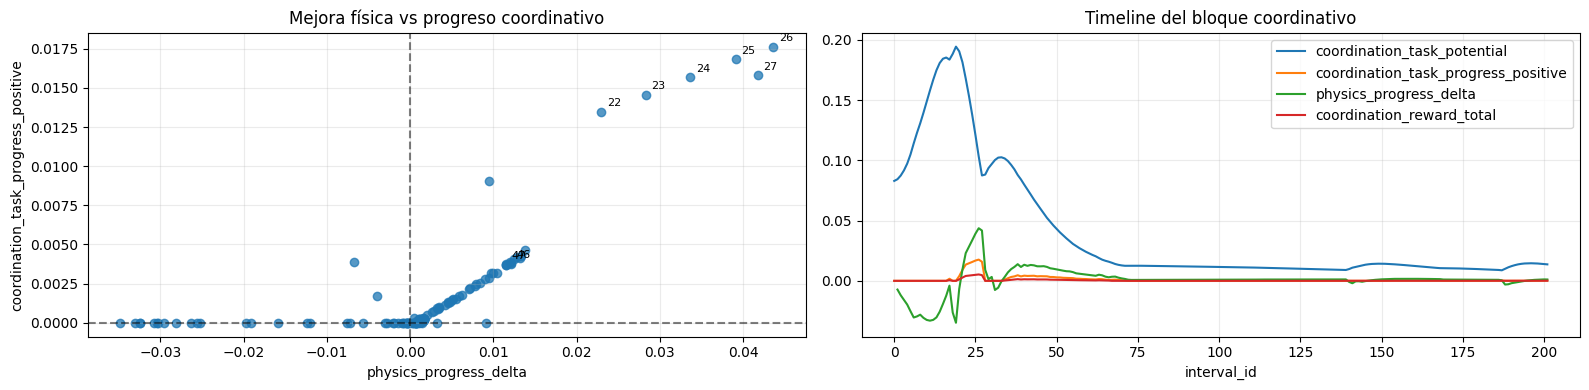

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].scatter(
    pd.to_numeric(coordination_audit_df['physics_progress_delta'], errors='coerce'),
    pd.to_numeric(coordination_audit_df['coordination_task_progress_positive'], errors='coerce'),
    alpha=0.75
)

axes[0].axvline(0.0, linestyle='--', color='black', alpha=0.5)
axes[0].axhline(0.0, linestyle='--', color='black', alpha=0.5)
axes[0].set_title('Mejora física vs progreso coordinativo')
axes[0].set_xlabel('physics_progress_delta')
axes[0].set_ylabel('coordination_task_progress_positive')

for _, row in coordination_candidate_intervals_df.head(8).iterrows():
    axes[0].annotate(
        str(int(row['interval_id'])),
        (row['physics_progress_delta'], row['coordination_task_progress_positive']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

plot_cols = [
    'coordination_task_potential',
    'coordination_task_progress_positive',
    'physics_progress_delta',
    'coordination_reward_total',
]

for col in plot_cols:
    if col in coordination_audit_df.columns:
        axes[1].plot(
            coordination_audit_df['interval_id'],
            pd.to_numeric(coordination_audit_df[col], errors='coerce'),
            label=col
        )

axes[1].set_title('Timeline del bloque coordinativo')
axes[1].set_xlabel('interval_id')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

### Subcaja G.1 — Tabla final del timeline coordinativo

Este bloque deja una vista tabular compacta con las principales variables del bloque coordinativo, junto con sus zonas lógicas y los lazos dominantes.

#### Qué contiene
- potencial, progreso y reward coordinativo;
- mejora física aproximada;
- lazo dominante por crédito;
- lazo dominante por mejora;
- clasificación lógica de progreso y crédito.

#### Qué se debería buscar
- Intervalos donde el progreso coordinativo no coincide con mejora física.
- Intervalos donde el lazo premiado no coincide con el lazo mejorado.
- Patrones repetidos de mismatch o progreso aparente.

In [220]:
coordination_timeline_view_cols = SHOW_COORD_TIMELINE_COLS.copy()

coordination_timeline_view_cols.extend([
    'physics_progress_delta',
    'physics_badness_score',
    'controller_stress_score',
    'dominant_credit_var',
    'dominant_credit_share',
    'dominant_improvement_var',
    'dominant_improvement_value',
    'coordination_progress_zone',
    'coordination_credit_zone',
    'coordination_vs_global_ratio_abs',
])

for var_obj in available_control_loop_var_objs:
    coordination_timeline_view_cols.extend([
        f'coordination_credit_raw_{var_obj}',
        f'coordination_credit_share_{var_obj}',
        f'extra_conditional_coordination_bonus_{var_obj}',
        f'error_improvement_{var_obj}',
    ])

coordination_timeline_view_cols = [
    c for c in coordination_timeline_view_cols
    if c in coordination_audit_df.columns
]

coordination_timeline_view_df = coordination_audit_df[coordination_timeline_view_cols].copy()
display(coordination_timeline_view_df)

,interval_id,interval_t_start_sec,interval_t_end_sec,coordination_task_potential,coordination_task_progress_delta,coordination_task_progress_positive,coordination_reward_total,physics_progress_delta,physics_badness_score,controller_stress_score,dominant_credit_var,dominant_credit_share,dominant_improvement_var,dominant_improvement_value,coordination_progress_zone,coordination_credit_zone,coordination_vs_global_ratio_abs,coordination_credit_raw_cart_position,coordination_credit_share_cart_position,extra_conditional_coordination_bonus_cart_position,error_improvement_cart_position,coordination_credit_raw_pendulum_angle,coordination_credit_share_pendulum_angle,extra_conditional_coordination_bonus_pendulum_angle,error_improvement_pendulum_angle
0,0,0.00,0.019,0.082938,0.000000,0.000000,0.000000,NaN,0.250104,0.088853,pendulum_angle,0.999970,NaN,NaN,NaN,credit_without_clear_loop_improvement,0.000000,3.938574e-08,0.000001,0.000000,NaN,0.034143,0.999970,0.000000,NaN
1,1,0.02,0.039,0.084361,-0.001423,0.000000,0.000000,-0.007244,0.257348,0.128202,pendulum_angle,0.999961,NaN,NaN,no_progress_both,credit_without_clear_loop_improvement,0.000000,7.811348e-07,0.000017,0.000000,-0.000117,0.045765,0.999961,0.000000,-0.007485
2,2,0.04,0.059,0.087380,-0.003020,0.000000,0.000000,-0.011981,0.269330,0.162506,pendulum_angle,0.999904,pendulum_angle,0.000196,no_progress_both,credit_matches_loop_improvement,0.000000,4.407068e-06,0.000079,0.000000,-0.000281,0.056115,0.999904,0.000000,0.000196
3,3,0.06,0.079,0.091697,-0.004317,0.000000,0.000000,-0.015822,0.285151,0.194865,pendulum_angle,0.999756,pendulum_angle,0.000579,no_progress_both,credit_matches_loop_improvement,0.000000,1.489798e-05,0.000229,0.000000,-0.000486,0.065123,0.999756,0.000000,0.000579
4,4,0.08,0.099,0.097331,-0.005633,0.000000,0.000000,-0.019718,0.304869,0.236738,pendulum_angle,0.999486,pendulum_angle,0.001145,no_progress_both,credit_matches_loop_improvement,0.000000,3.856547e-05,0.000501,0.000000,-0.000729,0.076972,0.999486,0.000000,0.001145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,197,3.94,3.959,0.014507,0.000076,0.000076,0.000023,0.000808,0.090402,0.288223,cart_position,0.602122,cart_position,0.000205,coord_progress_matches_physics,credit_matches_loop_improvement,0.004672,3.750081e-03,0.602122,0.000014,0.000205,0.002477,0.397718,0.000009,-0.000561
198,198,3.96,3.979,0.014381,0.000126,0.000126,0.000038,0.000952,0.089451,0.293597,cart_position,0.575742,cart_position,0.000188,coord_progress_matches_physics,credit_matches_loop_improvement,0.007598,3.724428e-03,0.575742,0.000022,0.000188,0.002743,0.424103,0.000016,-0.000527
199,199,3.98,3.999,0.014168,0.000213,0.000213,0.000064,0.001119,0.088331,0.291851,cart_position,0.571953,cart_position,0.000168,coord_progress_matches_physics,credit_matches_loop_improvement,0.012970,3.702303e-03,0.571953,0.000036,0.000168,0.002770,0.427893,0.000027,-0.000478
200,200,4.00,4.019,0.013932,0.000237,0.000237,0.000071,0.001179,0.087152,0.295684,cart_position,0.552808,cart_position,0.000148,coord_progress_matches_physics,credit_matches_loop_improvement,0.014164,3.683621e-03,0.552808,0.000039,0.000148,0.002979,0.447042,0.000032,-0.000434


### Subcaja G.2 — Configuración local para revisar un caso puntual del bloque coordinativo

Este bloque permite fijar un intervalo concreto para revisar localmente las señales step-level que alimentan el crédito coordinativo.

#### Significado de los parámetros
- **COORD_LOCAL_INTERVAL_ID**: intervalo puntual a revisar.
- **COORD_LOCAL_STEP_COLS**: señales step-level que se graficarán como contexto local.

#### Qué criterio seguir
Conviene elegir un intervalo candidato donde:
- haya progreso coordinativo sin mejora física;
- o haya mismatch entre lazo premiado y lazo mejorado.

In [221]:
# --- CONFIGURACIÓN CELDA ---
COORD_LOCAL_INTERVAL_ID = interval_ids_coordination_anomaly_candidates[0] if len(interval_ids_coordination_anomaly_candidates) > 0 else int(coordination_audit_df.iloc[0]['interval_id'])

COORD_LOCAL_STEP_COLS = []
COORD_LOCAL_STEP_COLS.extend([
    'pendulum_angle_raw',
    'cart_position_raw',
    'u_total',
    'delta_u_total',
])

COORD_LOCAL_STEP_COLS.extend([
    c for c in coordination_context_signals['error_cols']
    if c in step_timeline_df.columns
])

COORD_LOCAL_STEP_COLS.extend([
    c for c in coordination_context_signals['effort_cols']
    if c in step_timeline_df.columns
])

### Subcaja G.3 — Vista local del intervalo coordinativo candidato

Este bloque reconstruye una ventana step-level del intervalo elegido y la acompaña con una ficha técnica del bloque coordinativo para ese caso.

#### Qué se debería buscar
- Cómo era el contexto físico y de control dentro del intervalo.
- Qué señales alimentaban el crédito coordinativo.
- Si localmente parece razonable que el bloque haya asignado progreso o crédito de la forma observada.

In [222]:
coord_local_interval_row = interval_timeline_df.loc[
    interval_timeline_df['interval_id'] == COORD_LOCAL_INTERVAL_ID
].iloc[0]

coord_local_start_idx = int(coord_local_interval_row['interval_start_step_idx'])
coord_local_end_idx = int(coord_local_interval_row['interval_end_step_idx'])

coord_local_step_df = step_timeline_df.iloc[coord_local_start_idx:coord_local_end_idx + 1].copy()

coord_local_resume_df = coordination_audit_df.loc[
    coordination_audit_df['interval_id'] == COORD_LOCAL_INTERVAL_ID,
    [
        'interval_id',
        'coordination_task_potential',
        'coordination_task_progress_delta',
        'coordination_task_progress_positive',
        'coordination_reward_total',
        'physics_progress_delta',
        'dominant_credit_var',
        'dominant_credit_share',
        'dominant_improvement_var',
        'dominant_improvement_value',
        'coordination_progress_zone',
        'coordination_credit_zone',
    ] + [
        c for c in coordination_timeline_view_cols
        if c.startswith('coordination_credit_share_') or
           c.startswith('coordination_credit_raw_') or
           c.startswith('extra_conditional_coordination_bonus_') or
           c.startswith('error_improvement_')
    ]
].copy()

display(coord_local_resume_df)

,interval_id,coordination_task_potential,coordination_task_progress_delta,coordination_task_progress_positive,coordination_reward_total,physics_progress_delta,dominant_credit_var,dominant_credit_share,dominant_improvement_var,dominant_improvement_value,coordination_progress_zone,coordination_credit_zone,coordination_credit_raw_cart_position,coordination_credit_share_cart_position,extra_conditional_coordination_bonus_cart_position,error_improvement_cart_position,coordination_credit_raw_pendulum_angle,coordination_credit_share_pendulum_angle,extra_conditional_coordination_bonus_pendulum_angle,error_improvement_pendulum_angle
26,26,0.103283,0.017637,0.017637,0.005291,0.043659,pendulum_angle,0.923788,NaN,NaN,coord_progress_matches_physics,credit_without_clear_loop_improvement,0.007757,0.076202,0.000403,-0.002054,0.094044,0.923788,0.004888,-0.003982


### Subcaja G.4 — Visualización local de las señales que alimentan el crédito coordinativo

Este bloque muestra las señales step-level seleccionadas para contextualizar localmente el caso.

#### Qué muestra
- evolución física local;
- señales de error usadas por el bloque coordinativo;
- señales de esfuerzo usadas para calcular contribución correctiva.

#### Qué se debería buscar
- Si el patrón local justifica el progreso coordinativo observado.
- Si el lazo que recibió más crédito parece realmente estar corrigiendo mejor.
- Esta visualización no reemplaza la matemática interna del bloque, pero sí permite validar si su lectura parece razonable en contexto.

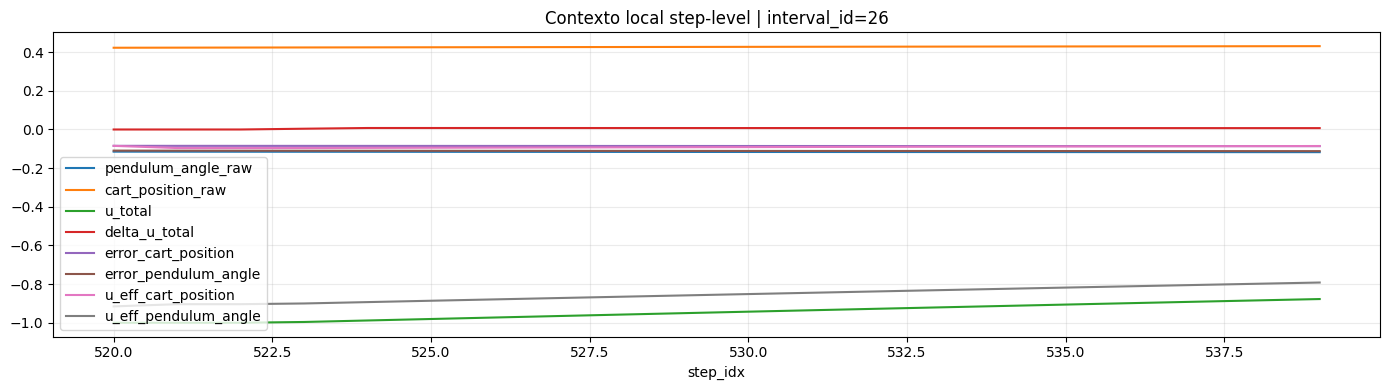

In [223]:
coord_local_plot_cols = [c for c in COORD_LOCAL_STEP_COLS if c in coord_local_step_df.columns]

fig, ax = plt.subplots(figsize=(14, 4))

for col in coord_local_plot_cols:
    ax.plot(
        coord_local_step_df['step_idx'],
        pd.to_numeric(coord_local_step_df[col], errors='coerce'),
        label=col
    )

ax.set_title(f'Contexto local step-level | interval_id={COORD_LOCAL_INTERVAL_ID}')
ax.set_xlabel('step_idx')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

- Esta caja deja auditado el reward coordinativo desde su lógica interna de progreso y reparto de crédito.
- La salida útil que heredan las siguientes cajas es:
  - `coordination_config_resume_df`
  - `coordination_inventory_df`
  - `coordination_audit_df`
  - `coordination_progress_summary_df`
  - `coordination_credit_summary_df`
  - `coordination_loop_summary_df`
  - `coordination_candidate_intervals_df`
  - `interval_ids_coordination_anomaly_candidates`
  - `coordination_timeline_view_df`
  - `coord_local_resume_df`
- Lo importante aquí es responder:
  - si el progreso coordinativo coincide con mejora real del sistema;
  - si el crédito se está llevando el lazo correcto;
  - o si el bloque coordinativo está premiando progreso aparente sin mejora física real.

## Caja 14 - Integración del reward global
- Esta caja reconstruye la suma total del reward y estudia cómo cada bloque participa en el resultado final.
- El objetivo no es mirar solo `global_interval_reward`, sino separar:
  - principal reward;
  - extra rewards;
  - reward coordinativo;
  - reward global reconstruido;
  - reward global persistido.
- Esta caja busca responder:
  - qué bloque domina realmente;
  - si algún bloque cambia el signo o magnitud del reward;
  - y si el reward global final sigue siendo coherente con la física observada.

### Subcaja A.1 — Inventario de bloques que componen el reward global

Este bloque identifica qué columnas necesarias para reconstruir el reward global están efectivamente disponibles en el episodio.

#### Qué familias se están inventariando
- reward principal;
- extras agregados;
- reward coordinativo;
- reward global persistido;
- reward por agente asignado;
- columnas auxiliares ya construidas en cajas anteriores.

#### Qué se debería buscar
- Si existen los cuatro elementos mínimos:
  - `principal_reward`;
  - `extra_total_all`;
  - `coordination_reward_total`;
  - `global_interval_reward`.
- Si el episodio también deja disponibles rewards por agente para enlazar luego con la señal final de aprendizaje.
- Esta subcaja no interpreta todavía los resultados; solo declara qué material real existe para reconstruir la integración.

In [224]:
global_component_inventory_df = pd.DataFrame([
    {'group': 'principal', 'cols': [c for c in ['principal_reward'] if c in interval_df.columns or c in principal_audit_df.columns]},
    {'group': 'extras', 'cols': [c for c in ['extra_total_all', 'principal_plus_extra'] if c in extra_audit_df.columns]},
    {'group': 'coordination', 'cols': [c for c in ['coordination_reward_total'] if c in interval_df.columns or c in coordination_audit_df.columns]},
    {'group': 'global', 'cols': [c for c in ['global_interval_reward'] if c in interval_df.columns]},
    {'group': 'assigned_agent_rewards', 'cols': interval_col_map['assigned_agent_rewards']},
    {'group': 'context_scores', 'cols': [c for c in ['physics_badness_score', 'controller_stress_score'] if c in coordination_audit_df.columns or c in extra_audit_df.columns]},
])

global_component_inventory_df['n_cols'] = global_component_inventory_df['cols'].map(len)
display(global_component_inventory_df)

,group,cols,n_cols
0,principal,[],0
1,extras,[extra_total_all],1
2,coordination,[coordination_reward_total],1
3,global,[global_interval_reward],1
4,assigned_agent_rewards,"[reward_kp_pendulum_angle, reward_ki_pendulum_...",6
5,context_scores,"[physics_badness_score, controller_stress_score]",2


### Subcaja A.2 — Inventario de rewards asignados a agentes

Este bloque deja explícitas las columnas de rewards asignados a agentes que están disponibles.

#### Por qué es importante
Aunque esta caja todavía se centra en el reward global, es útil declarar qué señales finales por agente existen, porque luego la Caja 15 deberá cerrar la cadena hasta aprendizaje.

#### Qué se debería buscar
- Cuántos rewards por agente existen.
- Si su cantidad coincide con la estructura multiagente de la corrida.
- Esta información no se interpreta todavía, pero deja visible la conexión entre composición global y asignación final.

In [225]:
global_assigned_reward_resume_df = pd.DataFrame([
    {'assigned_reward_col': col}
    for col in interval_col_map['assigned_agent_rewards']
])

display(global_assigned_reward_resume_df)

,assigned_reward_col
0,reward_kp_pendulum_angle
1,reward_ki_pendulum_angle
2,reward_kd_pendulum_angle
3,reward_kp_cart_position
4,reward_ki_cart_position
5,reward_kd_cart_position


### Subcaja B — Configuración analítica de la integración global

Este bloque define qué intervalos se priorizarán y qué umbrales se usarán para clasificar la coherencia del reward global frente a la física.

#### Significado de los parámetros
- **GLOBAL_AUDIT_INTERVAL_IDS**: intervalos a auditar con prioridad.
- **BAD_PHYSICS_THRESHOLD**: umbral para considerar que la física del intervalo es mala.
- **GOOD_GLOBAL_REWARD_THRESHOLD**: umbral para considerar que el reward global luce relativamente bueno.
- **TOP_N_GLOBAL_ANOMALIES**: cantidad máxima de intervalos sospechosos que se mostrarán.
- **SHOW_GLOBAL_TIMELINE_COLS**: columnas base que se incluirán en la vista tabular final.

#### Qué criterio se está usando
La caja compara:
- reward principal;
- efecto extra;
- efecto coordinativo;
- reward global persistido;
- contexto físico del intervalo.

La idea es detectar si el reward global final resulta coherente o si queda dominado por componentes laterales que alteran la lectura principal.

In [226]:
# --- CONFIGURACIÓN CELDA ---
GLOBAL_AUDIT_INTERVAL_IDS = sorted(set(
    interval_ids_physical_anomaly_candidates[:6] +
    interval_ids_controller_anomaly_candidates[:6] +
    interval_ids_extra_anomaly_candidates[:6] +
    interval_ids_coordination_anomaly_candidates[:6]
))

BAD_PHYSICS_THRESHOLD = 0.55
GOOD_GLOBAL_REWARD_THRESHOLD = 0.55

TOP_N_GLOBAL_ANOMALIES = 20

SHOW_GLOBAL_TIMELINE_COLS = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'principal_reward',
    'extra_total_all',
    'coordination_reward_total',
    'global_interval_reward',
]

NameError: name 'interval_ids_extra_anomaly_candidates' is not defined

### Subcaja C.1 — Reconstrucción de la composición global del reward

Este bloque construye la base analítica principal de la caja, reuniendo en una sola tabla los tres bloques del reward y el contexto físico.

#### Qué se construye aquí
- reward principal;
- bloque extra total;
- bloque coordinativo total;
- reward global reconstruido;
- reward global persistido;
- gap de reconstrucción;
- peso relativo de cada bloque dentro de la composición;
- bloque dominante;
- tipo de transición de signo durante la composición;
- zona lógica del reward global respecto a la física.

#### Qué significa cada variable nueva
- **reconstructed_global_reward**: suma explícita de principal + extras + coordinación.
- **global_reconstruction_gap**: diferencia entre el reward global reconstruido y el reward global persistido.
- **principal_block_abs / extra_block_abs / coordination_block_abs**: magnitud absoluta de cada bloque.
- **global_component_abs_total**: magnitud absoluta total de la composición.
- **principal_block_weight / extra_block_weight / coordination_block_weight**: peso relativo de cada bloque.
- **dominant_block**: bloque que más pesa en el intervalo.
- **composition_transition_zone**: tipo de cambio de signo al pasar desde principal a principal+extra y luego a global.
- **global_reward_goodness_score**: reward global llevado a escala normalizada.
- **global_integration_zone**: clasificación lógica del reward global respecto a la física del intervalo.

#### Qué se debería buscar
- Si la reconstrucción coincide con lo persistido.
- Si el reward global sigue dominado por el principal reward o si extras/coordinación toman control.
- Si el reward global final parece demasiado bueno o demasiado malo para la física observada.

In [227]:
global_integration_df = interval_timeline_df[['interval_id', 'interval_t_start_sec', 'interval_t_end_sec', 'global_interval_reward']].copy()

global_integration_df = global_integration_df.merge(
    principal_audit_df[['interval_id', 'principal_reward']],
    on='interval_id',
    how='left'
)

global_integration_df = global_integration_df.merge(
    extra_audit_df[['interval_id', 'extra_total_all', 'principal_plus_extra', 'extra_effect_zone', 'extra_dominant_family']],
    on='interval_id',
    how='left'
)

global_integration_df = global_integration_df.merge(
    coordination_audit_df[['interval_id', 'coordination_reward_total', 'coordination_progress_zone', 'coordination_credit_zone']],
    on='interval_id',
    how='left'
)

global_integration_df = global_integration_df.merge(
    physical_reward_audit_df[['interval_id', 'physics_badness_score', 'reward_goodness_score', 'physical_reward_zone']],
    on='interval_id',
    how='left'
)

global_integration_df = global_integration_df.merge(
    controller_audit_df[['interval_id', 'controller_stress_score', 'controller_reward_zone']],
    on='interval_id',
    how='left'
)

global_integration_df['reconstructed_global_reward'] = (
    pd.to_numeric(global_integration_df['principal_reward'], errors='coerce').fillna(0.0) +
    pd.to_numeric(global_integration_df['extra_total_all'], errors='coerce').fillna(0.0) +
    pd.to_numeric(global_integration_df['coordination_reward_total'], errors='coerce').fillna(0.0)
)

global_integration_df['global_reconstruction_gap'] = (
    pd.to_numeric(global_integration_df['reconstructed_global_reward'], errors='coerce') -
    pd.to_numeric(global_integration_df['global_interval_reward'], errors='coerce')
)

global_integration_df['principal_block_abs'] = pd.to_numeric(global_integration_df['principal_reward'], errors='coerce').abs()
global_integration_df['extra_block_abs'] = pd.to_numeric(global_integration_df['extra_total_all'], errors='coerce').abs()
global_integration_df['coordination_block_abs'] = pd.to_numeric(global_integration_df['coordination_reward_total'], errors='coerce').abs()

global_integration_df['global_component_abs_total'] = (
    global_integration_df['principal_block_abs'].fillna(0.0) +
    global_integration_df['extra_block_abs'].fillna(0.0) +
    global_integration_df['coordination_block_abs'].fillna(0.0)
)

global_integration_df['principal_block_weight'] = safe_ratio_series(
    global_integration_df['principal_block_abs'],
    global_integration_df['global_component_abs_total']
)

global_integration_df['extra_block_weight'] = safe_ratio_series(
    global_integration_df['extra_block_abs'],
    global_integration_df['global_component_abs_total']
)

global_integration_df['coordination_block_weight'] = safe_ratio_series(
    global_integration_df['coordination_block_abs'],
    global_integration_df['global_component_abs_total']
)

dominant_block_df = global_integration_df.apply(
    lambda row: dominant_block_from_row(
        row,
        {
            'principal': 'principal_block_abs',
            'extras': 'extra_block_abs',
            'coordination': 'coordination_block_abs',
        }
    ),
    axis=1
)

global_integration_df = pd.concat([global_integration_df, dominant_block_df], axis=1)

global_integration_df['composition_transition_zone'] = global_integration_df.apply(
    lambda row: classify_composition_transition(
        principal_reward=row['principal_reward'],
        principal_plus_extra=row['principal_plus_extra'],
        global_reward=row['global_interval_reward']
    ),
    axis=1
)

global_integration_df['global_reward_goodness_score'] = minmax_01(
    pd.to_numeric(global_integration_df['global_interval_reward'], errors='coerce')
)

global_integration_df['global_integration_zone'] = global_integration_df.apply(
    lambda row: classify_global_integration_zone(
        physics_badness=row['physics_badness_score'],
        global_reward_goodness=row['global_reward_goodness_score'],
        bad_thr=BAD_PHYSICS_THRESHOLD,
        good_thr=GOOD_GLOBAL_REWARD_THRESHOLD
    ),
    axis=1
)

KeyError: "['principal_reward'] not in index"

### Subcaja D.1 — Resumen por bloque de la composición global

Este bloque resume cuánto pesa, en promedio, cada bloque dentro del reward global.

#### Qué representa
- magnitud media absoluta por bloque;
- peso medio relativo;
- cuántas veces cada bloque aparece como dominante.

#### Qué se debería buscar
- Si el principal reward sigue siendo el bloque dominante.
- Si los extras o la coordinación adquieren demasiado peso en el episodio.
- Si un bloque lateral domina con frecuencia, eso puede explicar anomalías observadas en el reward global.

In [228]:
global_block_summary_df = pd.DataFrame([
    {
        'block': 'principal',
        'abs_mean': float(pd.to_numeric(global_integration_df['principal_block_abs'], errors='coerce').mean()),
        'weight_mean': float(pd.to_numeric(global_integration_df['principal_block_weight'], errors='coerce').mean()),
        'dominant_count': int((global_integration_df['dominant_block'] == 'principal').sum()),
    },
    {
        'block': 'extras',
        'abs_mean': float(pd.to_numeric(global_integration_df['extra_block_abs'], errors='coerce').mean()),
        'weight_mean': float(pd.to_numeric(global_integration_df['extra_block_weight'], errors='coerce').mean()),
        'dominant_count': int((global_integration_df['dominant_block'] == 'extras').sum()),
    },
    {
        'block': 'coordination',
        'abs_mean': float(pd.to_numeric(global_integration_df['coordination_block_abs'], errors='coerce').mean()),
        'weight_mean': float(pd.to_numeric(global_integration_df['coordination_block_weight'], errors='coerce').mean()),
        'dominant_count': int((global_integration_df['dominant_block'] == 'coordination').sum()),
    },
])

display(global_block_summary_df)

KeyError: 'principal_block_abs'

### Subcaja D.2 — Resumen por zona lógica del reward global

Este bloque resume cómo se comporta el reward global final según su relación con la física.

#### Qué representa
- cantidad de intervalos por zona;
- magnitud media de cada bloque;
- weight relativo medio de extras y coordinación;
- gap medio de reconstrucción.

#### Qué se debería buscar
- Si las zonas anómalas del reward global coinciden con mayor peso de extras o coordinación.
- Si las zonas coherentes siguen dominadas por el principal reward.
- Si la reconstrucción global es estable o si aparecen diferencias numéricas inesperadas.

In [229]:
global_zone_summary_df = (
    global_integration_df
    .groupby('global_integration_zone')
    .agg(
        n_intervals=('interval_id', 'count'),
        principal_block_weight_mean=('principal_block_weight', 'mean'),
        extra_block_weight_mean=('extra_block_weight', 'mean'),
        coordination_block_weight_mean=('coordination_block_weight', 'mean'),
        global_reconstruction_gap_mean_abs=('global_reconstruction_gap', lambda s: pd.to_numeric(s, errors='coerce').abs().mean()),
    )
    .reset_index()
    .sort_values('n_intervals', ascending=False)
)

display(global_zone_summary_df)

KeyError: 'global_integration_zone'

### Subcaja D.3 — Resumen de transiciones de signo durante la composición

Este bloque resume cuántas veces la composición del reward cambia de signo al pasar por extras o coordinación.

#### Qué representa
- casos sin cambio de signo;
- casos donde los extras cambian el signo;
- casos donde la coordinación cambia el signo;
- casos donde ambos bloques alteran la dirección de la señal.

#### Qué se debería buscar
- Si extras o coordinación solo ajustan magnitud o si realmente cambian la interpretación del reward.
- Si los cambios de signo aparecen justo en intervalos físicamente problemáticos.
- Esta tabla es clave para detectar cuando un bloque lateral reescribe por completo la lectura del principal reward.

In [230]:
composition_transition_summary_df = (
    global_integration_df
    .groupby('composition_transition_zone')
    .agg(
        n_intervals=('interval_id', 'count'),
        principal_block_weight_mean=('principal_block_weight', 'mean'),
        extra_block_weight_mean=('extra_block_weight', 'mean'),
        coordination_block_weight_mean=('coordination_block_weight', 'mean'),
    )
    .reset_index()
    .sort_values('n_intervals', ascending=False)
)

display(composition_transition_summary_df)

KeyError: 'composition_transition_zone'

### Subcaja E.1 — Selección de intervalos donde la composición global parece más extraña

Este bloque prioriza los intervalos donde la composición del reward global parece más sospechosa.

#### Qué criterio se usa
Se priorizan intervalos donde:
- el reward global final parece demasiado bueno o demasiado malo para la física;
- extras o coordinación tienen peso relevante;
- hay cambios de signo durante la composición;
- o el bloque dominante no es el principal reward.

#### Qué se debería buscar
- Qué intervalos quedan más afectados por bloques laterales.
- Si esos intervalos coinciden con anomalías ya detectadas en cajas anteriores.
- Esta salida deja una lista concreta de casos prioritarios para enlazar con la asignación a agentes y con la ventana forense.

In [ ]:
global_candidate_intervals_df = (
    global_integration_df.loc[
        global_integration_df['global_integration_zone'].isin([
            'global_reward_too_good_for_physics',
            'global_reward_too_bad_for_physics',
        ]) |
        global_integration_df['composition_transition_zone'].isin([
            'extra_flip_sign',
            'coordination_flip_sign',
            'extra_and_coordination_flip_sign',
        ]) |
        (global_integration_df['dominant_block'] != 'principal'),
        [
            'interval_id',
            'interval_t_start_sec',
            'interval_t_end_sec',
            'principal_reward',
            'extra_total_all',
            'coordination_reward_total',
            'reconstructed_global_reward',
            'global_interval_reward',
            'global_reconstruction_gap',
            'principal_block_weight',
            'extra_block_weight',
            'coordination_block_weight',
            'dominant_block',
            'composition_transition_zone',
            'global_integration_zone',
            'physics_badness_score',
            'global_reward_goodness_score',
        ]
    ]
    .sort_values(
        ['extra_block_weight', 'coordination_block_weight', 'principal_block_weight'],
        ascending=[False, False, True]
    )
    .head(TOP_N_GLOBAL_ANOMALIES)
    .reset_index(drop=True)
)

display(global_candidate_intervals_df)

interval_ids_global_anomaly_candidates = global_candidate_intervals_df['interval_id'].tolist()

### Subcaja F.1 — Visualización de la composición del reward global

Este bloque muestra dos vistas complementarias:

1. **Scatter física versus reward global**  
   Permite ver si el reward final sigue siendo coherente con la física una vez compuestos todos los bloques.

2. **Timeline de composición**  
   Permite seguir cómo evolucionan:
   - principal reward;
   - principal + extras;
   - reward global final.

#### Cómo interpretar el scatter
- Un punto hacia la derecha indica física relativamente peor.
- Un punto hacia arriba indica reward global relativamente mejor.
- Puntos en física mala con reward global alto son señales claras de alerta.

#### Cómo interpretar el timeline de composición
- Si `principal_reward`, `principal_plus_extra` y `global_interval_reward` se mantienen cerca, los bloques laterales están corrigiendo poco.
- Si se separan mucho, extras o coordinación están modificando de forma fuerte la señal.
- Si hay cambios de signo entre etapas, la composición está alterando la interpretación del intervalo.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].scatter(
    pd.to_numeric(global_integration_df['physics_badness_score'], errors='coerce'),
    pd.to_numeric(global_integration_df['global_reward_goodness_score'], errors='coerce'),
    alpha=0.75
)

axes[0].axvline(BAD_PHYSICS_THRESHOLD, linestyle='--', color='black', alpha=0.5)
axes[0].axhline(GOOD_GLOBAL_REWARD_THRESHOLD, linestyle='--', color='black', alpha=0.5)
axes[0].set_title('Física vs reward global')
axes[0].set_xlabel('physics_badness_score')
axes[0].set_ylabel('global_reward_goodness_score')

for _, row in global_candidate_intervals_df.head(8).iterrows():
    axes[0].annotate(
        str(int(row['interval_id'])),
        (row['physics_badness_score'], row['global_reward_goodness_score']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8
    )

for col in ['principal_reward', 'principal_plus_extra', 'global_interval_reward']:
    if col in global_integration_df.columns:
        axes[1].plot(
            global_integration_df['interval_id'],
            pd.to_numeric(global_integration_df[col], errors='coerce'),
            label=col
        )

axes[1].set_title('Timeline de composición del reward')
axes[1].set_xlabel('interval_id')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

### Subcaja G.1 — Tabla final del timeline del reward global

Este bloque deja una vista tabular compacta con los principales resultados de la integración global.

#### Qué contiene
- reward principal;
- extras;
- coordinación;
- reward global reconstruido;
- reward global persistido;
- pesos relativos de cada bloque;
- bloque dominante;
- tipo de transición de signo;
- zona lógica del reward global.

#### Qué se debería buscar
- Qué bloque domina cada intervalo.
- Si hay gaps entre reconstrucción y persistencia.
- Si las zonas anómalas del reward global coinciden con peso alto de extras o coordinación.

In [ ]:
global_timeline_view_cols = SHOW_GLOBAL_TIMELINE_COLS.copy()

global_timeline_view_cols.extend([
    'reconstructed_global_reward',
    'global_reconstruction_gap',
    'principal_block_weight',
    'extra_block_weight',
    'coordination_block_weight',
    'dominant_block',
    'dominant_block_abs_value',
    'composition_transition_zone',
    'global_integration_zone',
    'physics_badness_score',
    'controller_stress_score',
    'extra_effect_zone',
    'coordination_progress_zone',
    'coordination_credit_zone',
])

global_timeline_view_cols = [c for c in global_timeline_view_cols if c in global_integration_df.columns]

global_timeline_view_df = global_integration_df[global_timeline_view_cols].copy()
display(global_timeline_view_df)

### Subcaja G.2 — Configuración local para revisar un caso puntual de integración global

Este bloque permite fijar un intervalo concreto para revisar localmente el caso más sospechoso desde la perspectiva del reward global.

#### Significado de los parámetros
- **GLOBAL_LOCAL_INTERVAL_ID**: intervalo puntual a revisar.
- **GLOBAL_LOCAL_STEP_COLS**: señales step-level que se graficarán como contexto local.

#### Qué criterio seguir
Conviene elegir un intervalo donde:
- el reward global parece demasiado bueno o demasiado malo;
- extras o coordinación tienen mucho peso;
- o donde hubo cambio de signo durante la composición.

In [ ]:
# --- CONFIGURACIÓN CELDA ---
GLOBAL_LOCAL_INTERVAL_ID = interval_ids_global_anomaly_candidates[0] if len(interval_ids_global_anomaly_candidates) > 0 else int(global_integration_df.iloc[0]['interval_id'])

GLOBAL_LOCAL_STEP_COLS = [
    'pendulum_angle_raw',
    'cart_position_raw',
    'u_total',
    'delta_u_total',
    'is_saturated_global',
]

for var_obj in available_control_loop_var_objs:
    GLOBAL_LOCAL_STEP_COLS.extend([
        f'error_{var_obj}',
        f'u_eff_{var_obj}',
        f'delta_u_eff_{var_obj}',
    ])

### Subcaja G.3 — Vista local del intervalo global candidato

Este bloque reconstruye una ventana step-level del intervalo elegido y la acompaña con una ficha técnica de la composición global para ese caso.

#### Qué se debería buscar
- Cómo era el contexto físico y de control dentro del intervalo.
- Qué tan importante fue cada bloque del reward.
- Si localmente parece razonable que el reward global final haya tomado el valor observado.
- Esta salida deja un caso concreto listo para enlazar con la asignación a agentes o con la ventana forense completa.

In [ ]:
global_local_interval_row = interval_timeline_df.loc[
    interval_timeline_df['interval_id'] == GLOBAL_LOCAL_INTERVAL_ID
].iloc[0]

global_local_start_idx = int(global_local_interval_row['interval_start_step_idx'])
global_local_end_idx = int(global_local_interval_row['interval_end_step_idx'])

global_local_step_df = step_timeline_df.iloc[global_local_start_idx:global_local_end_idx + 1].copy()

global_local_resume_df = global_integration_df.loc[
    global_integration_df['interval_id'] == GLOBAL_LOCAL_INTERVAL_ID,
    [
        'interval_id',
        'principal_reward',
        'extra_total_all',
        'coordination_reward_total',
        'reconstructed_global_reward',
        'global_interval_reward',
        'global_reconstruction_gap',
        'principal_block_weight',
        'extra_block_weight',
        'coordination_block_weight',
        'dominant_block',
        'composition_transition_zone',
        'global_integration_zone',
        'physics_badness_score',
        'controller_stress_score',
        'extra_effect_zone',
        'coordination_progress_zone',
        'coordination_credit_zone',
    ]
].copy()

display(global_local_resume_df)

### Subcaja G.4 — Visualización local del contexto step-level del intervalo elegido

Este bloque muestra las señales step-level seleccionadas para contextualizar localmente el caso.

#### Qué muestra
- evolución física local;
- evolución del control local;
- señales de esfuerzo o saturación, si están disponibles.

#### Qué se debería buscar
- Si el contexto local justifica o no el reward global final.
- Si el intervalo parecía realmente merecer un ajuste fuerte desde extras o coordinación.
- Esta visualización no reconstruye toda la matemática de la composición, pero sí permite juzgar si el resultado final parece razonable en contexto.

In [ ]:
global_local_plot_cols = [c for c in GLOBAL_LOCAL_STEP_COLS if c in global_local_step_df.columns]

fig, ax = plt.subplots(figsize=(14, 4))

for col in global_local_plot_cols:
    ax.plot(
        global_local_step_df['step_idx'],
        pd.to_numeric(global_local_step_df[col], errors='coerce'),
        label=col
    )

ax.set_title(f'Contexto local step-level | interval_id={GLOBAL_LOCAL_INTERVAL_ID}')
ax.set_xlabel('step_idx')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

- Esta caja deja reconstruida la integración total del reward.
- La salida útil que heredan las siguientes cajas es:
  - `global_component_inventory_df`
  - `global_assigned_reward_resume_df`
  - `global_integration_df`
  - `global_block_summary_df`
  - `global_zone_summary_df`
  - `composition_transition_summary_df`
  - `global_candidate_intervals_df`
  - `interval_ids_global_anomaly_candidates`
  - `global_timeline_view_df`
  - `global_local_resume_df`
- Lo importante aquí es responder:
  - si el reward global está dominado por el principal reward o por ajustes laterales;
  - qué bloque explica los intervalos más extraños;
  - y si la composición final sigue siendo coherente con el estado físico real del sistema.

## Caja 15 - Reward asignado a agentes y señal de aprendizaje
- Esta caja cierra la cadena causal hasta RL.
- El objetivo no es mirar solo el reward global del intervalo, sino comparar:
  - reward global;
  - reward asignado a cada agente;
  - reward principal y bloques laterales que pueden estar influyéndolo;
  - `td_error_*` y `q_value_*` como respuesta del aprendizaje.
- Esta caja busca responder:
  - si el agente correcto está siendo premiado o castigado;
  - si el `reward_approach` configurado se refleja realmente en la señal asignada;
  - y si la señal final de aprendizaje conserva la lógica física del intervalo.

### Subcaja A.1 — Configuración de asignación de reward y mapeo agente-lazo

Este bloque muestra cuál fue el `reward_approach` real de la corrida y cómo se mapea cada agente al lazo que controla.

#### Qué representa
- **reward_approach**: estrategia de asignación de reward usada por `RewardCalculatorBase`.
- **agent_to_var_obj_map**: relación entre cada agente y el lazo físico/controlado con el que se asocia.

#### Por qué es importante
La interpretación de la señal asignada depende totalmente del enfoque configurado:
- en `unique_for_all_reward`, todos los agentes deberían recibir la misma recompensa global;
- en `controller_reward`, cada agente debería recibir la señal asociada a su lazo;
- en `individual_reward`, la señal puede diferir aún más según pesos individuales.

#### Qué se debería buscar
- Qué tipo de asignación fue usada.
- Qué agente corresponde a cada lazo.
- Esta información es la base para juzgar después si la señal asignada es coherente o no.

In [ ]:
reward_approach = get_reward_approach_from_metadata(run_metadata)
agent_to_var_obj_map = build_agent_to_var_obj_map_from_metadata(run_metadata)

reward_assignment_config_df = pd.DataFrame([
    {'field': 'reward_approach', 'value': reward_approach},
    {'field': 'agent_to_var_obj_map', 'value': agent_to_var_obj_map},
])

display(reward_assignment_config_df)

### Subcaja A.2 — Inventario de columnas de reward asignado y aprendizaje

Este bloque identifica qué columnas efectivamente disponibles permiten auditar la señal final que recibe cada agente.

#### Qué familias se están inventariando
- reward asignado por agente;
- `td_error_*`;
- `q_value_*`;
- métricas agregadas del aprendizaje, si existen.

#### Qué se debería buscar
- Si para cada agente existe su reward asignado.
- Si para cada agente existe `td_error_*` y `q_value_*`.
- Si la corrida dejó suficiente información para cerrar la cadena causal hasta el update.

In [ ]:
assigned_reward_cols = interval_col_map['assigned_agent_rewards']
td_error_cols = [c for c in interval_df.columns if c.startswith('td_error_')]
q_value_cols = [c for c in interval_df.columns if c.startswith('q_value_')]
learning_stat_cols = interval_col_map['learning_stats']
learning_param_cols = interval_col_map['learning_params']

assigned_signal_inventory_df = pd.DataFrame([
    {'group': 'assigned_reward_cols', 'n_cols': len(assigned_reward_cols), 'cols': assigned_reward_cols},
    {'group': 'td_error_cols', 'n_cols': len(td_error_cols), 'cols': td_error_cols},
    {'group': 'q_value_cols', 'n_cols': len(q_value_cols), 'cols': q_value_cols},
    {'group': 'learning_stat_cols', 'n_cols': len(learning_stat_cols), 'cols': learning_stat_cols},
    {'group': 'learning_param_cols', 'n_cols': len(learning_param_cols), 'cols': learning_param_cols},
])

display(assigned_signal_inventory_df)

### Subcaja B — Configuración analítica de la señal asignada y del aprendizaje

Este bloque define qué intervalos se priorizarán y qué columnas se usarán para la lectura final de la señal por agente.

#### Significado de los parámetros
- **LEARN_AUDIT_INTERVAL_IDS**: intervalos a auditar con prioridad.
- **TOP_N_LEARN_ANOMALIES**: cantidad máxima de intervalos sospechosos que se mostrarán.
- **SHOW_LEARN_TIMELINE_COLS**: columnas base que se incluirán en la vista tabular final.

#### Qué criterio se está usando
La caja compara:
- reward global;
- reward asignado por agente;
- coherencia de signo y magnitud;
- dispersión de reward entre agentes;
- `td_error` y `q_value` resultantes.

La idea es cerrar la auditoría verificando si la señal que finalmente entra al aprendizaje conserva o no la lógica del intervalo.

In [ ]:
# --- CONFIGURACIÓN CELDA ---
LEARN_AUDIT_INTERVAL_IDS = sorted(set(
    interval_ids_physical_anomaly_candidates[:6] +
    interval_ids_controller_anomaly_candidates[:6] +
    interval_ids_extra_anomaly_candidates[:6] +
    interval_ids_coordination_anomaly_candidates[:6] +
    interval_ids_global_anomaly_candidates[:6]
))

TOP_N_LEARN_ANOMALIES = 20

SHOW_LEARN_TIMELINE_COLS = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'global_interval_reward',
    'principal_reward',
    'extra_total_all',
    'coordination_reward_total',
]

### Subcaja C.1 — Construcción de la base analítica de reward asignado y update

Este bloque construye la base principal de la caja, integrando en una sola tabla:

- reward global;
- reward principal, extras y coordinación;
- reward asignado por agente;
- `td_error_*` por agente;
- `q_value_*` por agente;
- contexto físico y de control ya auditado.

#### Qué se construye aquí
- tablas row-wise por agente;
- spread de rewards entre agentes;
- spread de `td_error` entre agentes;
- agente dominante en reward asignado;
- agente dominante en `td_error`;
- clasificación lógica de la señal asignada.

#### Qué significa cada variable nueva
- **assigned_reward_spread**: diferencia entre el reward máximo y mínimo recibido entre agentes en un mismo intervalo.
- **td_error_spread**: diferencia entre el `td_error` máximo y mínimo entre agentes.
- **dominant_reward_agent**: agente que recibió la señal de mayor magnitud.
- **dominant_td_error_agent**: agente cuyo update fue de mayor magnitud.
- **assigned_zone_<agent>**: clasificación lógica del reward asignado a ese agente respecto al reward global.

#### Qué se debería buscar
- Si todos los agentes reciben la misma señal cuando deberían.
- Si la dispersión entre agentes es razonable o excesiva.
- Si el agente que más reward recibe coincide con el lazo que parecía más influyente.
- Si la señal de update parece coherente con la señal de reward recibida.

In [ ]:
learn_signal_df = global_integration_df.copy()

agent_reward_col_map = {}
agent_td_col_map = {}
agent_q_col_map = {}

for agent_name in agent_to_var_obj_map.keys():
    reward_col = f'reward_{agent_name}'
    td_col = f'td_error_{agent_name}'
    q_col = f'q_value_{agent_name}'

    if reward_col in interval_df.columns:
        agent_reward_col_map[agent_name] = reward_col
    if td_col in interval_df.columns:
        agent_td_col_map[agent_name] = td_col
    if q_col in interval_df.columns:
        agent_q_col_map[agent_name] = q_col

selected_agent_cols = list(set(
    list(agent_reward_col_map.values()) +
    list(agent_td_col_map.values()) +
    list(agent_q_col_map.values()) +
    learning_stat_cols +
    learning_param_cols
))

learn_signal_df = learn_signal_df.merge(
    interval_df[['interval_id'] + selected_agent_cols],
    on='interval_id',
    how='left'
)

reward_spread_cols = list(agent_reward_col_map.values())
td_spread_cols = list(agent_td_col_map.values())

learn_signal_df['assigned_reward_spread'] = row_spread(learn_signal_df, reward_spread_cols)
learn_signal_df['td_error_spread'] = row_spread(learn_signal_df, td_spread_cols)

dominant_reward_agent_df = learn_signal_df.apply(
    lambda row: dominant_agent_from_row(row, agent_reward_col_map, use_abs=True),
    axis=1
)
dominant_reward_agent_df.columns = ['dominant_reward_agent', 'dominant_reward_value']
learn_signal_df = pd.concat([learn_signal_df, dominant_reward_agent_df], axis=1)

dominant_td_agent_df = learn_signal_df.apply(
    lambda row: dominant_agent_from_row(row, agent_td_col_map, use_abs=True),
    axis=1
)
dominant_td_agent_df.columns = ['dominant_td_error_agent', 'dominant_td_error_value']
learn_signal_df = pd.concat([learn_signal_df, dominant_td_agent_df], axis=1)

for agent_name, reward_col in agent_reward_col_map.items():
    learn_signal_df[f'assigned_zone_{agent_name}'] = learn_signal_df.apply(
        lambda row: classify_assigned_reward_zone(
            global_reward=row['global_interval_reward'],
            assigned_reward=row[reward_col],
            reward_approach=reward_approach
        ),
        axis=1
    )

### Subcaja D.1 — Resumen global de rewards asignados por agente

Este bloque resume cuánto reward recibe, en promedio, cada agente y cómo se distribuye esa señal a lo largo del episodio.

#### Qué representa
- reward medio por agente;
- reward absoluto medio por agente;
- cantidad de intervalos con reward positivo, negativo o neutro;
- relación media con el reward global.

#### Qué se debería buscar
- Si la asignación entre agentes parece simétrica o muy desigual.
- Si la señal asignada coincide con lo esperable según el `reward_approach`.
- Si un agente recibe castigos o premios sistemáticamente más intensos que otros.

In [ ]:
assigned_reward_summary_rows = []

for agent_name, reward_col in agent_reward_col_map.items():
    assigned_reward_summary_rows.append({
        'agent_name': agent_name,
        'var_obj': agent_to_var_obj_map[agent_name],
        'reward_mean': float(pd.to_numeric(learn_signal_df[reward_col], errors='coerce').mean()),
        'reward_abs_mean': float(pd.to_numeric(learn_signal_df[reward_col], errors='coerce').abs().mean()),
        'positive_count': int((pd.to_numeric(learn_signal_df[reward_col], errors='coerce') > 0).sum()),
        'negative_count': int((pd.to_numeric(learn_signal_df[reward_col], errors='coerce') < 0).sum()),
        'neutral_count': int((pd.to_numeric(learn_signal_df[reward_col], errors='coerce') == 0).sum()),
        'corr_with_global_reward': float(
            pd.to_numeric(learn_signal_df[reward_col], errors='coerce').corr(
                pd.to_numeric(learn_signal_df['global_interval_reward'], errors='coerce')
            )
        ),
    })

assigned_reward_summary_df = pd.DataFrame(assigned_reward_summary_rows)
display(assigned_reward_summary_df)

### Subcaja D.2 — Resumen global de la señal de update

Este bloque resume cómo reacciona el update del agente a la señal recibida.

#### Qué representa
- `td_error` medio y absoluto medio por agente;
- `q_value` medio y absoluto medio por agente;
- correlación entre reward asignado y `td_error`;
- correlación entre reward asignado y `q_value`.

#### Qué se debería buscar
- Si el update refleja o no la señal recibida.
- Si un agente muestra mucha sensibilidad o muy poca reacción frente al reward.
- Si existen diferencias estructurales entre agentes en la forma en que aprenden.

In [ ]:
learning_update_summary_rows = []

for agent_name in agent_to_var_obj_map.keys():
    reward_col = agent_reward_col_map.get(agent_name)
    td_col = agent_td_col_map.get(agent_name)
    q_col = agent_q_col_map.get(agent_name)

    learning_update_summary_rows.append({
        'agent_name': agent_name,
        'var_obj': agent_to_var_obj_map[agent_name],
        'td_error_mean': float(pd.to_numeric(learn_signal_df[td_col], errors='coerce').mean()) if td_col else np.nan,
        'td_error_abs_mean': float(pd.to_numeric(learn_signal_df[td_col], errors='coerce').abs().mean()) if td_col else np.nan,
        'q_value_mean': float(pd.to_numeric(learn_signal_df[q_col], errors='coerce').mean()) if q_col else np.nan,
        'q_value_abs_mean': float(pd.to_numeric(learn_signal_df[q_col], errors='coerce').abs().mean()) if q_col else np.nan,
        'corr_reward_vs_td_error': float(
            pd.to_numeric(learn_signal_df[reward_col], errors='coerce').corr(
                pd.to_numeric(learn_signal_df[td_col], errors='coerce')
            )
        ) if reward_col and td_col else np.nan,
        'corr_reward_vs_q_value': float(
            pd.to_numeric(learn_signal_df[reward_col], errors='coerce').corr(
                pd.to_numeric(learn_signal_df[q_col], errors='coerce')
            )
        ) if reward_col and q_col else np.nan,
    })

learning_update_summary_df = pd.DataFrame(learning_update_summary_rows)
display(learning_update_summary_df)

### Subcaja D.3 — Resumen lógico de la coherencia entre reward global y reward asignado

Este bloque resume cómo se clasifican las señales asignadas respecto al reward global.

#### Qué representa
Se agrupan las zonas lógicas de asignación por agente:
- coincidencia exacta con el global;
- misma dirección pero menor o mayor magnitud;
- signo opuesto al global;
- señal neutra.

#### Qué se debería buscar
- Si en `unique_for_all_reward` aparecen diferencias donde no deberían.
- Si en `controller_reward` o `individual_reward` aparecen muchos casos con signo opuesto al global.
- Si la señal asignada parece conservar o romper la lógica del reward global.

In [ ]:
assigned_zone_summary_rows = []

for agent_name in agent_reward_col_map.keys():
    zone_col = f'assigned_zone_{agent_name}'

    zone_counts = (
        learn_signal_df[zone_col]
        .value_counts(dropna=False)
        .reset_index()
    )
    zone_counts.columns = ['assigned_zone', 'n_intervals']
    zone_counts['agent_name'] = agent_name
    zone_counts['var_obj'] = agent_to_var_obj_map[agent_name]

    assigned_zone_summary_rows.append(zone_counts)

assigned_zone_summary_df = pd.concat(assigned_zone_summary_rows, axis=0).reset_index(drop=True)
display(assigned_zone_summary_df)

### Subcaja E.1 — Selección de intervalos donde la señal asignada parece más problemática

Este bloque prioriza los intervalos donde la relación entre reward global, reward asignado y update parece más sospechosa.

#### Qué criterio se usa
Se priorizan intervalos donde:
- el spread de reward entre agentes es alto;
- el spread de `td_error` es alto;
- algún agente recibe señal con signo opuesto al reward global;
- o el agente dominante en reward no coincide con el dominante en `td_error`.

#### Qué se debería buscar
- Qué intervalos concentran mayor divergencia entre agentes.
- Si esa divergencia parece justificada por el `reward_approach` o no.
- Si el agente que recibe mayor señal es también el que más actualiza.
- Esta salida deja los mejores candidatos para una ventana forense final.

In [ ]:
opposite_sign_cols = [f'assigned_zone_{agent_name}' for agent_name in agent_reward_col_map.keys()]

learn_signal_df['n_agents_opposite_sign'] = 0
for col in opposite_sign_cols:
    learn_signal_df['n_agents_opposite_sign'] += (learn_signal_df[col] == 'assigned_opposite_sign_to_global').astype(int)

learn_signal_df['dominant_agent_mismatch'] = (
    learn_signal_df['dominant_reward_agent'] != learn_signal_df['dominant_td_error_agent']
).astype(int)

learn_candidate_intervals_df = (
    learn_signal_df.loc[
        (pd.to_numeric(learn_signal_df['assigned_reward_spread'], errors='coerce') > 0) |
        (pd.to_numeric(learn_signal_df['td_error_spread'], errors='coerce') > 0) |
        (learn_signal_df['n_agents_opposite_sign'] > 0) |
        (learn_signal_df['dominant_agent_mismatch'] == 1),
        [
            'interval_id',
            'interval_t_start_sec',
            'interval_t_end_sec',
            'global_interval_reward',
            'assigned_reward_spread',
            'td_error_spread',
            'dominant_reward_agent',
            'dominant_reward_value',
            'dominant_td_error_agent',
            'dominant_td_error_value',
            'n_agents_opposite_sign',
            'dominant_agent_mismatch',
            'physics_badness_score',
            'controller_stress_score',
        ] + list(agent_reward_col_map.values()) + list(agent_td_col_map.values())
    ]
    .sort_values(
        ['n_agents_opposite_sign', 'assigned_reward_spread', 'td_error_spread'],
        ascending=False
    )
    .head(TOP_N_LEARN_ANOMALIES)
    .reset_index(drop=True)
)

display(learn_candidate_intervals_df)

interval_ids_learn_anomaly_candidates = learn_candidate_intervals_df['interval_id'].tolist()

### Subcaja F.1 — Visualización del reward asignado y de la señal de update

Este bloque muestra dos vistas complementarias:

1. **Timeline del reward global y rewards asignados por agente**  
   Permite ver si las señales por agente acompañan o divergen del reward global.

2. **Timeline de `td_error` por agente**  
   Permite ver cómo reacciona el update del agente a la señal recibida.

#### Cómo interpretar la primera vista
- Si el enfoque es `unique_for_all_reward`, las curvas por agente deberían estar muy próximas al reward global.
- Si el enfoque es `controller_reward` o `individual_reward`, puede haber diferencias, pero no deberían ser arbitrarias.
- Señales con signo opuesto al reward global son especialmente relevantes.

#### Cómo interpretar la segunda vista
- Si un agente recibe señal importante pero su `td_error` casi no reacciona, puede haber poca sensibilidad del update.
- Si un agente muestra `td_error` muy alto con reward débil, vale la pena revisar su update local.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(
    learn_signal_df['interval_id'],
    pd.to_numeric(learn_signal_df['global_interval_reward'], errors='coerce'),
    label='global_interval_reward',
    linewidth=2
)

for reward_col in agent_reward_col_map.values():
    axes[0].plot(
        learn_signal_df['interval_id'],
        pd.to_numeric(learn_signal_df[reward_col], errors='coerce'),
        label=reward_col,
        alpha=0.8
    )

axes[0].set_title('Reward global vs reward asignado por agente')
axes[0].set_xlabel('interval_id')
axes[0].legend(loc='best')

for td_col in agent_td_col_map.values():
    axes[1].plot(
        learn_signal_df['interval_id'],
        pd.to_numeric(learn_signal_df[td_col], errors='coerce'),
        label=td_col,
        alpha=0.8
    )

axes[1].set_title('Timeline de td_error por agente')
axes[1].set_xlabel('interval_id')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

### Subcaja G.1 — Tabla final de la señal asignada y del aprendizaje

Este bloque deja una vista tabular compacta con la señal final por agente y con la respuesta del update.

#### Qué contiene
- reward global;
- bloques principales del reward;
- reward por agente;
- `td_error` por agente;
- spreads entre agentes;
- agentes dominantes;
- indicadores lógicos de coherencia.

#### Qué se debería buscar
- Qué agente recibe más señal en cada intervalo.
- Si el agente dominante en reward coincide con el dominante en update.
- Si aparecen spreads excesivos o señales opuestas al global.

In [ ]:
learn_timeline_view_cols = SHOW_LEARN_TIMELINE_COLS.copy()

learn_timeline_view_cols.extend([
    'assigned_reward_spread',
    'td_error_spread',
    'dominant_reward_agent',
    'dominant_reward_value',
    'dominant_td_error_agent',
    'dominant_td_error_value',
    'n_agents_opposite_sign',
    'dominant_agent_mismatch',
    'physics_badness_score',
    'controller_stress_score',
])

learn_timeline_view_cols.extend(list(agent_reward_col_map.values()))
learn_timeline_view_cols.extend(list(agent_td_col_map.values()))
learn_timeline_view_cols.extend(list(agent_q_col_map.values()))

learn_timeline_view_cols = [c for c in learn_timeline_view_cols if c in learn_signal_df.columns]

learn_timeline_view_df = learn_signal_df[learn_timeline_view_cols].copy()
display(learn_timeline_view_df)

### Subcaja G.2 — Configuración local para revisar un caso puntual de señal asignada

Este bloque permite fijar un intervalo concreto para revisar localmente el caso más sospechoso desde la perspectiva del aprendizaje.

#### Significado de los parámetros
- **LEARN_LOCAL_INTERVAL_ID**: intervalo puntual a revisar.
- **LEARN_LOCAL_STEP_COLS**: señales step-level que se graficarán como contexto local.

#### Qué criterio seguir
Conviene elegir un intervalo donde:
- haya alta divergencia entre agentes;
- haya signo opuesto entre señal asignada y reward global;
- o donde el agente dominante en reward no coincida con el dominante en `td_error`.

In [ ]:
# --- CONFIGURACIÓN CELDA ---
LEARN_LOCAL_INTERVAL_ID = interval_ids_learn_anomaly_candidates[0] if len(interval_ids_learn_anomaly_candidates) > 0 else int(learn_signal_df.iloc[0]['interval_id'])

LEARN_LOCAL_STEP_COLS = [
    'pendulum_angle_raw',
    'cart_position_raw',
    'u_total',
    'delta_u_total',
    'is_saturated_global',
]

for var_obj in available_control_loop_var_objs:
    LEARN_LOCAL_STEP_COLS.extend([
        f'error_{var_obj}',
        f'u_eff_{var_obj}',
        f'delta_u_eff_{var_obj}',
    ])

### Subcaja G.3 — Vista local del intervalo candidato desde la perspectiva del aprendizaje

Este bloque reconstruye una ventana step-level del intervalo elegido y la acompaña con una ficha técnica de rewards asignados y updates para ese caso.

#### Qué se debería buscar
- Cómo era el contexto físico y de control del intervalo.
- Qué reward recibió cada agente.
- Qué `td_error` y `q_value` resultaron.
- Si localmente parece razonable que el update haya reaccionado como lo hizo.

In [ ]:
learn_local_interval_row = interval_timeline_df.loc[
    interval_timeline_df['interval_id'] == LEARN_LOCAL_INTERVAL_ID
].iloc[0]

learn_local_start_idx = int(learn_local_interval_row['interval_start_step_idx'])
learn_local_end_idx = int(learn_local_interval_row['interval_end_step_idx'])

learn_local_step_df = step_timeline_df.iloc[learn_local_start_idx:learn_local_end_idx + 1].copy()

learn_local_resume_cols = [
    'interval_id',
    'global_interval_reward',
    'principal_reward',
    'extra_total_all',
    'coordination_reward_total',
    'assigned_reward_spread',
    'td_error_spread',
    'dominant_reward_agent',
    'dominant_reward_value',
    'dominant_td_error_agent',
    'dominant_td_error_value',
    'n_agents_opposite_sign',
    'dominant_agent_mismatch',
    'physics_badness_score',
    'controller_stress_score',
] + list(agent_reward_col_map.values()) + list(agent_td_col_map.values()) + list(agent_q_col_map.values())

learn_local_resume_cols = [c for c in learn_local_resume_cols if c in learn_signal_df.columns]

learn_local_resume_df = learn_signal_df.loc[
    learn_signal_df['interval_id'] == LEARN_LOCAL_INTERVAL_ID,
    learn_local_resume_cols
].copy()

display(learn_local_resume_df)

### Subcaja G.4 — Visualización local del contexto step-level del intervalo elegido

Este bloque muestra las señales step-level seleccionadas para contextualizar localmente el caso.

#### Qué muestra
- evolución física local;
- evolución del control local;
- señales de esfuerzo o saturación, si están disponibles.

#### Qué se debería buscar
- Si el contexto local justifica la señal asignada a los agentes.
- Si el comportamiento del intervalo parece coherente con la magnitud y signo de los updates observados.
- Esta visualización no sustituye la lógica de asignación, pero ayuda a juzgar si la señal final de aprendizaje parece razonable en contexto.

In [ ]:
learn_local_plot_cols = [c for c in LEARN_LOCAL_STEP_COLS if c in learn_local_step_df.columns]

fig, ax = plt.subplots(figsize=(14, 4))

for col in learn_local_plot_cols:
    ax.plot(
        learn_local_step_df['step_idx'],
        pd.to_numeric(learn_local_step_df[col], errors='coerce'),
        label=col
    )

ax.set_title(f'Contexto local step-level | interval_id={LEARN_LOCAL_INTERVAL_ID}')
ax.set_xlabel('step_idx')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

- Esta caja deja cerrada la cadena causal hasta la señal final de aprendizaje.
- La salida útil que heredan las siguientes cajas es:
  - `reward_assignment_config_df`
  - `assigned_signal_inventory_df`
  - `learn_signal_df`
  - `assigned_reward_summary_df`
  - `learning_update_summary_df`
  - `assigned_zone_summary_df`
  - `learn_candidate_intervals_df`
  - `interval_ids_learn_anomaly_candidates`
  - `learn_timeline_view_df`
  - `learn_local_resume_df`
- Lo importante aquí es responder:
  - si el agente correcto está siendo premiado o castigado;
  - si el `reward_approach` configurado se refleja realmente en la señal asignada;
  - y si la señal final de aprendizaje conserva la lógica física y de control del intervalo.

## Caja 16 - Ventana forense local
- Esta caja reconstruye uno o pocos intervalos de forma completa.
- El objetivo no es mirar una sola familia de variables, sino volver a unir localmente toda la cadena causal:
  - física observada;
  - acción de control;
  - acción efectiva;
  - contexto de agregación;
  - composición del reward;
  - señal asignada a los agentes.
- Esta caja es la que permite resolver casos ambiguos y responder si el problema nace:
  - en la microdinámica step-level;
  - en la agregación interval-level;
  - o en la composición y asignación del reward.

### Subcaja A.1 — Universo consolidado de intervalos candidatos

Este bloque reúne en una sola tabla los intervalos que fueron marcados como sospechosos en las cajas anteriores.

#### Qué representa cada columna
- Cada columna `from_*` indica si el intervalo fue seleccionado como candidato en esa caja.
- **n_sources** indica en cuántas cajas distintas apareció como sospechoso el mismo intervalo.

#### Por qué es importante
Un intervalo que aparece repetidamente como candidato en varias cajas suele ser especialmente valioso para análisis forense, porque concentra anomalías desde varias perspectivas:
- física;
- controlador;
- extras;
- coordinación;
- integración global;
- señal de aprendizaje.

#### Qué se debería buscar
- Intervalos con alto `n_sources`.
- Intervalos que aparezcan simultáneamente en cajas físicas, de control y de reward.
- Esta tabla sirve para decidir qué caso conviene reconstruir primero.

In [ ]:
candidate_interval_source_df = build_candidate_interval_source_df({
    'physical': interval_ids_physical_anomaly_candidates,
    'controller': interval_ids_controller_anomaly_candidates,
    'extra': interval_ids_extra_anomaly_candidates,
    'coordination': interval_ids_coordination_anomaly_candidates,
    'global': interval_ids_global_anomaly_candidates,
    'learn': interval_ids_learn_anomaly_candidates,
})

display(candidate_interval_source_df)

### Subcaja A.2 — Universo de señales disponibles para la reconstrucción local

Este bloque deja explícito qué familias de señales pueden usarse en la ventana forense.

#### Qué grupos se están mostrando
- señales físicas raw;
- señales de control global;
- señales de error del controlador;
- señales de acción calculada y acción efectiva;
- columnas interval-level útiles para contexto de reward;
- columnas de reward asignado y update.

#### Qué se debería buscar
- Si están disponibles las señales mínimas para reconstruir el caso.
- Si existen columnas suficientes para cruzar física, control, reward y aprendizaje en una sola lectura local.
- Esta tabla no interpreta todavía el caso, solo declara el material con que se puede trabajar.

In [ ]:
forensic_available_groups_df = pd.DataFrame([
    {'group': 'step_dynamic_raw', 'cols': step_col_map['dynamic_raw']},
    {'group': 'step_controller_global', 'cols': step_col_map['controller_global']},
    {'group': 'step_controller_error', 'cols': step_col_map['controller_error']},
    {'group': 'step_controller_action', 'cols': step_col_map['controller_action']},
    {'group': 'step_controller_effective_action', 'cols': step_col_map['controller_effective_action']},
    {'group': 'interval_reward_context', 'cols': [
        c for c in [
            'principal_reward',
            'extra_total_all',
            'coordination_reward_total',
            'global_interval_reward',
            'physics_badness_score',
            'controller_stress_score',
            'global_integration_zone',
            'dominant_block',
            'dominant_reward_agent',
            'dominant_td_error_agent',
        ]
        if c in learn_signal_df.columns or c in global_integration_df.columns
    ]},
    {'group': 'assigned_rewards', 'cols': list(agent_reward_col_map.values())},
    {'group': 'td_error', 'cols': list(agent_td_col_map.values())},
    {'group': 'q_values', 'cols': list(agent_q_col_map.values())},
])

display(forensic_available_groups_df)

### Subcaja B — Configuración analítica de la reconstrucción local

Este bloque define qué intervalos se reconstruirán, cuánto margen step-level se incluirá alrededor y qué familias de columnas se visualizarán.

#### Significado de los parámetros
- **FORENSIC_INTERVAL_SELECTION_MODE**: forma de selección de los intervalos a reconstruir.
- **FORENSIC_INTERVAL_IDS_MANUAL**: lista manual de intervalos objetivo.
- **FORENSIC_TOP_N_FROM_CANDIDATES**: cantidad de intervalos que se tomarán automáticamente desde el universo de candidatos.
- **FORENSIC_LEFT_MARGIN_STEPS / FORENSIC_RIGHT_MARGIN_STEPS**: cantidad de steps extra que se agregan antes y después de los intervalos objetivo.
- **FORENSIC_STEP_X_COL**: eje horizontal para los gráficos locales.
- **FORENSIC_PHYSICAL_STEP_COLS**: señales físicas que se observarán en la ventana local.
- **FORENSIC_CONTROL_STEP_COLS**: señales de control que se observarán en la ventana local.
- **FORENSIC_INTERVAL_CONTEXT_COLS**: columnas interval-level que se propagarán sobre la ventana step-level para contextualizar cada tramo.
- **FORENSIC_AGENT_COLS**: señales finales de reward y update por agente.

#### Qué criterio seguir
- Si el objetivo es resolver un caso puntual, conviene usar selección manual.
- Si el objetivo es explorar una zona problemática más amplia, conviene tomar varios intervalos candidatos consecutivos o cercanos.
- El margen step-level debe ser suficiente para ver cómo entra y cómo sale la dinámica del intervalo.

In [ ]:
# --- CONFIGURACIÓN CELDA ---
FORENSIC_INTERVAL_SELECTION_MODE = 'top_candidates'   # 'top_candidates' | 'manual'
FORENSIC_INTERVAL_IDS_MANUAL = [0]
FORENSIC_TOP_N_FROM_CANDIDATES = 2

FORENSIC_LEFT_MARGIN_STEPS = 20
FORENSIC_RIGHT_MARGIN_STEPS = 20

FORENSIC_STEP_X_COL = 'step_idx'   # 'step_idx' | 't_sec'

FORENSIC_PHYSICAL_STEP_COLS = [
    'pendulum_angle_raw',
    'pendulum_velocity_raw',
    'cart_position_raw',
    'cart_velocity_raw',
]

FORENSIC_CONTROL_STEP_COLS = [
    'u_total',
    'u_total_raw',
    'u_total_saturated',
    'delta_u_total',
    'is_saturated_global',
]

for var_obj in available_control_loop_var_objs:
    FORENSIC_CONTROL_STEP_COLS.extend([
        f'error_{var_obj}',
        f'control_action_{var_obj}',
        f'u_eff_{var_obj}',
        f'delta_u_eff_{var_obj}',
        f'kp_{var_obj}',
        f'ki_{var_obj}',
        f'kd_{var_obj}',
    ])

FORENSIC_INTERVAL_CONTEXT_COLS = [
    'interval_t_start_sec',
    'interval_t_end_sec',
    'physics_badness_score',
    'controller_stress_score',
    'principal_reward',
    'extra_total_all',
    'coordination_reward_total',
    'global_interval_reward',
    'dominant_block',
    'composition_transition_zone',
    'global_integration_zone',
    'dominant_reward_agent',
    'dominant_td_error_agent',
    'physical_reward_zone',
    'controller_reward_zone',
    'extra_effect_zone',
    'coordination_progress_zone',
    'coordination_credit_zone',
]

FORENSIC_AGENT_COLS = list(agent_reward_col_map.values()) + list(agent_td_col_map.values()) + list(agent_q_col_map.values())

### Subcaja B.2 — Resolución explícita de los intervalos objetivo

Este bloque convierte la configuración anterior en una lista explícita de intervalos que serán reconstruidos.

#### Qué se debería buscar
- Qué intervalos concretos entrarán en la reconstrucción.
- Si provienen de una sola fuente o de varias cajas previas.
- Esta salida deja claro que la selección no es arbitraria.

In [ ]:
if FORENSIC_INTERVAL_SELECTION_MODE == 'top_candidates':
    FORENSIC_INTERVAL_IDS = candidate_interval_source_df['interval_id'].head(FORENSIC_TOP_N_FROM_CANDIDATES).tolist()
else:
    FORENSIC_INTERVAL_IDS = FORENSIC_INTERVAL_IDS_MANUAL

forensic_target_intervals_df = pd.DataFrame({
    'FORENSIC_INTERVAL_IDS': FORENSIC_INTERVAL_IDS
})

display(forensic_target_intervals_df)

### Subcaja C.1 — Construcción de la tabla maestra interval-level del caso forense

Este bloque integra en una sola tabla, para los intervalos objetivo, las principales salidas que se fueron construyendo a lo largo del notebook.

#### Qué se integra aquí
- metadata temporal del intervalo;
- contexto físico;
- contexto del controlador;
- reward principal;
- extras;
- coordinación;
- integración global;
- reward asignado y update.

#### Por qué es importante
Esta tabla es la síntesis interval-level del caso forense. Permite leer, en una sola fila por intervalo, toda la cadena causal ya resumida.

#### Qué se debería buscar
- Cómo cambia la física de un intervalo a otro.
- Cómo cambia el bloque dominante del reward.
- Qué agente domina en reward y en update.
- Si la historia causal del caso parece consistente o contradictoria.

In [ ]:
forensic_base_df = interval_timeline_df.loc[
    interval_timeline_df['interval_id'].isin(FORENSIC_INTERVAL_IDS),
    [
        'interval_id',
        'interval_start_step_idx',
        'interval_end_step_idx',
        'interval_t_start_sec',
        'interval_t_end_sec',
        'interval_t_mid_sec',
        'interval_n_steps',
    ]
].copy()

forensic_interval_master_df = merge_interval_views(
    forensic_base_df,
    [
        (physical_reward_audit_df, [
            'physics_badness_score',
            'reward_goodness_score',
            'reward_alignment_gap',
            'physical_reward_zone',
        ]),
        (controller_audit_df, [
            'controller_stress_score',
            'controller_reward_gap',
            'controller_reward_zone',
            'effective_action_retention_mean',
        ]),
        (principal_audit_df, [
            'principal_reward',
            'principal_dominant_family',
            'principal_dominant_weight',
        ] + [c for c in principal_audit_df.columns if c.startswith('principal_family_abs_')]),
        (extra_audit_df, [
            'extra_total_all',
            'principal_plus_extra',
            'extra_vs_principal_ratio_abs',
            'extra_effect_zone',
            'extra_dominant_family',
        ]),
        (coordination_audit_df, [
            'coordination_task_potential',
            'coordination_task_progress_delta',
            'coordination_task_progress_positive',
            'coordination_reward_total',
            'dominant_credit_var',
            'dominant_credit_share',
            'dominant_improvement_var',
            'dominant_improvement_value',
            'coordination_progress_zone',
            'coordination_credit_zone',
        ]),
        (global_integration_df, [
            'reconstructed_global_reward',
            'global_interval_reward',
            'global_reconstruction_gap',
            'principal_block_weight',
            'extra_block_weight',
            'coordination_block_weight',
            'dominant_block',
            'composition_transition_zone',
            'global_integration_zone',
        ]),
        (learn_signal_df, [
            'assigned_reward_spread',
            'td_error_spread',
            'dominant_reward_agent',
            'dominant_reward_value',
            'dominant_td_error_agent',
            'dominant_td_error_value',
            'n_agents_opposite_sign',
            'dominant_agent_mismatch',
        ] + FORENSIC_AGENT_COLS),
    ]
)

display(forensic_interval_master_df)

### Subcaja C.2 — Construcción de la ventana step-level alrededor del caso

Este bloque selecciona la ventana local de steps que cubre los intervalos objetivo y además agrega un margen configurable antes y después.

#### Qué representa
- Una vista continua de la microdinámica local.
- Una ventana que conserva contexto antes y después del intervalo, lo que permite ver cómo entra y cómo sale el sistema de la zona problemática.

#### Qué se debería buscar
- Si el problema nace justo al comenzar el intervalo o viene arrastrándose desde antes.
- Si el intervalo termina cerrando o profundizando una dinámica previa.
- Esta ventana step-level es la base para todas las visualizaciones forenses siguientes.

In [ ]:
forensic_step_window_df, forensic_step_start_idx, forensic_step_end_idx = select_step_window_around_intervals(
    step_timeline_df=step_timeline_df,
    interval_timeline_df=interval_timeline_df,
    interval_ids=FORENSIC_INTERVAL_IDS,
    left_margin_steps=FORENSIC_LEFT_MARGIN_STEPS,
    right_margin_steps=FORENSIC_RIGHT_MARGIN_STEPS,
)

forensic_window_resume_df = pd.DataFrame([
    {'field': 'forensic_step_start_idx', 'value': forensic_step_start_idx},
    {'field': 'forensic_step_end_idx', 'value': forensic_step_end_idx},
    {'field': 'n_steps_window', 'value': int(forensic_step_window_df.shape[0])},
    {'field': 'n_intervals_window', 'value': int(forensic_step_window_df["interval_id"].dropna().nunique())},
    {'field': 'interval_ids_in_window', 'value': sorted(forensic_step_window_df['interval_id'].dropna().astype(int).unique().tolist())},
])

display(forensic_window_resume_df)

### Subcaja C.3 — Propagación del contexto interval-level sobre la ventana step-level

Este bloque replica sobre cada step de la ventana las columnas interval-level más relevantes, de modo que cada punto local quede contextualizado con el reward y con la lectura causal del intervalo al que pertenece.

#### Por qué es importante
El análisis forense local no debe perder la referencia interval-level. Por eso aquí se propagan:
- reward principal;
- extras;
- coordinación;
- reward global;
- zona lógica del intervalo;
- agente dominante.

#### Qué se debería buscar
- Qué reward y qué etiquetas causales acompañan cada tramo local.
- Cómo cambian esas referencias al cruzar fronteras de intervalo.
- Esta base ya permite leer la microdinámica local sin perder el contexto de composición del reward.

In [ ]:
forensic_interval_context_cols = [
    c for c in FORENSIC_INTERVAL_CONTEXT_COLS + FORENSIC_AGENT_COLS
    if c in forensic_interval_master_df.columns
]

forensic_step_context_df = broadcast_interval_context_to_steps(
    step_window_df=forensic_step_window_df,
    interval_context_df=forensic_interval_master_df,
    interval_cols=forensic_interval_context_cols
)

display(forensic_step_context_df.head(20))

### Subcaja C.4 — Resumen local por intervalo dentro de la ventana

Este bloque resume, para cada intervalo presente en la ventana, las magnitudes físicas y de control observadas localmente.

#### Qué representa
- cantidad de steps presentes por intervalo en la ventana;
- rango temporal local;
- medias absolutas de las señales físicas y de control más relevantes.

#### Qué se debería buscar
- Si la severidad física y de control crece o decrece entre intervalos consecutivos.
- Si el comportamiento local coincide con la lectura interval-level de las cajas previas.
- Este resumen ayuda a enlazar la lectura del gráfico con una tabla cuantitativa compacta.

In [ ]:
forensic_local_interval_summary_df = build_local_interval_summary(
    step_window_df=forensic_step_context_df,
    physical_cols=[c for c in FORENSIC_PHYSICAL_STEP_COLS if c in forensic_step_context_df.columns],
    control_cols=[c for c in FORENSIC_CONTROL_STEP_COLS if c in forensic_step_context_df.columns],
)

display(forensic_local_interval_summary_df)

### Subcaja D.1 — Visualización local de la física

Este bloque muestra la evolución local de las señales físicas seleccionadas dentro de la ventana forense.

#### Qué muestra
- variables físicas raw;
- fronteras entre intervalos;
- contexto temporal continuo antes y después del caso objetivo.

#### Qué se debería buscar
- Si la dinámica física mejora o empeora dentro del intervalo.
- Si existen oscilaciones, picos o cambios bruscos cerca de las fronteras de intervalo.
- Si el problema parece venir desde antes o nacer dentro del intervalo analizado.

In [ ]:
forensic_physical_plot_cols = [c for c in FORENSIC_PHYSICAL_STEP_COLS if c in forensic_step_context_df.columns]

fig, ax = plt.subplots(figsize=(14, 4))

for col in forensic_physical_plot_cols:
    ax.plot(
        forensic_step_context_df[FORENSIC_STEP_X_COL],
        pd.to_numeric(forensic_step_context_df[col], errors='coerce'),
        label=col
    )

boundary_x = forensic_step_context_df.loc[
    forensic_step_context_df['is_interval_end_step'] == True,
    FORENSIC_STEP_X_COL
].tolist()

for x in boundary_x:
    ax.axvline(x=x, linestyle='--', alpha=0.35, color='black')

ax.set_title('Ventana forense | capa física')
ax.set_xlabel(FORENSIC_STEP_X_COL)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

### Subcaja D.2 — Visualización local del control

Este bloque muestra la evolución local de las señales de control seleccionadas dentro de la ventana.

#### Qué muestra
- acción total;
- saturación o variación;
- error por lazo;
- acción calculada y efectiva por lazo;
- ganancias si se incluyeron.

#### Qué se debería buscar
- Si la acción del controlador es correctiva o errática.
- Si existe diferencia entre acción calculada y acción efectiva.
- Si la saturación o la variabilidad están siendo protagonistas en el caso.
- Esta visualización ayuda a decidir si el problema nace en el control antes de llegar al reward.

In [ ]:
forensic_control_plot_cols = [c for c in FORENSIC_CONTROL_STEP_COLS if c in forensic_step_context_df.columns]

fig, ax = plt.subplots(figsize=(14, 4))

for col in forensic_control_plot_cols:
    ax.plot(
        forensic_step_context_df[FORENSIC_STEP_X_COL],
        pd.to_numeric(forensic_step_context_df[col], errors='coerce'),
        label=col
    )

for x in boundary_x:
    ax.axvline(x=x, linestyle='--', alpha=0.35, color='black')

ax.set_title('Ventana forense | capa de control')
ax.set_xlabel(FORENSIC_STEP_X_COL)
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

### Subcaja D.3 — Visualización local del contexto de reward

Este bloque muestra, sobre la misma ventana local, las columnas interval-level propagadas al step-level.

#### Qué muestra
- reward principal;
- extras;
- coordinación;
- reward global;
- cualquier otra señal interval-level seleccionada para contexto.

#### Qué se debería buscar
- Cómo cambia el contexto de reward al cruzar fronteras de intervalo.
- Si un intervalo localmente malo sigue acompañado de un reward relativamente bueno.
- Si se observa un cambio fuerte de bloque dominante entre intervalos contiguos.
- Esta visualización permite enlazar directamente la microdinámica local con la composición del reward.

In [ ]:
forensic_reward_plot_cols = [
    c for c in [
        'principal_reward',
        'extra_total_all',
        'coordination_reward_total',
        'global_interval_reward',
    ]
    if c in forensic_step_context_df.columns
]

fig, ax = plt.subplots(figsize=(14, 4))

for col in forensic_reward_plot_cols:
    ax.plot(
        forensic_step_context_df[FORENSIC_STEP_X_COL],
        pd.to_numeric(forensic_step_context_df[col], errors='coerce'),
        label=col
    )

for x in boundary_x:
    ax.axvline(x=x, linestyle='--', alpha=0.35, color='black')

ax.set_title('Ventana forense | contexto de reward')
ax.set_xlabel(FORENSIC_STEP_X_COL)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

### Subcaja E.1 — Tabla causal integrada por intervalo

Este bloque deja una vista compacta y completa de la cadena causal del caso forense, con una fila por intervalo objetivo.

#### Qué contiene
- estado físico resumido;
- estado del control resumido;
- reward principal;
- extras;
- coordinación;
- reward global;
- bloque dominante;
- agente dominante en reward y en update;
- etiquetas lógicas de las distintas cajas.

#### Qué se debería buscar
- Si todas las cajas cuentan la misma historia o si aparecen contradicciones.
- Si el intervalo problemático cambia de bloque dominante o de agente dominante.
- Si las etiquetas lógicas acumuladas apuntan a una causa principal clara o a un caso ambiguo.

In [ ]:
forensic_interval_chain_cols = [
    'interval_id',
    'interval_t_start_sec',
    'interval_t_end_sec',
    'physics_badness_score',
    'controller_stress_score',
    'principal_reward',
    'extra_total_all',
    'coordination_reward_total',
    'global_interval_reward',
    'dominant_block',
    'dominant_reward_agent',
    'dominant_td_error_agent',
    'physical_reward_zone',
    'controller_reward_zone',
    'extra_effect_zone',
    'coordination_progress_zone',
    'coordination_credit_zone',
    'global_integration_zone',
    'n_agents_opposite_sign',
    'dominant_agent_mismatch',
]

forensic_interval_chain_cols = [c for c in forensic_interval_chain_cols if c in forensic_interval_master_df.columns]

forensic_interval_chain_view_df = forensic_interval_master_df[forensic_interval_chain_cols].copy()
display(forensic_interval_chain_view_df)

### Subcaja F.1 — Tabla local step-level del caso

Este bloque deja una tabla local step-level con las señales más importantes de física, control y reward para el caso forense.

#### Qué contiene
- step y tiempo;
- pertenencia a intervalo;
- banderas de frontera;
- señales físicas seleccionadas;
- señales de control seleccionadas;
- contexto interval-level propagado.

#### Qué se debería buscar
- Qué sucede exactamente en los steps críticos.
- Cómo cambia la lectura al cruzar de un intervalo a otro.
- Esta tabla es especialmente útil para revisar manualmente los puntos ambiguos del caso.

In [ ]:
forensic_step_table_cols = [
    'step_idx',
    't_sec',
    'interval_id',
    'interval_step_idx',
    'is_interval_start_step',
    'is_interval_end_step',
]

forensic_step_table_cols.extend([c for c in FORENSIC_PHYSICAL_STEP_COLS if c in forensic_step_context_df.columns])
forensic_step_table_cols.extend([c for c in FORENSIC_CONTROL_STEP_COLS if c in forensic_step_context_df.columns])
forensic_step_table_cols.extend([c for c in forensic_interval_context_cols if c in forensic_step_context_df.columns])

forensic_step_table_cols = list(dict.fromkeys(forensic_step_table_cols))

display(forensic_step_context_df[forensic_step_table_cols])

### Subcaja G.1 — Ficha técnica final del caso forense

Este bloque resume, en una sola ficha, los elementos más importantes del caso reconstruido.

#### Qué resume
- intervalos reconstruidos;
- rango step-level usado;
- cantidad de cajas donde esos intervalos aparecieron como sospechosos;
- bloques dominantes;
- agentes dominantes;
- principales zonas lógicas observadas.

#### Qué se debería buscar
- Si el caso parece apuntar de forma clara a una sola causa.
- Si el caso sigue siendo ambiguo y requiere volver sobre una caja específica.
- Si el patrón observado justifica cambios futuros en agregación, reward principal, extras, coordinación o asignación.

In [ ]:
forensic_case_resume_df = pd.DataFrame([
    {'field': 'FORENSIC_INTERVAL_IDS', 'value': FORENSIC_INTERVAL_IDS},
    {'field': 'forensic_step_start_idx', 'value': forensic_step_start_idx},
    {'field': 'forensic_step_end_idx', 'value': forensic_step_end_idx},
    {'field': 'n_candidate_sources_max', 'value': int(candidate_interval_source_df.loc[candidate_interval_source_df['interval_id'].isin(FORENSIC_INTERVAL_IDS), 'n_sources'].max())},
    {'field': 'dominant_blocks_in_case', 'value': sorted(forensic_interval_master_df['dominant_block'].dropna().unique().tolist()) if 'dominant_block' in forensic_interval_master_df.columns else []},
    {'field': 'dominant_reward_agents_in_case', 'value': sorted(forensic_interval_master_df['dominant_reward_agent'].dropna().unique().tolist()) if 'dominant_reward_agent' in forensic_interval_master_df.columns else []},
    {'field': 'dominant_td_error_agents_in_case', 'value': sorted(forensic_interval_master_df['dominant_td_error_agent'].dropna().unique().tolist()) if 'dominant_td_error_agent' in forensic_interval_master_df.columns else []},
    {'field': 'global_integration_zones_in_case', 'value': sorted(forensic_interval_master_df['global_integration_zone'].dropna().unique().tolist()) if 'global_integration_zone' in forensic_interval_master_df.columns else []},
])

display(forensic_case_resume_df)

- Esta caja deja reconstruido localmente el caso forense.
- La salida útil que hereda el cierre del notebook es:
  - `candidate_interval_source_df`
  - `forensic_interval_master_df`
  - `forensic_step_window_df`
  - `forensic_step_context_df`
  - `forensic_local_interval_summary_df`
  - `forensic_interval_chain_view_df`
  - `forensic_case_resume_df`
- Lo importante aquí es responder:
  - si el problema nace en los steps, en la agregación o en la fórmula;
  - si la cadena causal completa cuenta una historia coherente;
  - y qué parte del pipeline parece ser la principal responsable de la alineación o desalineación observada.

## Caja 17 - Cierre multi-episodio
- Esta caja vuelve a escala global usando un subconjunto explícito de episodios.
- Su objetivo no es rehacer la auditoría fina de todo el entrenamiento, sino cerrar el análisis con una lectura global acotada y útil.
- Aquí se busca:
  - observar tendencias;
  - distinguir tipos de episodio;
  - identificar episodios de referencia;
  - y formular hipótesis razonables para futuros ajustes del reward.

### Subcaja A.1 — Universo global disponible para el cierre

Este bloque muestra qué variables del índice global de episodios están disponibles para construir el cierre multi-episodio.

#### Qué representa
- Variables de reward total y reward normalizado por step o por intervalo.
- Duración del episodio.
- Tipo de término.
- Parámetros de aprendizaje si fueron persistidos a nivel episodio.

#### Qué se debería buscar
- Si el índice global tiene suficiente información para una lectura comparativa de episodios.
- Si existen variables derivadas como `reward_per_step` y `reward_per_interval`.
- Esta subcaja no interpreta todavía el rango seleccionado; solo declara el universo global disponible.

In [231]:
global_close_universe_df = pd.DataFrame({
    'available_global_columns': global_df.columns
})

display(global_close_universe_df)

,available_global_columns
0,episode_id
1,source_chunk
2,n_step
3,n_interval
4,episode_duration_sec
5,total_reward
6,end_termination_reason
7,end_terminated
8,total_agent_decisions
9,goal_bonus


### Subcaja A.2 — Resumen rápido del universo global completo

Este bloque resume el tamaño del universo global disponible antes de filtrar un rango específico.

#### Qué representa
- número total de episodios disponibles;
- episodio inicial y final;
- tipos de término observados;
- presencia de parámetros de aprendizaje.

#### Qué se debería buscar
- Qué tan amplio es el universo disponible.
- Qué terminaciones aparecen.
- Si existen suficientes episodios para seleccionar un tramo realmente comparable.

In [232]:
global_close_quick_resume_df = pd.DataFrame([
    {'field': 'n_total_episodes_available', 'value': int(global_df.shape[0])},
    {'field': 'episode_id_min', 'value': int(global_df['episode_id'].min())},
    {'field': 'episode_id_max', 'value': int(global_df['episode_id'].max())},
    {'field': 'termination_types', 'value': sorted(global_df['end_termination_reason'].dropna().unique().tolist())},
    {'field': 'has_epsilon', 'value': 'epsilon' in global_df.columns},
    {'field': 'has_learning_rate', 'value': 'learning_rate' in global_df.columns},
])

display(global_close_quick_resume_df)

,field,value
0,n_total_episodes_available,5000
1,episode_id_min,0
2,episode_id_max,4999
3,termination_types,"[limit_exceeded, stabilization_success, time_l..."
4,has_epsilon,True
5,has_learning_rate,True


### Subcaja B — Configuración analítica del cierre multi-episodio

Este bloque define qué subconjunto de episodios se usará para el cierre global y cómo se construirán las métricas suavizadas y los episodios de referencia.

#### Significado de los parámetros
- **GLOBAL_CLOSE_SELECTION_MODE**: forma de selección del subconjunto de episodios.
- **GLOBAL_CLOSE_EPISODE_START / GLOBAL_CLOSE_EPISODE_END**: rango explícito de episodios a usar.
- **GLOBAL_CLOSE_MANUAL_IDS**: lista manual si se quiere comparar episodios concretos.
- **ROLLING_WINDOW**: ventana para suavizar métricas globales.
- **TOP_N_REFERENCE_EPISODES**: cantidad máxima de episodios de referencia a mostrar.
- **PLOT_GLOBAL_COLS**: columnas globales a visualizar.

#### Qué criterio seguir
- El rango debe ser comparativamente homogéneo. No conviene mezclar episodios muy tempranos de exploración con episodios muy tardíos si eso distorsiona la lectura.
- La ventana rolling debe ser suficiente para ver tendencia sin borrar por completo la variabilidad real.

In [233]:
# --- CONFIGURACIÓN CELDA ---
GLOBAL_CLOSE_SELECTION_MODE = 'range'   # 'range' | 'manual'
GLOBAL_CLOSE_EPISODE_START = int(global_df['episode_id'].min())
GLOBAL_CLOSE_EPISODE_END = int(global_df['episode_id'].max())
GLOBAL_CLOSE_MANUAL_IDS = [int(global_df.iloc[0]['episode_id'])]

ROLLING_WINDOW = 25
TOP_N_REFERENCE_EPISODES = 12

PLOT_GLOBAL_COLS = [
    'total_reward',
    'reward_per_step',
    'reward_per_interval',
    'episode_duration_sec',
]

### Subcaja B.2 — Resolución explícita del subconjunto de episodios

Este bloque construye el subconjunto real de episodios que participará en el cierre.

#### Qué se debería buscar
- Qué episodios quedaron incluidos.
- Si el tamaño del subconjunto es razonable.
- Si el tramo seleccionado permite una comparación justa y coherente con el objetivo del cierre.

In [234]:
global_close_df = select_episode_subset(
    global_df=global_df,
    mode=GLOBAL_CLOSE_SELECTION_MODE,
    start_episode=GLOBAL_CLOSE_EPISODE_START,
    end_episode=GLOBAL_CLOSE_EPISODE_END,
    manual_ids=GLOBAL_CLOSE_MANUAL_IDS
)

global_close_selection_resume_df = pd.DataFrame([
    {'field': 'n_selected_episodes', 'value': int(global_close_df.shape[0])},
    {'field': 'selected_episode_min', 'value': int(global_close_df['episode_id'].min())},
    {'field': 'selected_episode_max', 'value': int(global_close_df['episode_id'].max())},
    {'field': 'selection_mode', 'value': GLOBAL_CLOSE_SELECTION_MODE},
    {'field': 'rolling_window', 'value': int(ROLLING_WINDOW)},
])

display(global_close_selection_resume_df)

NameError: name 'select_episode_subset' is not defined

### Subcaja C.1 — Construcción de la base global del cierre

Este bloque construye la base principal de la caja, agregando métricas suavizadas y etiquetas operativas por episodio dentro del rango seleccionado.

#### Qué se construye aquí
- reward rolling mean;
- reward rolling std;
- duración rolling mean;
- tasa rolling de éxito;
- tasa rolling de time limit;
- tipología global simple de episodio;
- etiqueta de rol de referencia.

#### Qué significa cada variable nueva
- **total_reward_roll_mean**: tendencia suavizada del reward total.
- **total_reward_roll_std**: variabilidad local del reward total.
- **episode_duration_roll_mean**: tendencia suavizada de la duración del episodio.
- **success_rate_roll_mean**: proporción suavizada de episodios con estabilización exitosa.
- **time_limit_rate_roll_mean**: proporción suavizada de episodios que terminan por límite de tiempo.
- **episode_type_global**: tipología global del episodio según reward, duración y terminación.
- **global_reference_role**: etiqueta operativa para identificar episodios de referencia dentro del rango.

#### Qué se debería buscar
- Si hay mejora global real o solo variación ruidosa.
- Si el reward mejora acompañado de más éxito o de mayor duración estable.
- Si aparecen grupos claros de episodios con perfiles distintos.

In [ ]:
global_close_analysis_df = global_close_df.copy()

global_close_analysis_df['total_reward_roll_mean'] = rolling_series(
    global_close_analysis_df['total_reward'],
    window=ROLLING_WINDOW,
    agg='mean'
)

global_close_analysis_df['total_reward_roll_std'] = rolling_series(
    global_close_analysis_df['total_reward'],
    window=ROLLING_WINDOW,
    agg='std'
)

global_close_analysis_df['episode_duration_roll_mean'] = rolling_series(
    global_close_analysis_df['episode_duration_sec'],
    window=ROLLING_WINDOW,
    agg='mean'
)

global_close_analysis_df['success_rate_roll_mean'] = rolling_series(
    (global_close_analysis_df['end_termination_reason'] == 'stabilization_success').astype(int),
    window=ROLLING_WINDOW,
    agg='mean'
)

global_close_analysis_df['time_limit_rate_roll_mean'] = rolling_series(
    (global_close_analysis_df['end_termination_reason'] == 'time_limit').astype(int),
    window=ROLLING_WINDOW,
    agg='mean'
)

reward_q_low = global_close_analysis_df['total_reward'].quantile(0.25)
reward_q_high = global_close_analysis_df['total_reward'].quantile(0.75)
duration_q_low = global_close_analysis_df['episode_duration_sec'].quantile(0.25)
duration_q_high = global_close_analysis_df['episode_duration_sec'].quantile(0.75)

global_close_analysis_df['episode_type_global'] = global_close_analysis_df.apply(
    lambda row: build_global_episode_type(
        row=row,
        reward_q_low=reward_q_low,
        reward_q_high=reward_q_high,
        duration_q_low=duration_q_low,
        duration_q_high=duration_q_high
    ),
    axis=1
)

global_close_analysis_df['global_reference_role'] = 'mid_reference'

global_close_analysis_df.loc[
    global_close_analysis_df['total_reward'] == global_close_analysis_df['total_reward'].max(),
    'global_reference_role'
] = 'best_reward_reference'

global_close_analysis_df.loc[
    global_close_analysis_df['total_reward'] == global_close_analysis_df['total_reward'].min(),
    'global_reference_role'
] = 'worst_reward_reference'

if 'stabilization_success' in global_close_analysis_df['end_termination_reason'].values:
    best_success_idx = global_close_analysis_df.loc[
        global_close_analysis_df['end_termination_reason'] == 'stabilization_success',
        'total_reward'
    ].idxmax()
    global_close_analysis_df.loc[best_success_idx, 'global_reference_role'] = 'best_success_reference'

if 'time_limit' in global_close_analysis_df['end_termination_reason'].values:
    best_time_limit_idx = global_close_analysis_df.loc[
        global_close_analysis_df['end_termination_reason'] == 'time_limit',
        'total_reward'
    ].idxmax()
    global_close_analysis_df.loc[best_time_limit_idx, 'global_reference_role'] = 'best_time_limit_reference'

### Subcaja D.1 — Tendencias globales del subconjunto seleccionado

Este bloque muestra la evolución global del rango seleccionado a través de métricas suavizadas.

#### Qué muestra
- reward total por episodio;
- tendencia suavizada del reward;
- variabilidad local del reward;
- duración suavizada;
- tasa suavizada de éxito o de time limit.

#### Qué se debería buscar
- Si el reward mejora de forma sostenida o solo por episodios aislados.
- Si la mejora del reward coincide con más éxito o con duraciones más estables.
- Si la variabilidad baja con el tiempo o si el aprendizaje sigue siendo muy errático.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(
    global_close_analysis_df['episode_id'],
    pd.to_numeric(global_close_analysis_df['total_reward'], errors='coerce'),
    label='total_reward',
    alpha=0.5
)
axes[0].plot(
    global_close_analysis_df['episode_id'],
    pd.to_numeric(global_close_analysis_df['total_reward_roll_mean'], errors='coerce'),
    label='total_reward_roll_mean',
    linewidth=2
)
axes[0].set_title('Tendencia global del reward')
axes[0].set_xlabel('episode_id')
axes[0].legend(loc='best')

axes[1].plot(
    global_close_analysis_df['episode_id'],
    pd.to_numeric(global_close_analysis_df['episode_duration_roll_mean'], errors='coerce'),
    label='episode_duration_roll_mean'
)
axes[1].plot(
    global_close_analysis_df['episode_id'],
    pd.to_numeric(global_close_analysis_df['success_rate_roll_mean'], errors='coerce'),
    label='success_rate_roll_mean'
)
axes[1].plot(
    global_close_analysis_df['episode_id'],
    pd.to_numeric(global_close_analysis_df['time_limit_rate_roll_mean'], errors='coerce'),
    label='time_limit_rate_roll_mean'
)
axes[1].set_title('Duración y tasas suavizadas')
axes[1].set_xlabel('episode_id')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

### Subcaja D.2 — Tabla global del subconjunto seleccionado

Este bloque deja visible la tabla principal del cierre global con las métricas suavizadas y las etiquetas por episodio.

#### Qué contiene
- reward bruto;
- reward suavizado;
- duración;
- tipo de término;
- tipología global;
- rol de referencia.

#### Qué se debería buscar
- Episodios que se salen de la tendencia.
- Episodios que combinan alto reward con tipologías relevantes.
- Zonas del rango donde la dinámica global cambia.

In [ ]:
global_close_view_cols = [
    'episode_id',
    'total_reward',
    'reward_per_step',
    'reward_per_interval',
    'episode_duration_sec',
    'end_termination_reason',
    'total_reward_roll_mean',
    'total_reward_roll_std',
    'episode_duration_roll_mean',
    'success_rate_roll_mean',
    'time_limit_rate_roll_mean',
    'episode_type_global',
    'global_reference_role',
]

global_close_view_cols = [c for c in global_close_view_cols if c in global_close_analysis_df.columns]

global_close_view_df = global_close_analysis_df[global_close_view_cols].copy()
display(global_close_view_df)

### Subcaja E.1 — Segmentación global por tipología de episodio

Este bloque resume cómo se distribuyen los episodios del rango en tipos operativos globales.

#### Qué representa
- cantidad de episodios por tipología;
- reward medio;
- duración media;
- composición por tipo de terminación.

#### Qué se debería buscar
- Si predominan episodios de estabilización, de límite excedido o de time limit.
- Si ciertos tipos de episodio muestran reward relativamente alto o bajo.
- Si el rango seleccionado contiene una mezcla coherente o demasiado heterogénea de episodios.

In [ ]:
global_episode_type_summary_df = (
    global_close_analysis_df
    .groupby('episode_type_global')
    .agg(
        n_episodes=('episode_id', 'count'),
        total_reward_mean=('total_reward', 'mean'),
        episode_duration_mean=('episode_duration_sec', 'mean'),
        reward_per_interval_mean=('reward_per_interval', 'mean'),
    )
    .reset_index()
    .sort_values('n_episodes', ascending=False)
)

display(global_episode_type_summary_df)

### Subcaja E.2 — Episodios de referencia del rango

Este bloque selecciona episodios de referencia para futuras auditorías o comparaciones.

#### Qué representa
Los episodios de referencia no son necesariamente los mejores en sentido absoluto. Son episodios útiles para representar perfiles clave del rango, por ejemplo:
- mejor reward;
- peor reward;
- mejor estabilización;
- mejor time limit;
- episodio intermedio de referencia.

#### Qué se debería buscar
- Si el rango contiene referencias claras y diferenciadas.
- Si esos episodios parecen buenos candidatos para repetir la auditoría fina en el futuro.
- Esta tabla ayuda a no perder el foco cuando se quiere volver del cierre global a un caso concreto.

In [ ]:
reference_episode_df = build_reference_episode_table(
    global_close_analysis_df.sort_values(['global_reference_role', 'episode_id']),
    top_n=TOP_N_REFERENCE_EPISODES
)

display(reference_episode_df)

### Subcaja F.1 — Hipótesis operativas para ajuste futuro del reward

Este bloque no modifica nada del sistema. Solo traduce la lectura global del rango seleccionado en hipótesis de trabajo para futuras iteraciones del reward.

#### Qué tipo de hipótesis se buscan
- casos donde el reward parece mejor alineado;
- casos donde el reward parece peor alineado;
- casos ambiguos que requieren volver a auditoría fina;
- zonas del entrenamiento donde el comportamiento cambia de patrón.

#### Qué se debería buscar
- Si la mejora global del reward parece venir acompañada de métricas más sanas.
- Si hay time limits con reward alto que podrían merecer revisión.
- Si persisten tipos de episodio que sugieren desalineación estructural.
- Estas hipótesis no son conclusiones definitivas; son una síntesis operativa del cierre del notebook.

In [ ]:
global_hypothesis_rows = []

best_reward_mean = float(pd.to_numeric(global_close_analysis_df['total_reward_roll_mean'], errors='coerce').max())
worst_reward_mean = float(pd.to_numeric(global_close_analysis_df['total_reward_roll_mean'], errors='coerce').min())
success_rate_last = float(pd.to_numeric(global_close_analysis_df['success_rate_roll_mean'], errors='coerce').iloc[-1])
time_limit_rate_last = float(pd.to_numeric(global_close_analysis_df['time_limit_rate_roll_mean'], errors='coerce').iloc[-1])

global_hypothesis_rows.append({
    'hypothesis_type': 'better_aligned_zone',
    'statement': 'El reward parece mejor alineado en los tramos donde sube su tendencia suavizada y, al mismo tiempo, aumenta la tasa de estabilización o disminuye la tasa de time limit.',
})

global_hypothesis_rows.append({
    'hypothesis_type': 'worse_aligned_zone',
    'statement': 'Los episodios con reward relativamente alto pero dominados por time limit o sin mejoras claras en terminación deben considerarse candidatos prioritarios para revisar posible desalineación.',
})

global_hypothesis_rows.append({
    'hypothesis_type': 'ambiguous_zone',
    'statement': 'Los tramos con alta variabilidad rolling del reward requieren cautela, porque el aumento o caída del reward puede no representar todavía una política estable.',
})

global_hypothesis_rows.append({
    'hypothesis_type': 'reference_episode_strategy',
    'statement': 'Los episodios de referencia seleccionados deben utilizarse como puntos de comparación para contrastar perfiles de reward alto, reward bajo, éxito y time limit dentro del mismo rango global.',
})

global_hypothesis_df = pd.DataFrame(global_hypothesis_rows)
display(global_hypothesis_df)

### Subcaja G.1 — Ficha técnica final del cierre multi-episodio

Este bloque resume el rango trabajado y deja una ficha compacta del cierre.

#### Qué resume
- rango de episodios usado;
- cantidad de episodios;
- reward rolling extremo;
- tasas suavizadas finales;
- cantidad de tipos de episodio observados;
- cantidad de episodios de referencia seleccionados.

#### Qué se debería buscar
- Si el rango seleccionado fue suficientemente informativo.
- Si el cierre deja una señal clara o más bien una lectura ambigua.
- Esta ficha sintetiza el retorno desde la auditoría forense local hacia una lectura global acotada y operativa.

In [ ]:
global_close_resume_df = pd.DataFrame([
    {'field': 'selected_episode_start', 'value': int(global_close_analysis_df['episode_id'].min())},
    {'field': 'selected_episode_end', 'value': int(global_close_analysis_df['episode_id'].max())},
    {'field': 'n_selected_episodes', 'value': int(global_close_analysis_df.shape[0])},
    {'field': 'best_total_reward_roll_mean', 'value': best_reward_mean},
    {'field': 'worst_total_reward_roll_mean', 'value': worst_reward_mean},
    {'field': 'last_success_rate_roll_mean', 'value': success_rate_last},
    {'field': 'last_time_limit_rate_roll_mean', 'value': time_limit_rate_last},
    {'field': 'n_episode_types', 'value': int(global_close_analysis_df['episode_type_global'].nunique())},
    {'field': 'n_reference_episodes', 'value': int(reference_episode_df.shape[0])},
])

display(global_close_resume_df)

- Esta caja deja construido el cierre multi-episodio del notebook.
- La salida útil final es:
  - `global_close_analysis_df`
  - `global_close_view_df`
  - `global_episode_type_summary_df`
  - `reference_episode_df`
  - `global_hypothesis_df`
  - `global_close_resume_df`
- Lo importante aquí es cerrar el análisis volviendo a escala global sin perder lo aprendido en la auditoría fina:
  - qué tendencias parecen reales;
  - qué tipos de episodio se repiten;
  - qué episodios conviene tomar como referencia;
  - y qué hipótesis de ajuste del reward quedan abiertas para la siguiente iteración.